/var/folders/ty/4yhwxltx4bl_b9x2v5y6tsf00000gn/T/ipykernel_2467/3466003744.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


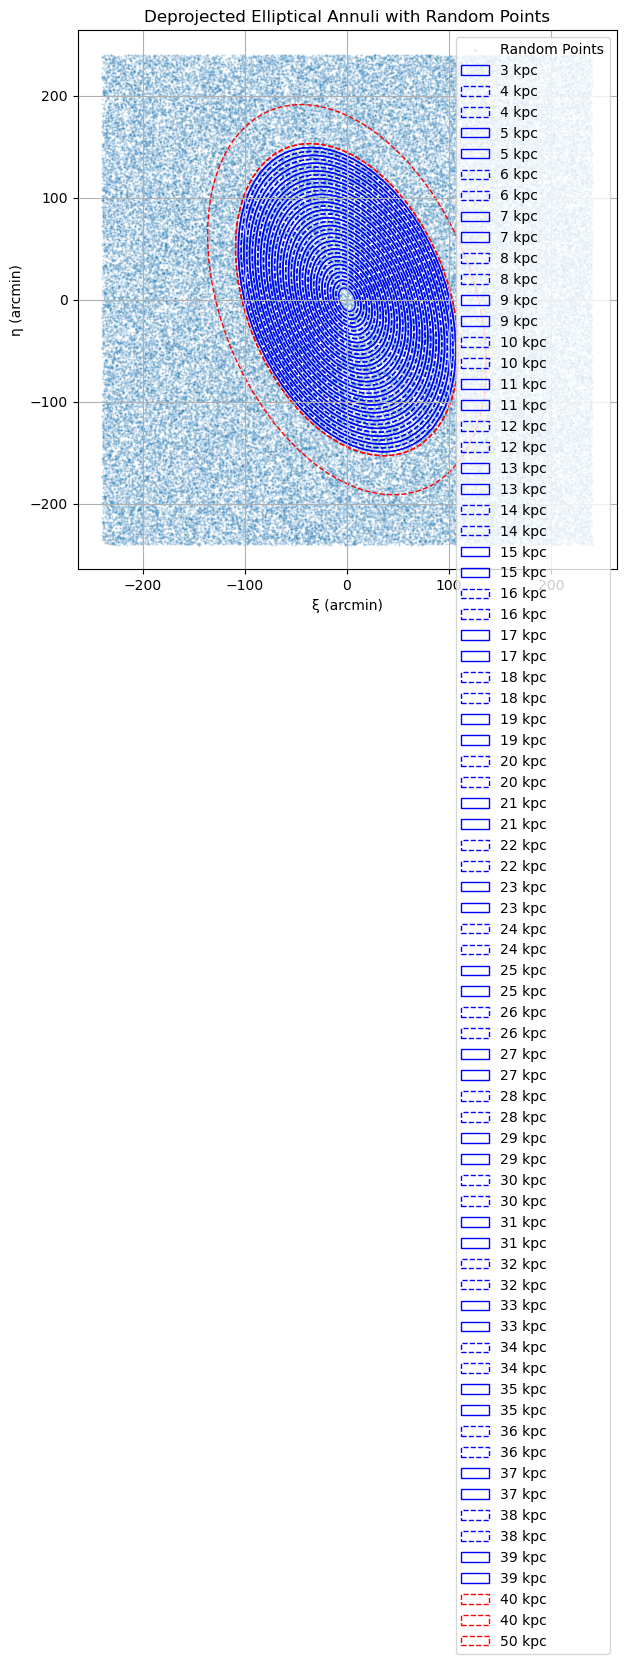


=== Area Comparison for All Bins ===
Bin (kpc)           Analytic Area          Monte Carlo Area     % Diff
---------------------------------------------------------------------------
3-4                         13.54                     12.10     -10.66
4-5                         17.41                     16.99      -2.39
5-6                         21.28                     22.61       6.26
6-7                         25.14                     23.90      -4.93
7-8                         29.01                     26.06     -10.16
8-9                         32.88                     30.24      -8.03
9-10                        36.75                     37.30       1.49
10-11                       40.62                     37.30      -8.18
11-12                       44.49                     48.38       8.76
12-13                       48.35                     51.12       5.72
13-14                       52.22                     49.82      -4.59
14-15                       56.09 

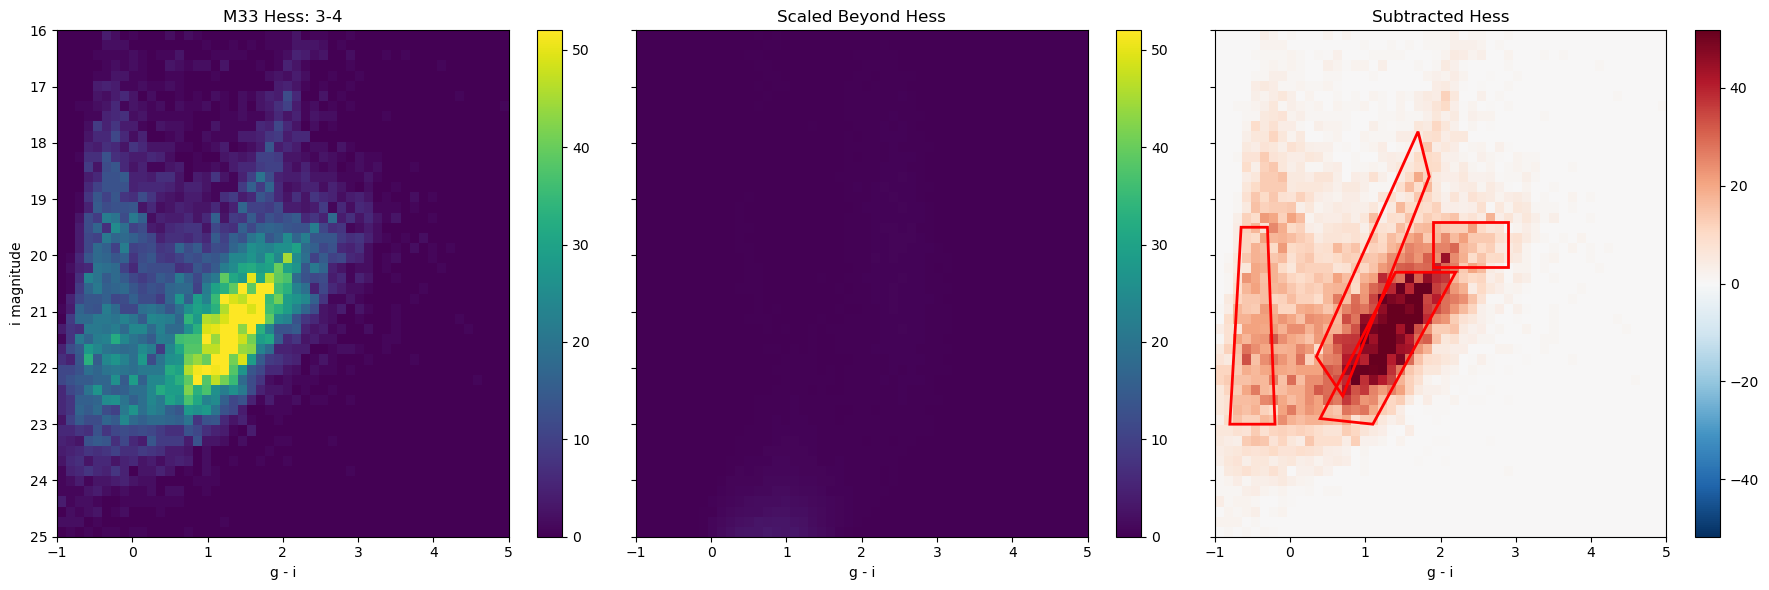

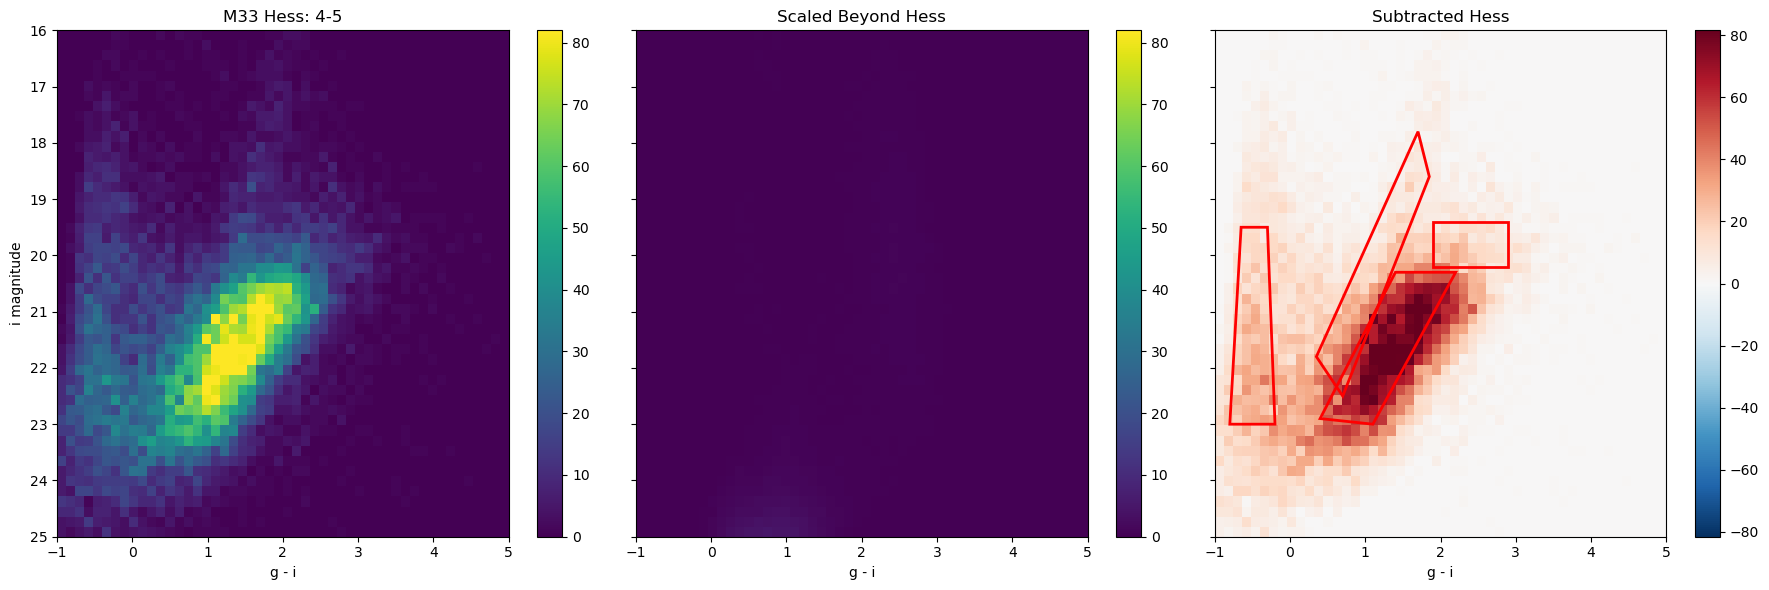

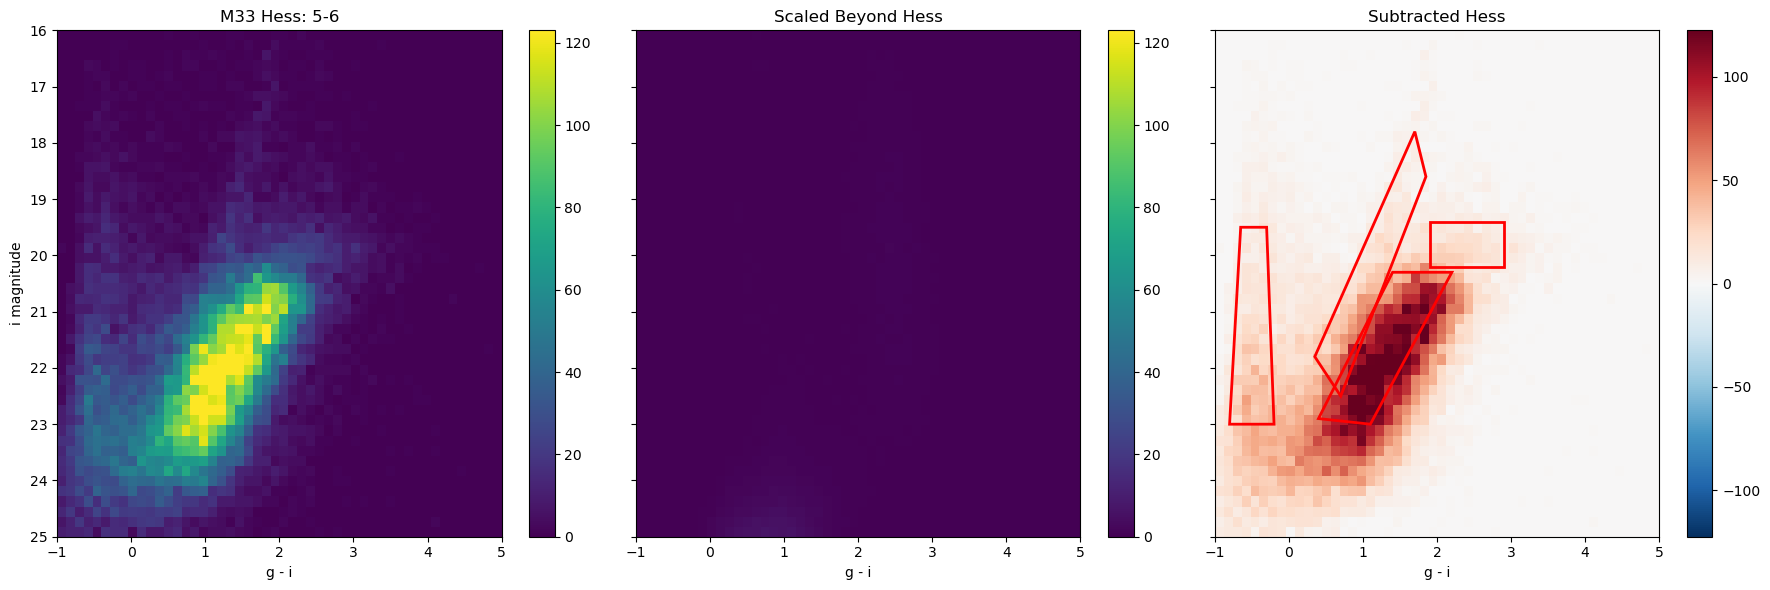

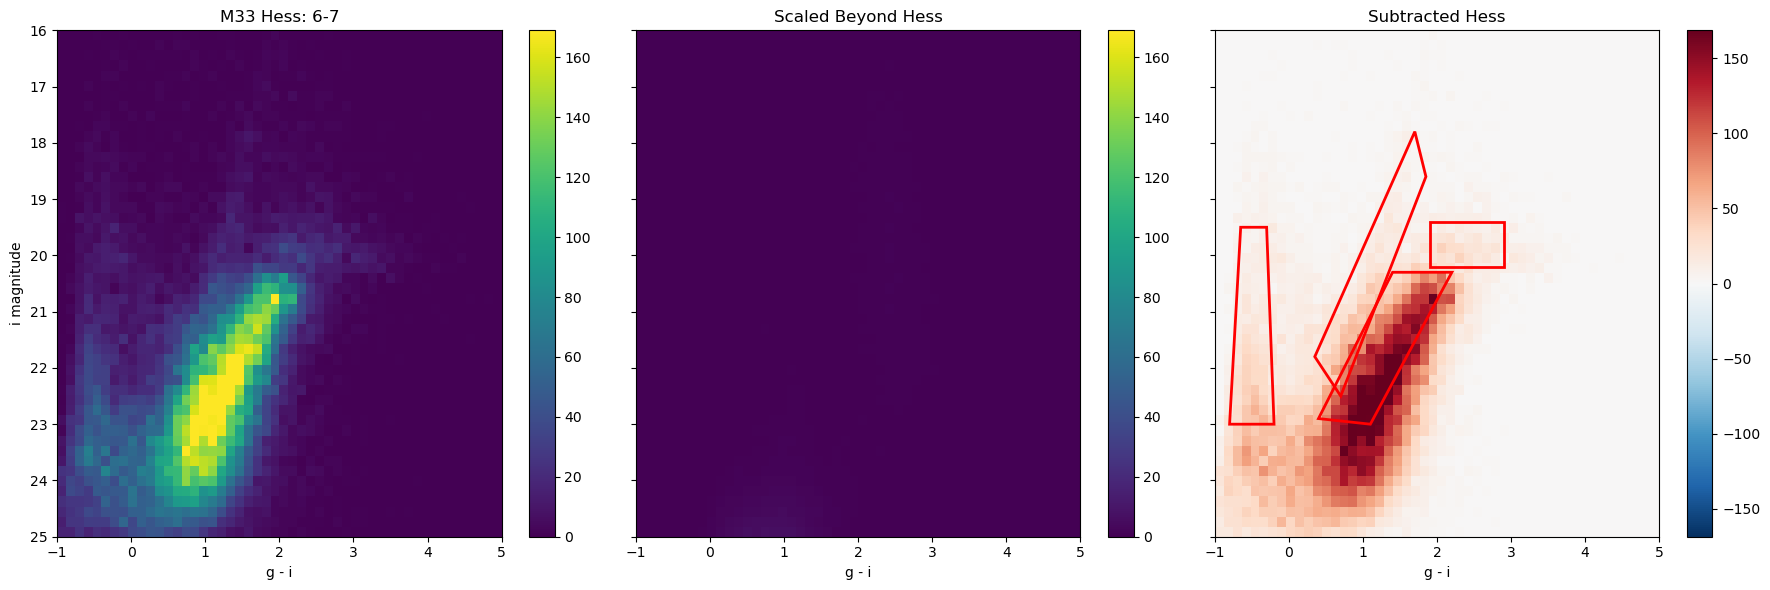

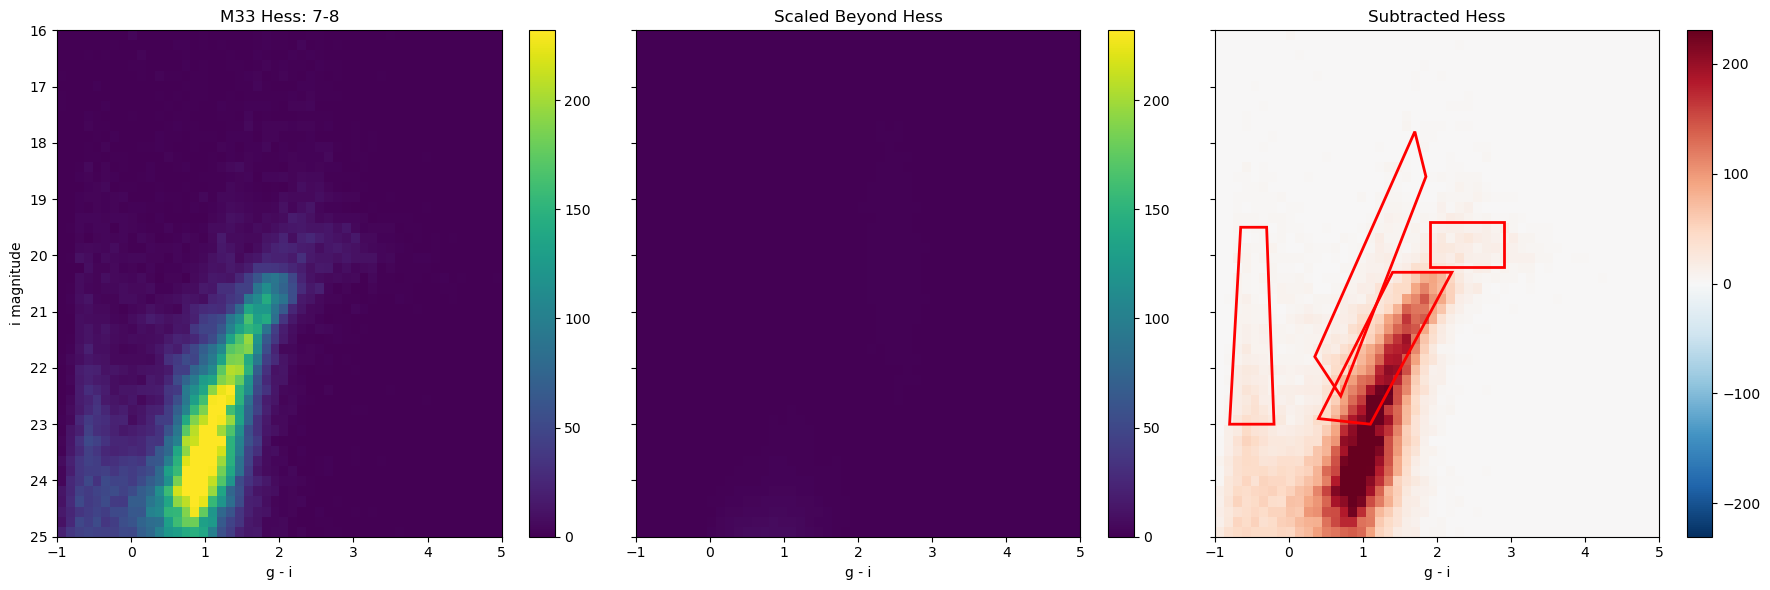

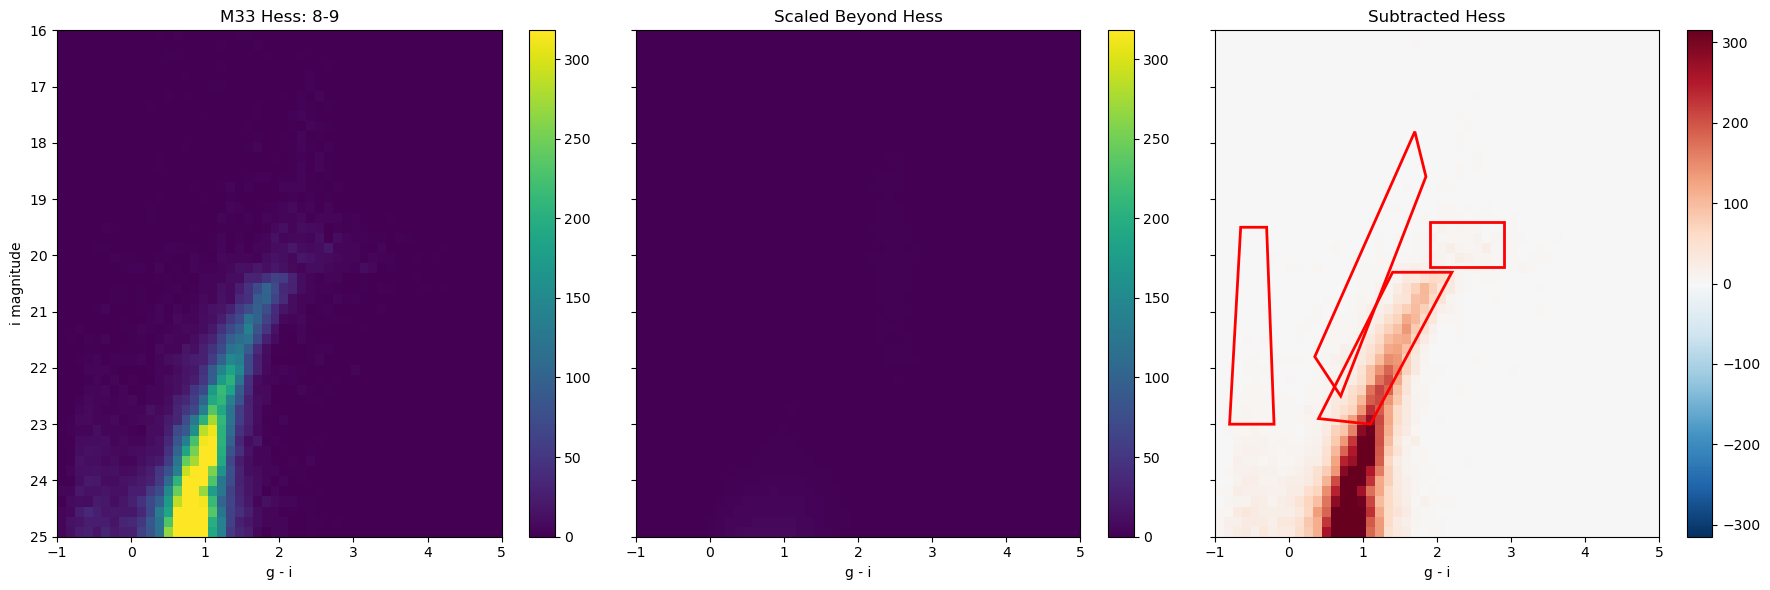

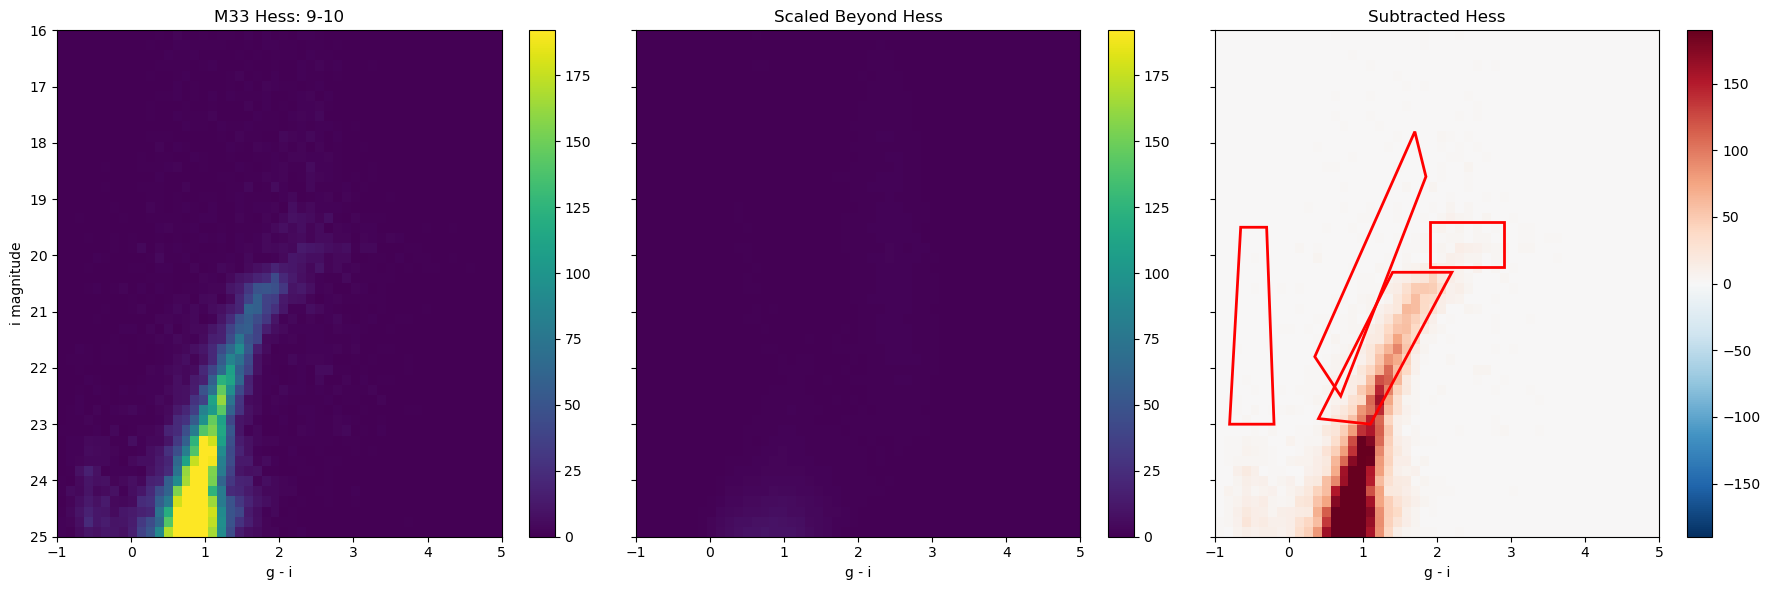

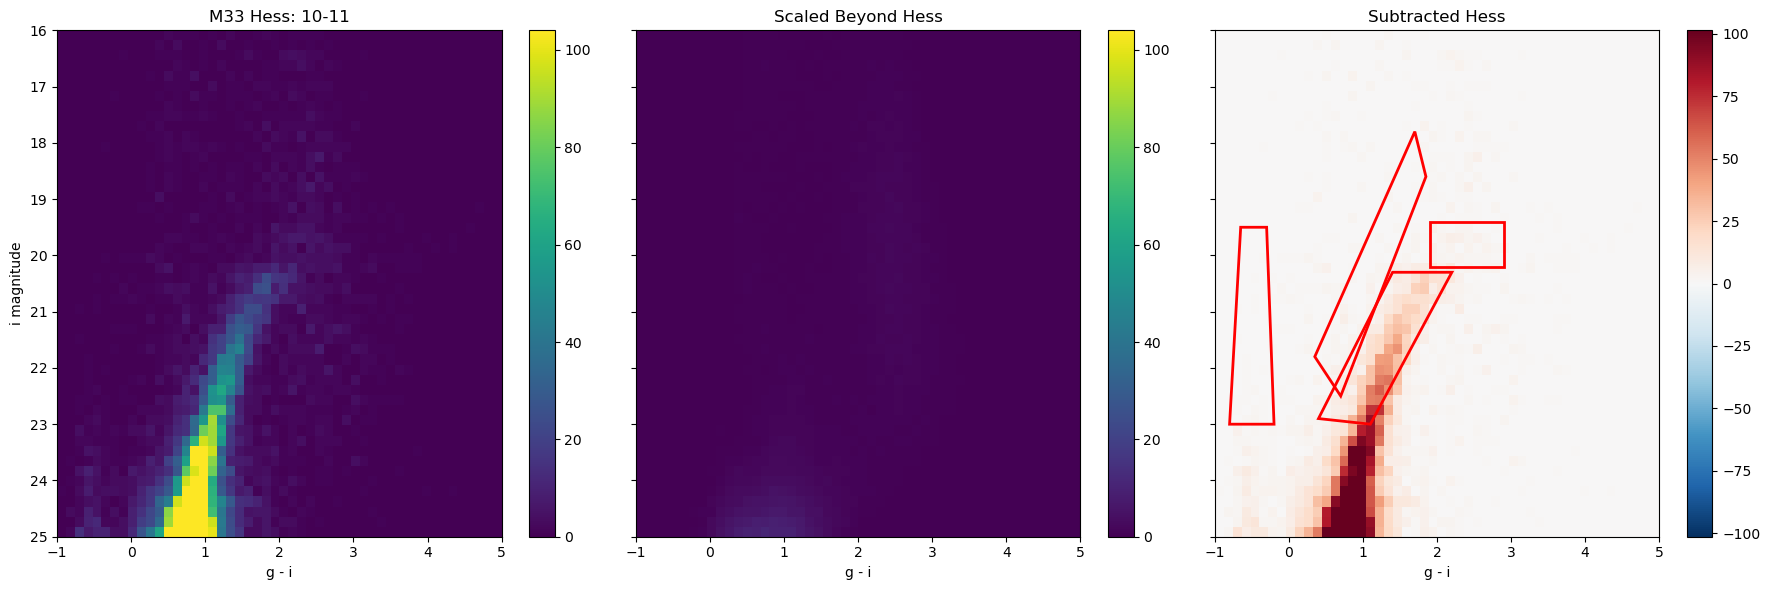

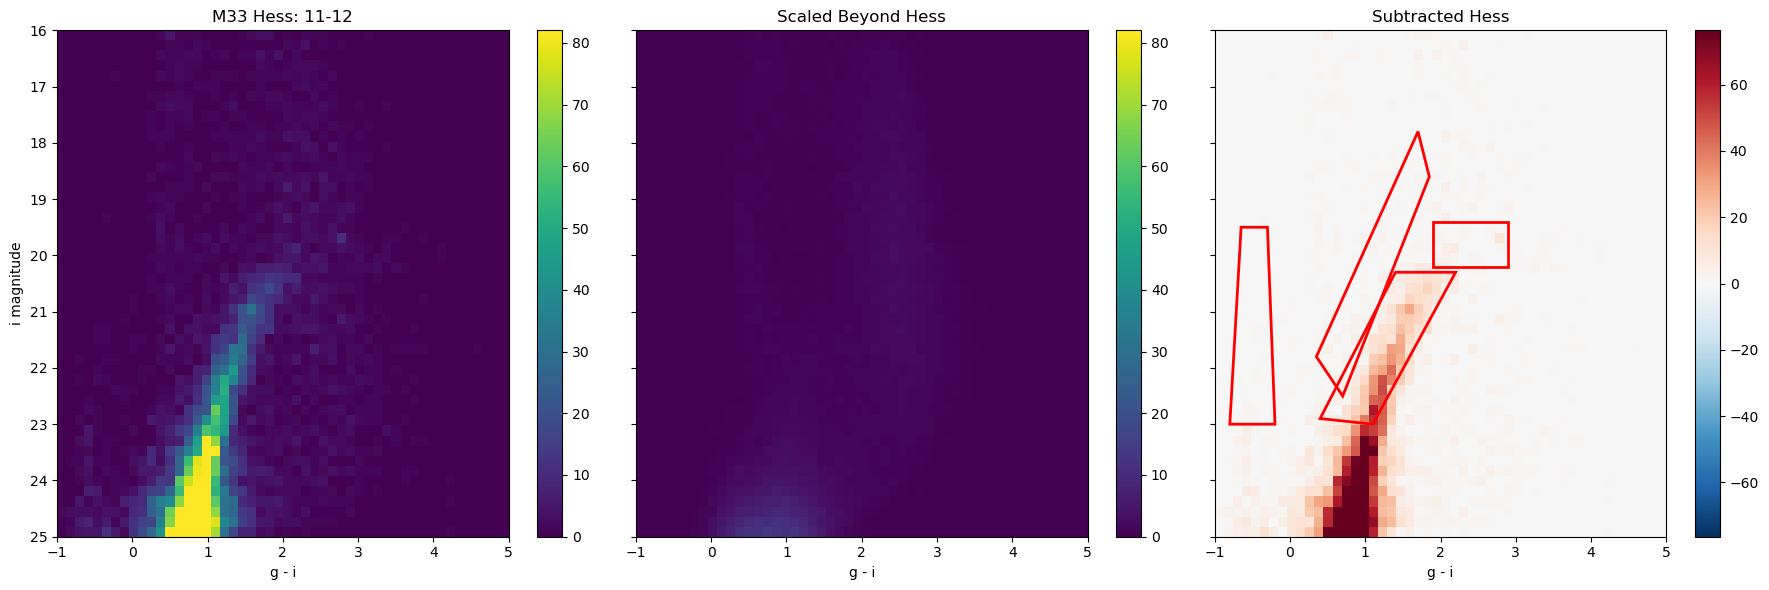

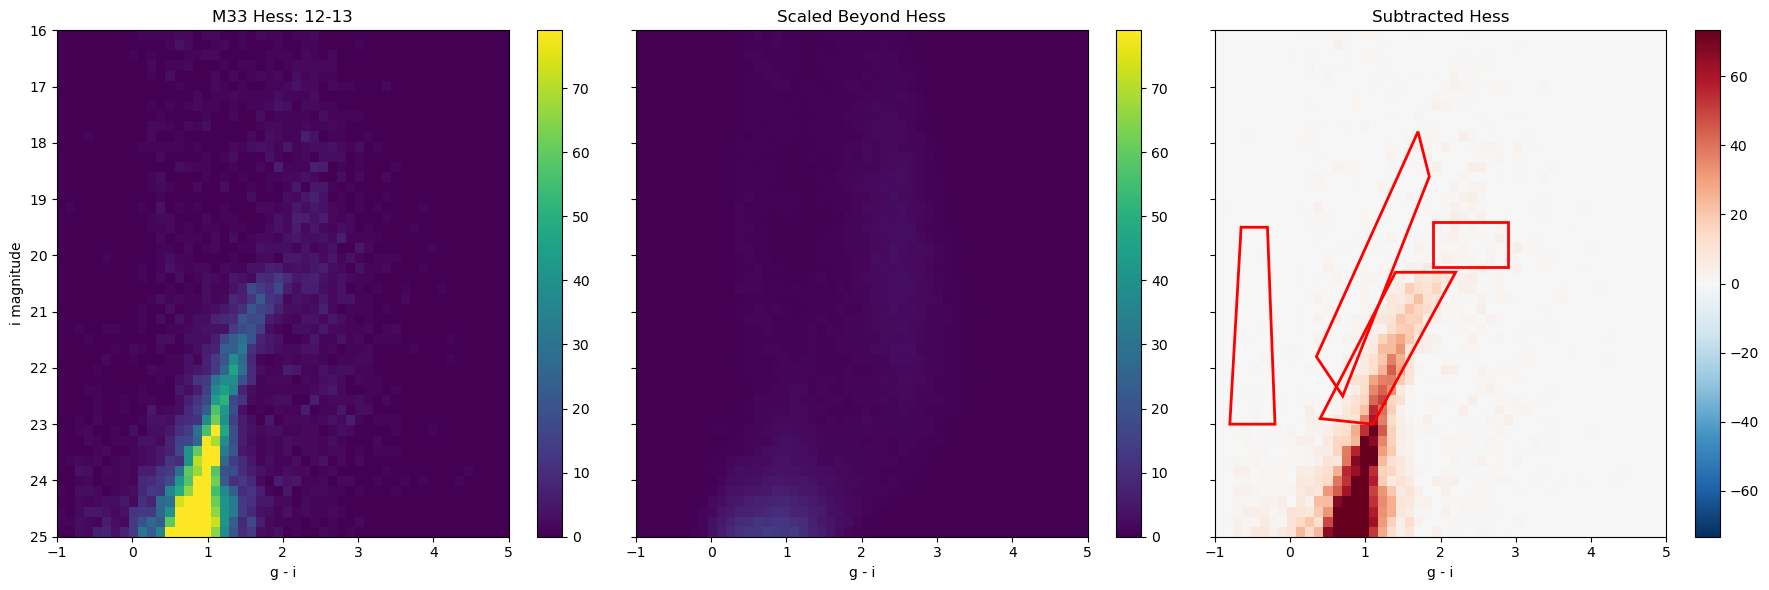

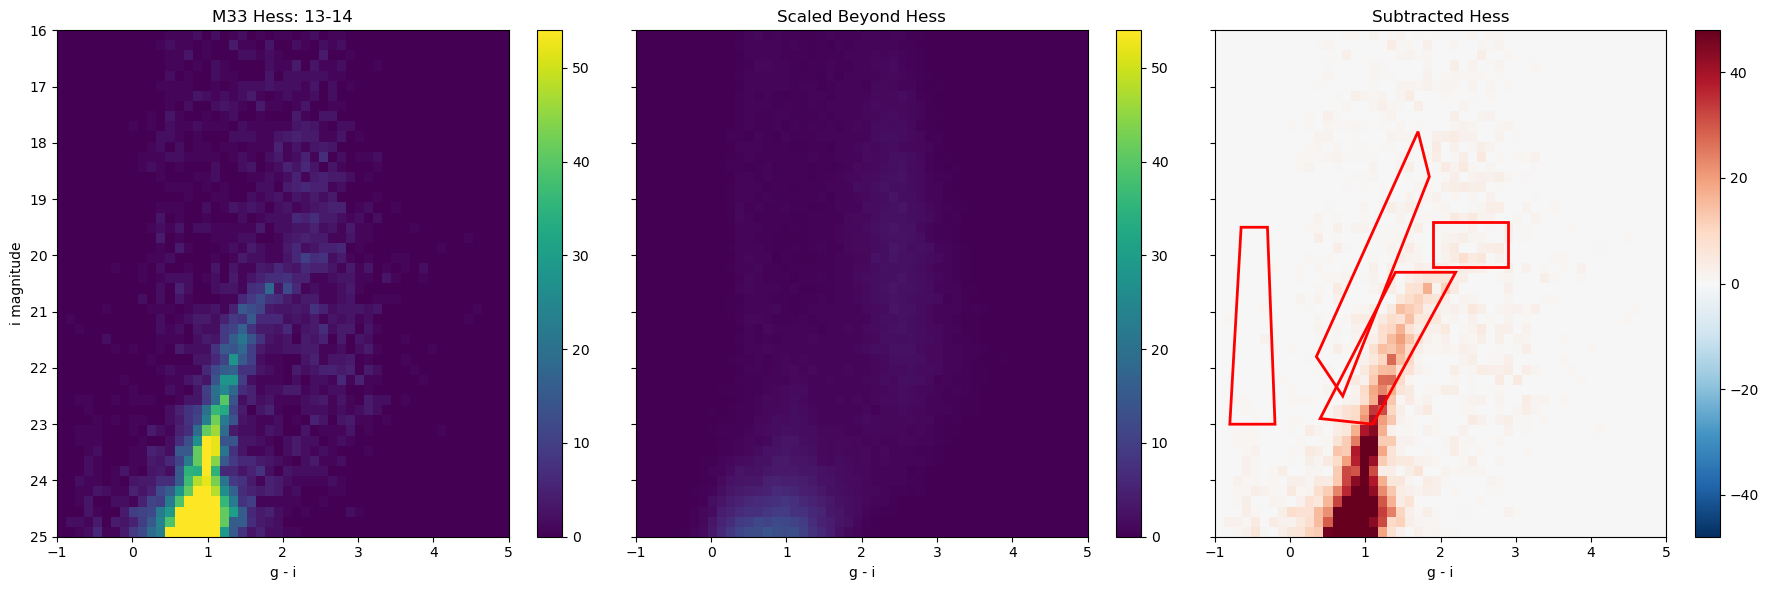

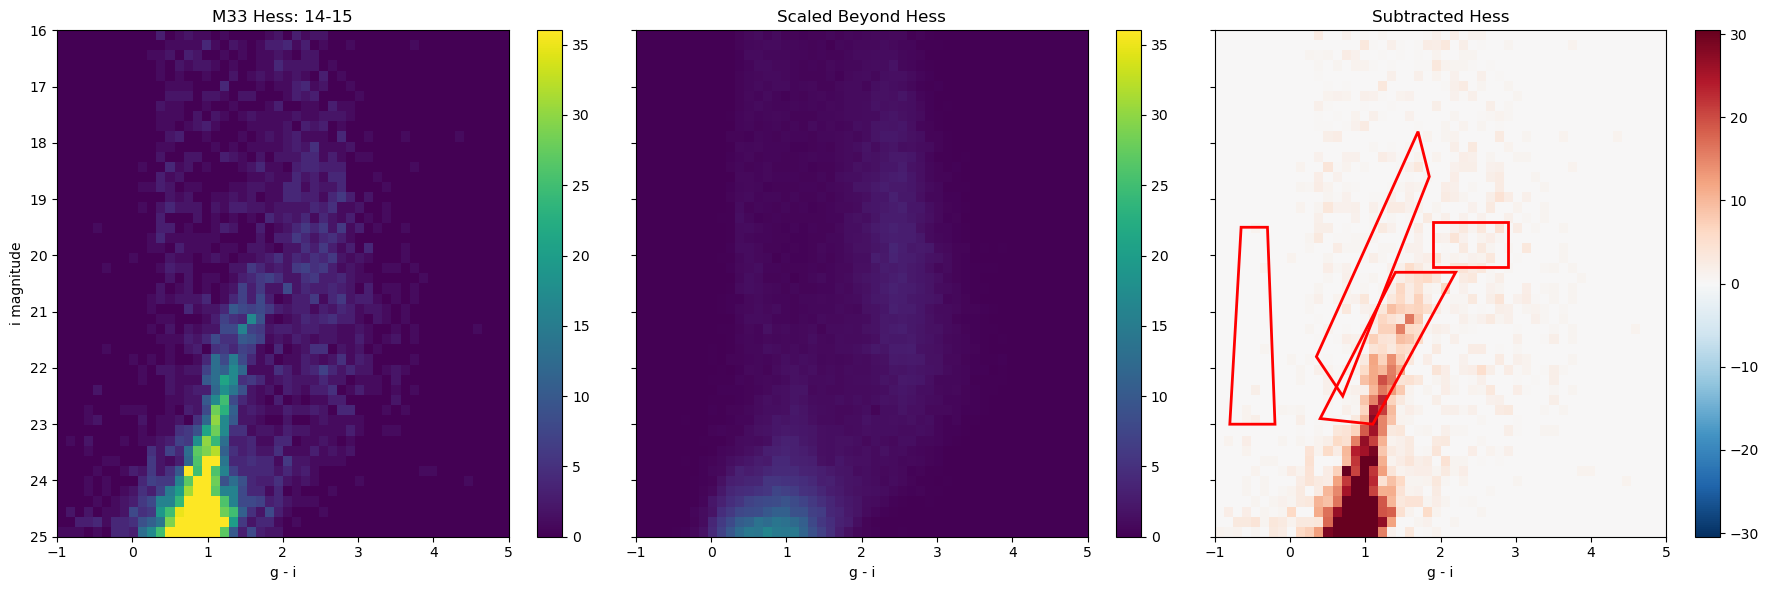

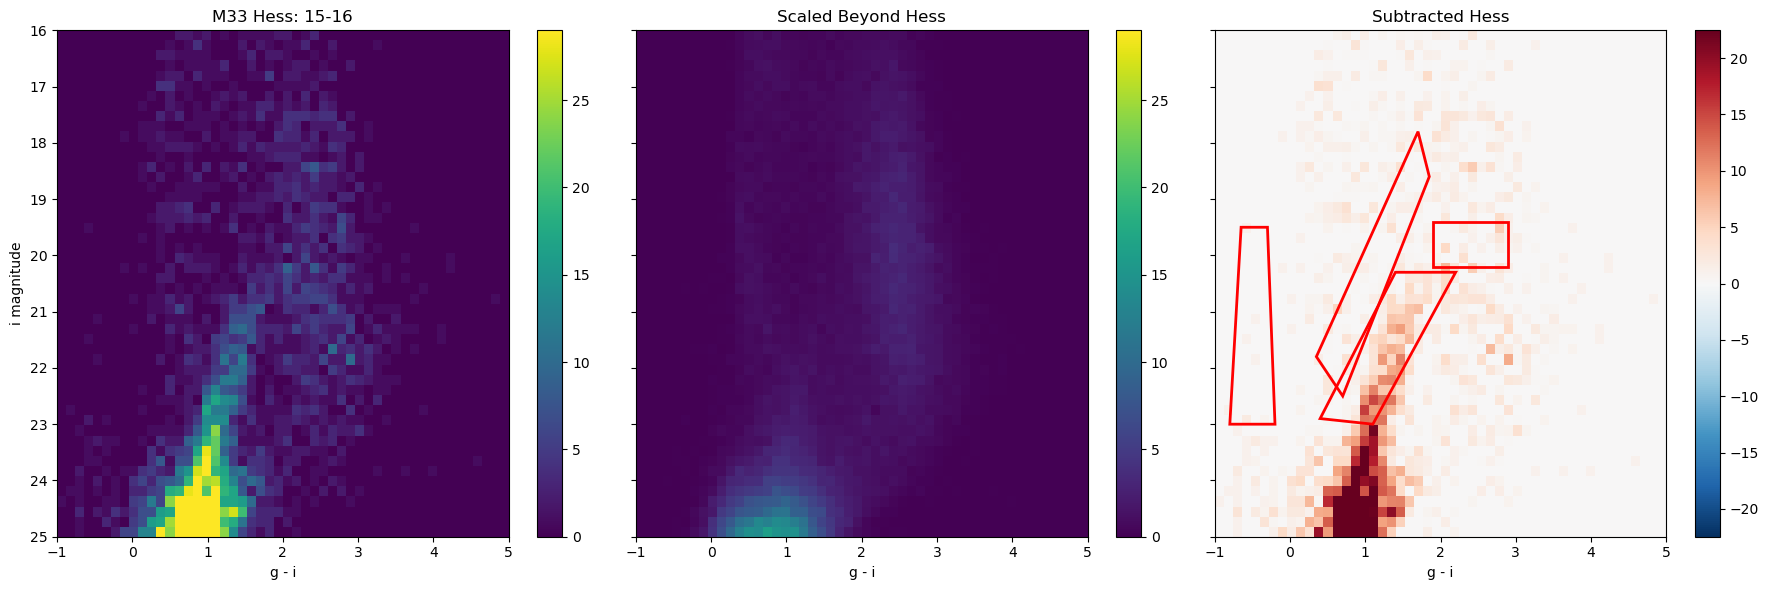

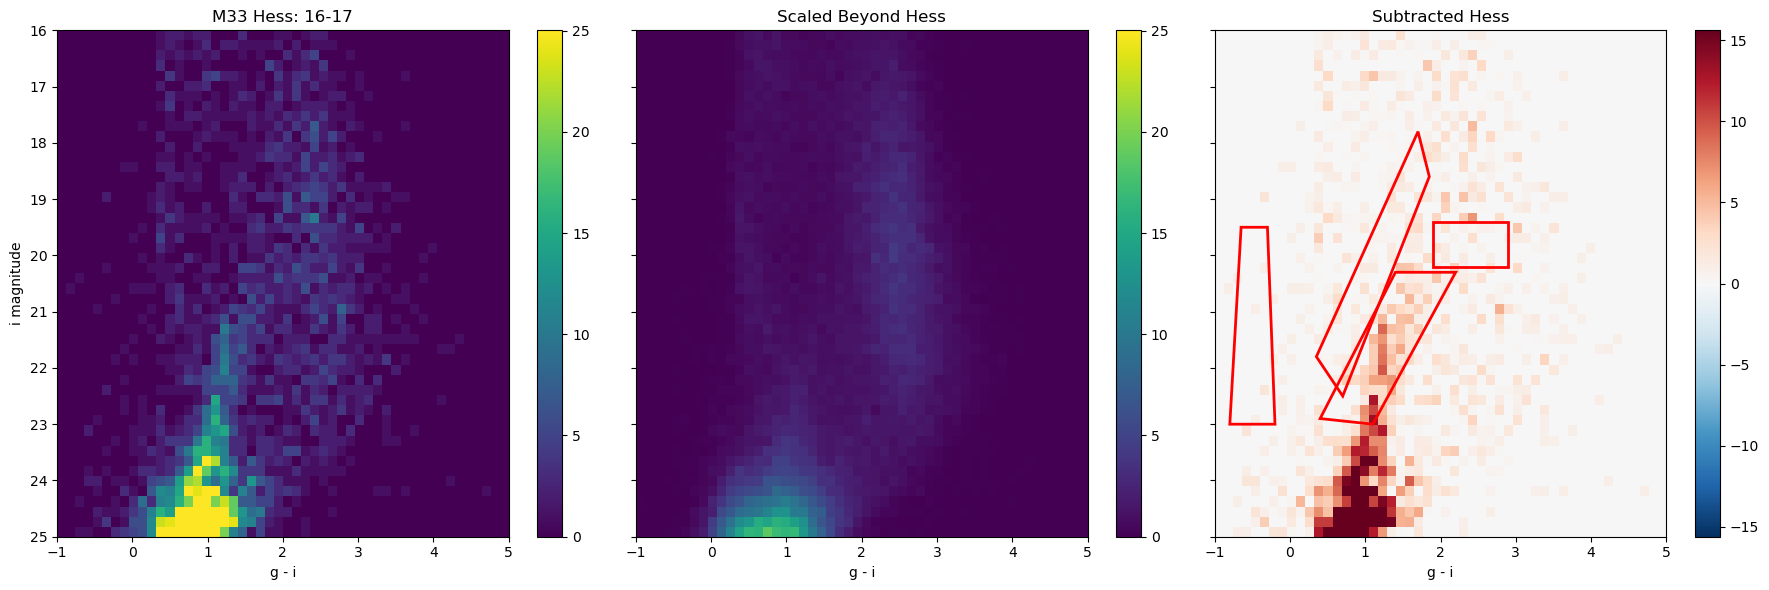

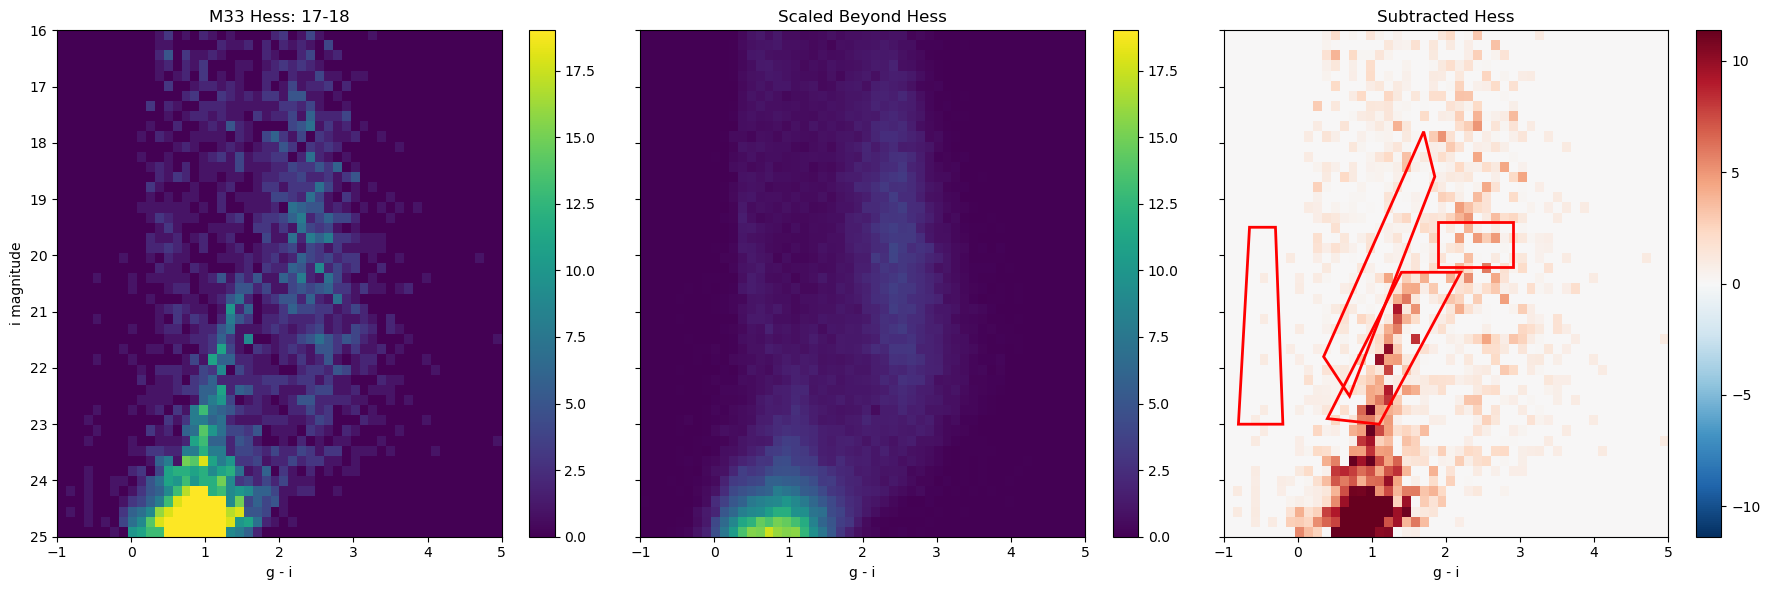

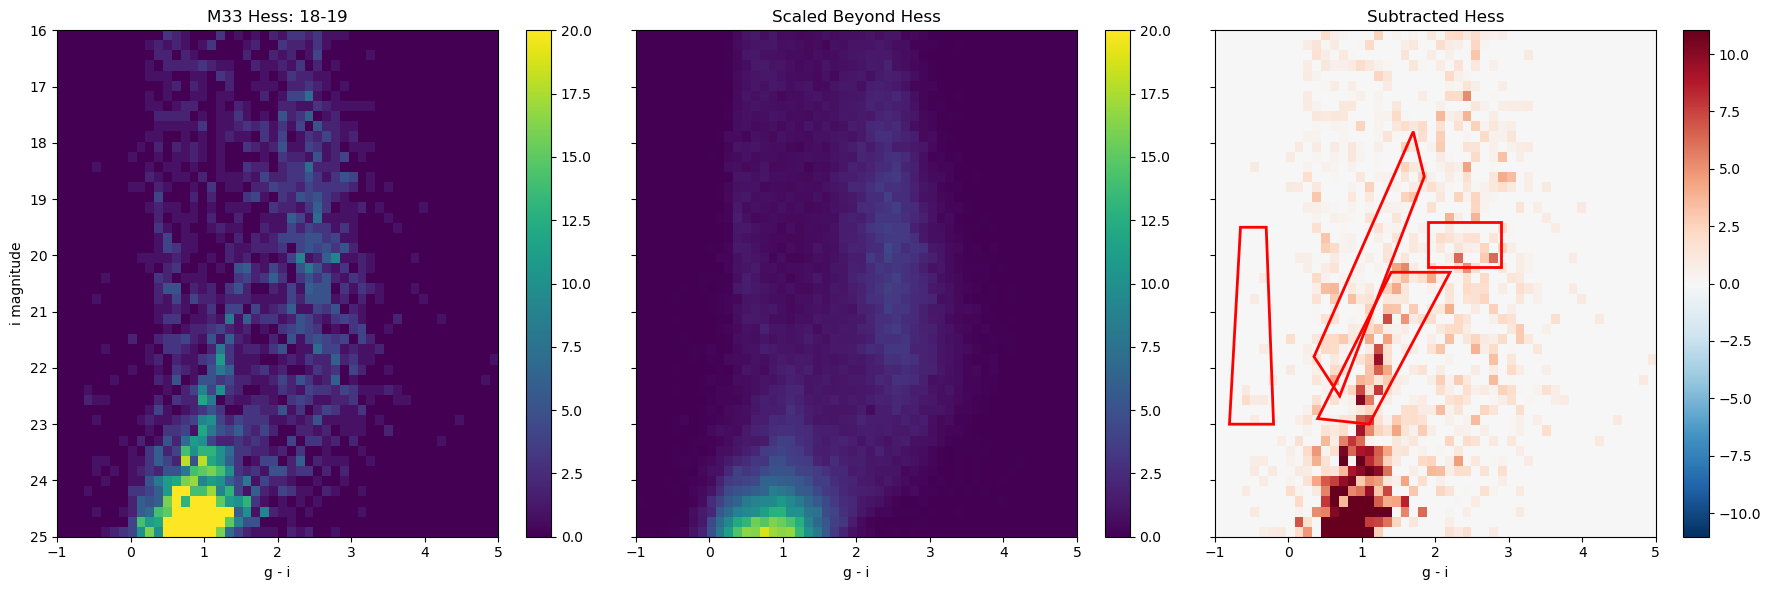

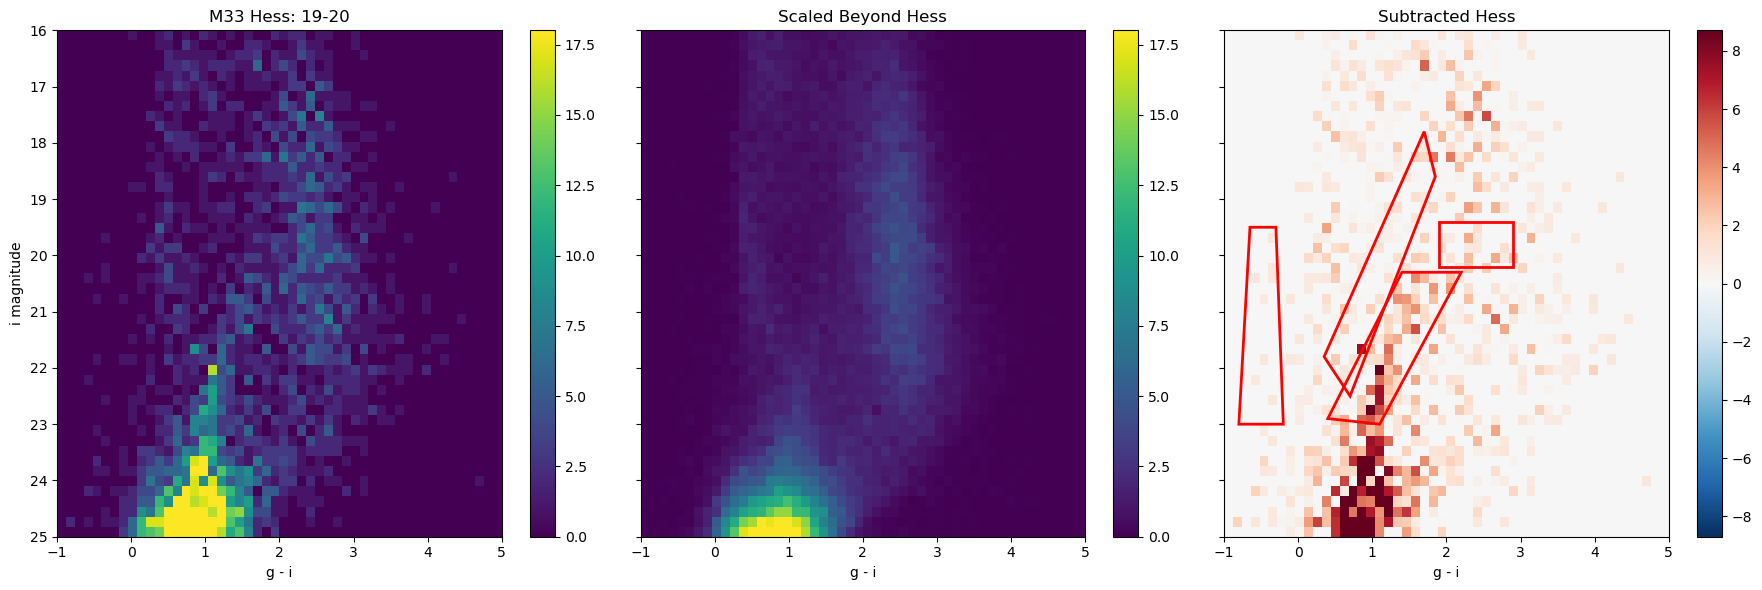

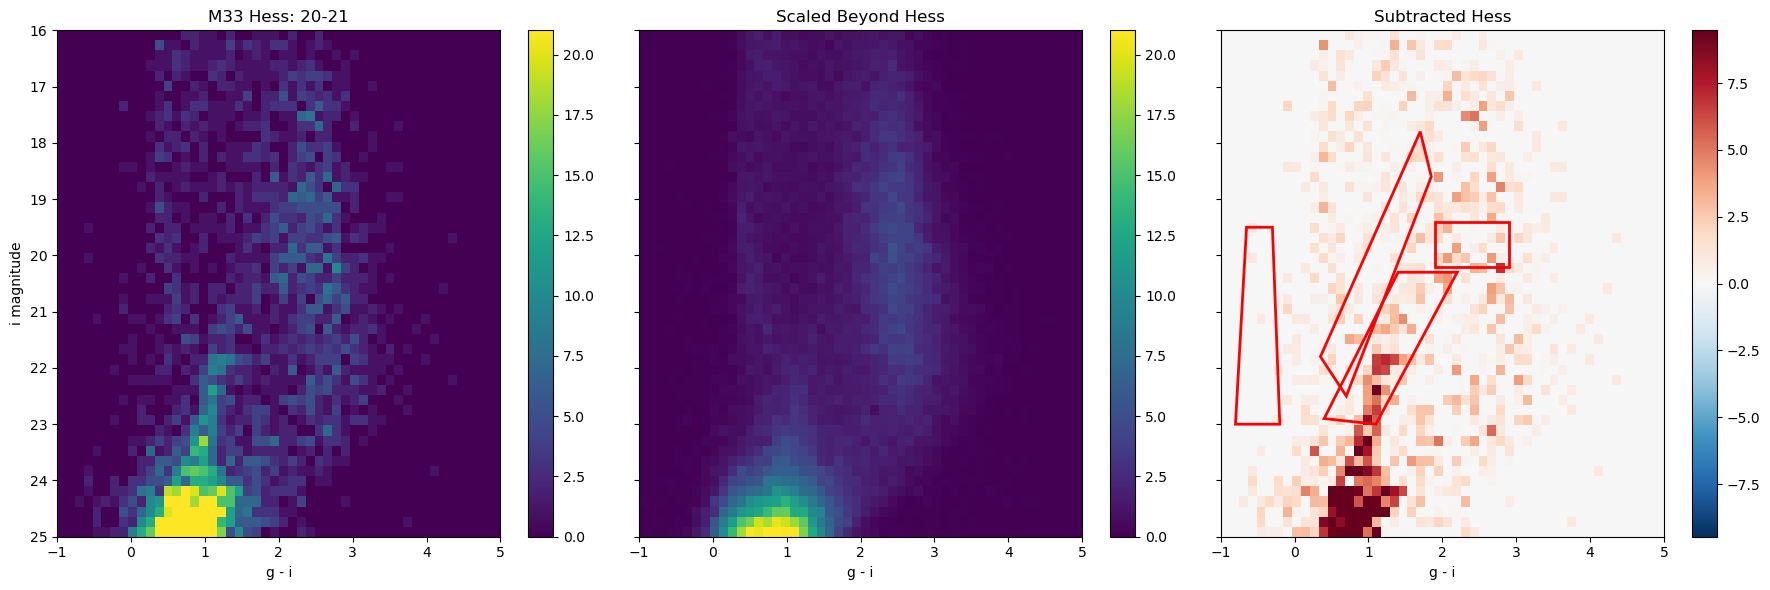

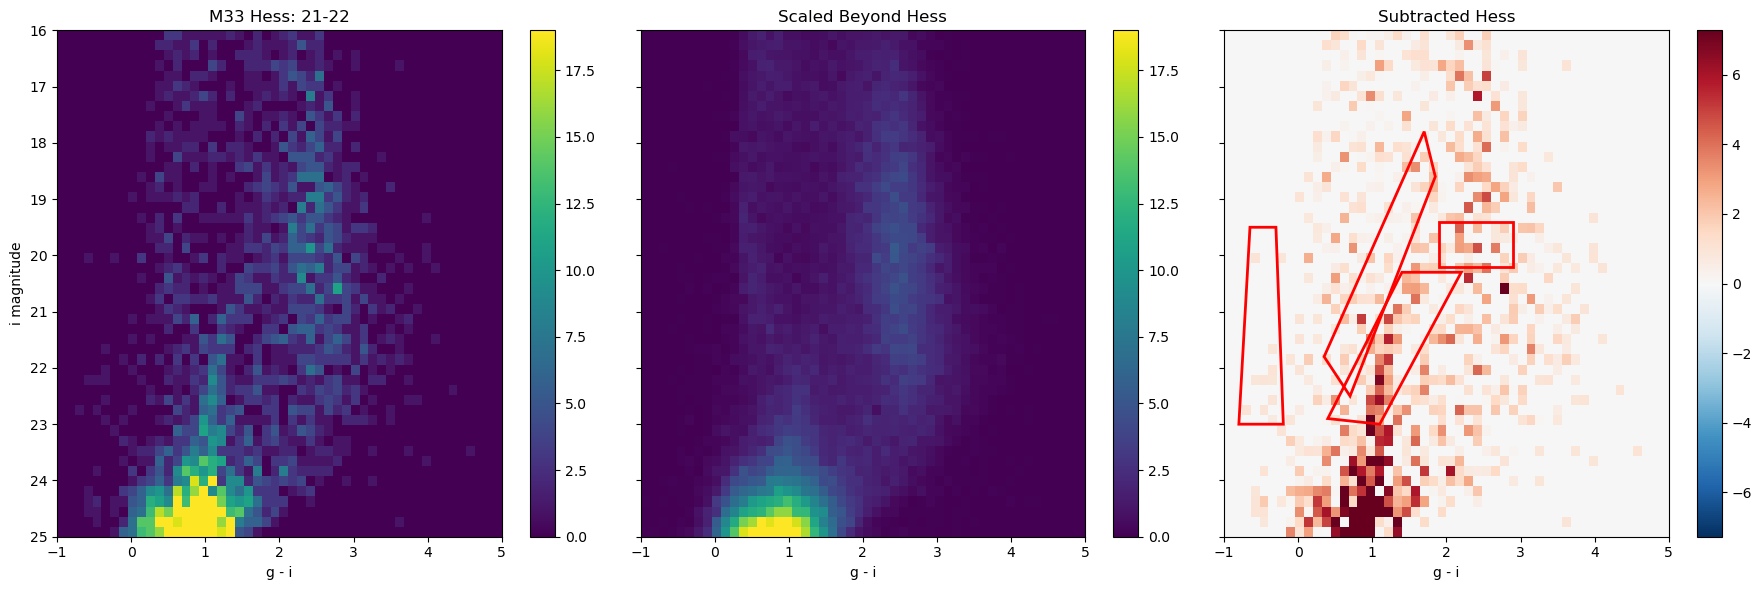

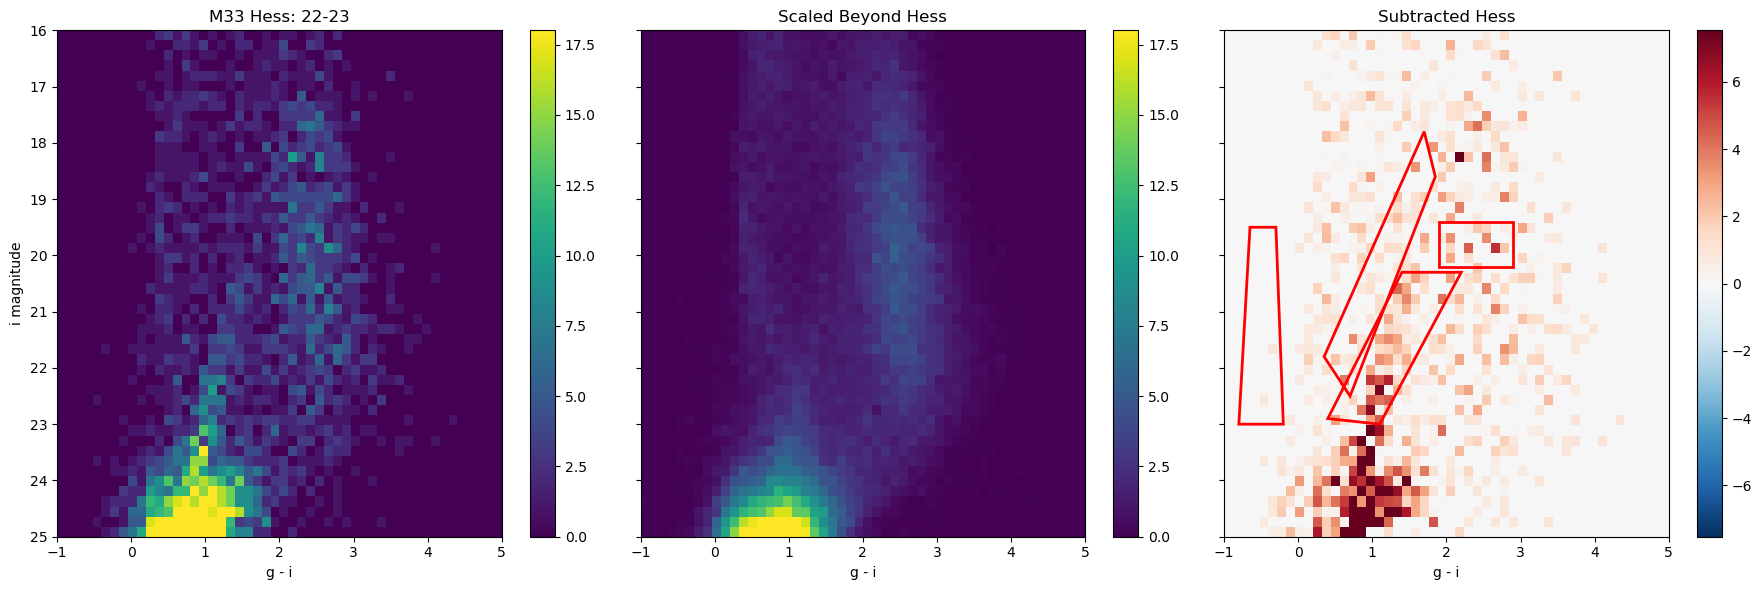

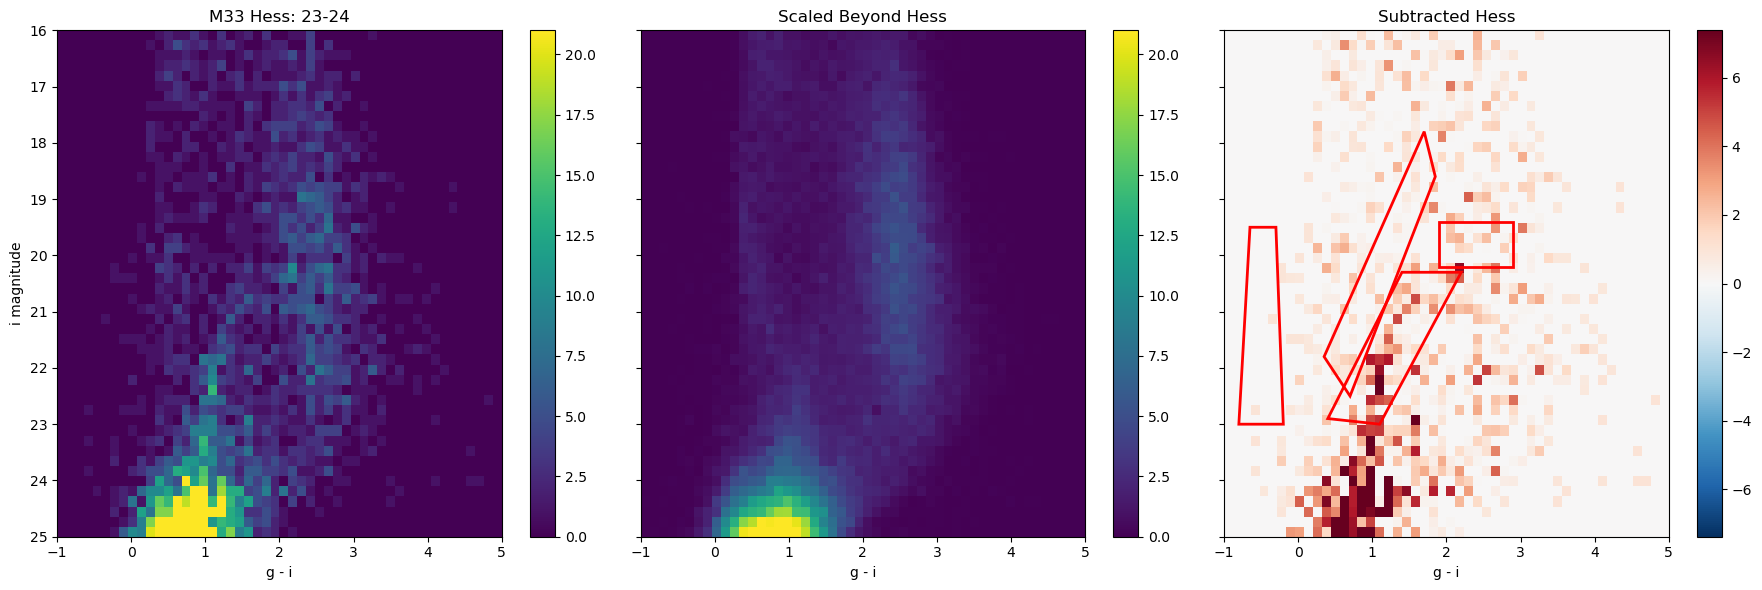

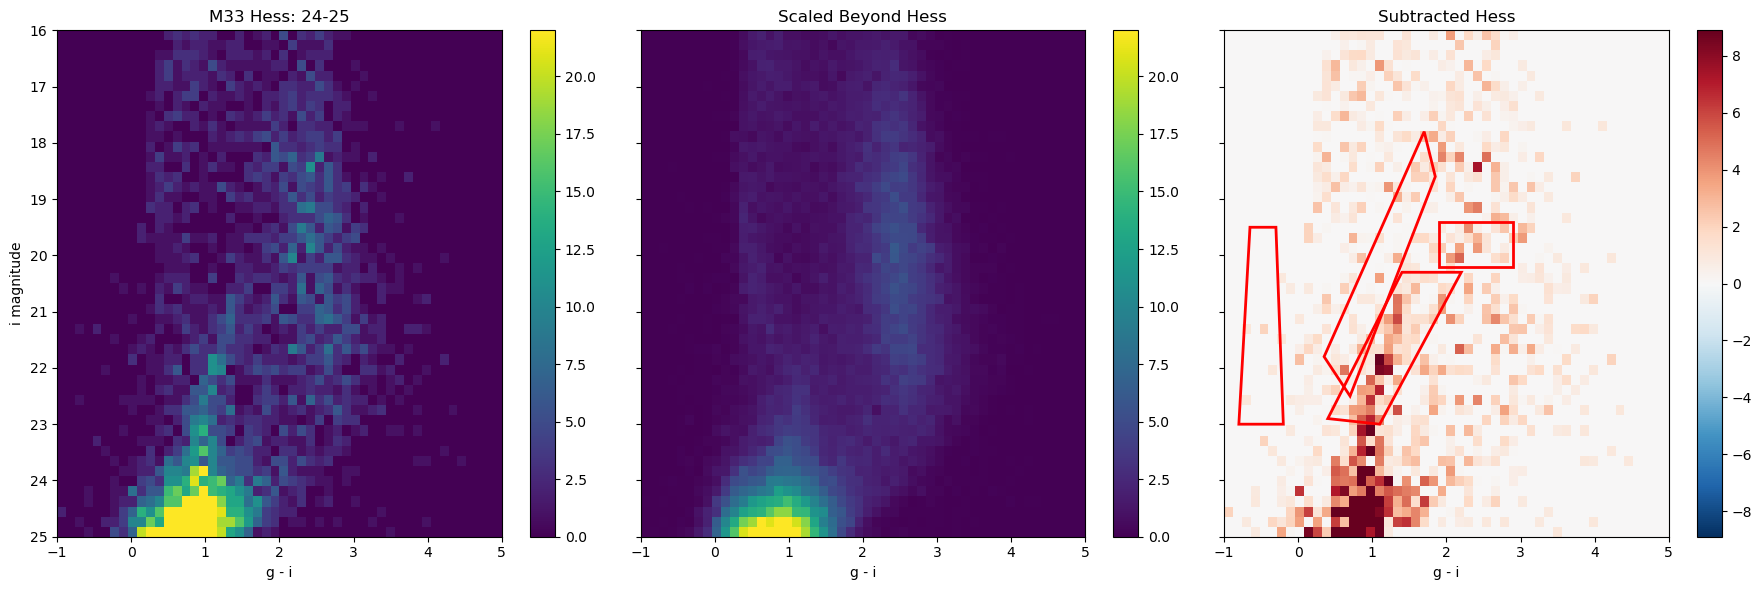

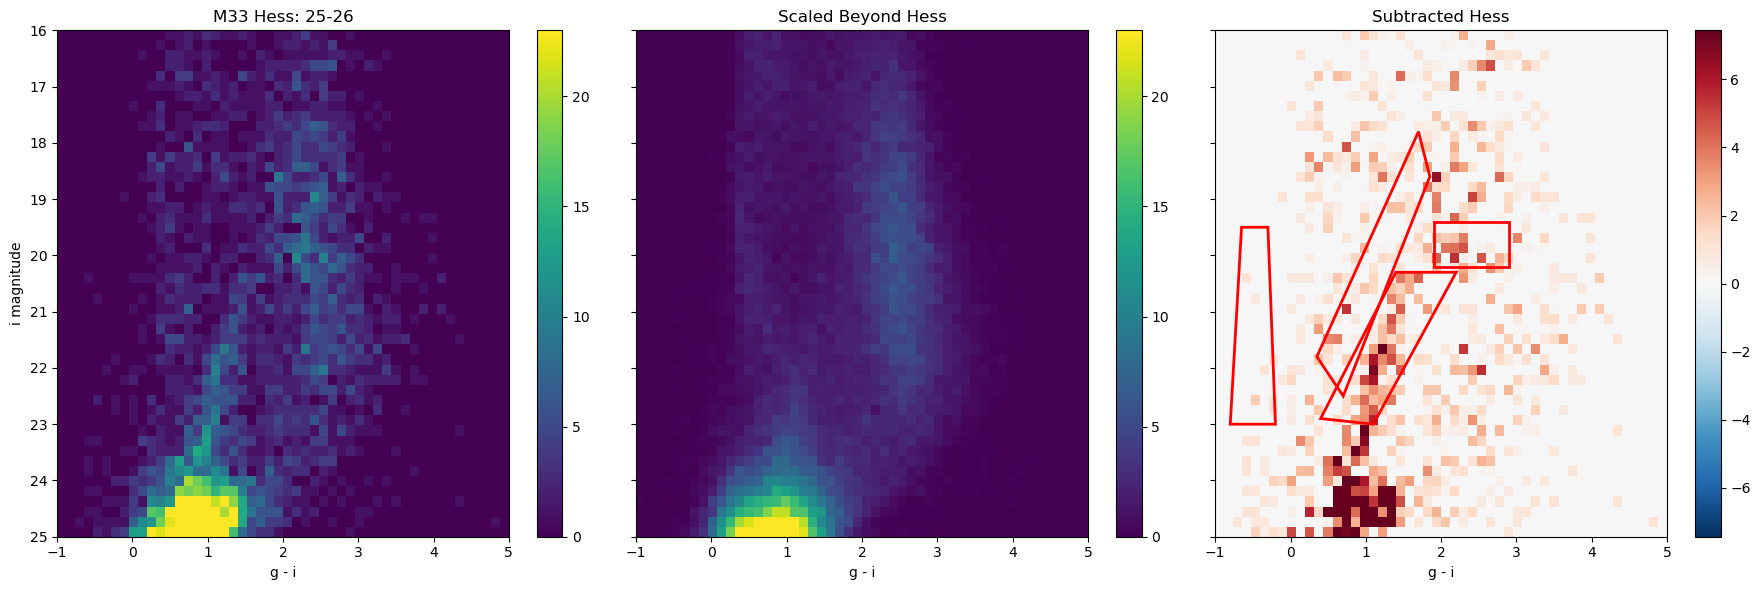

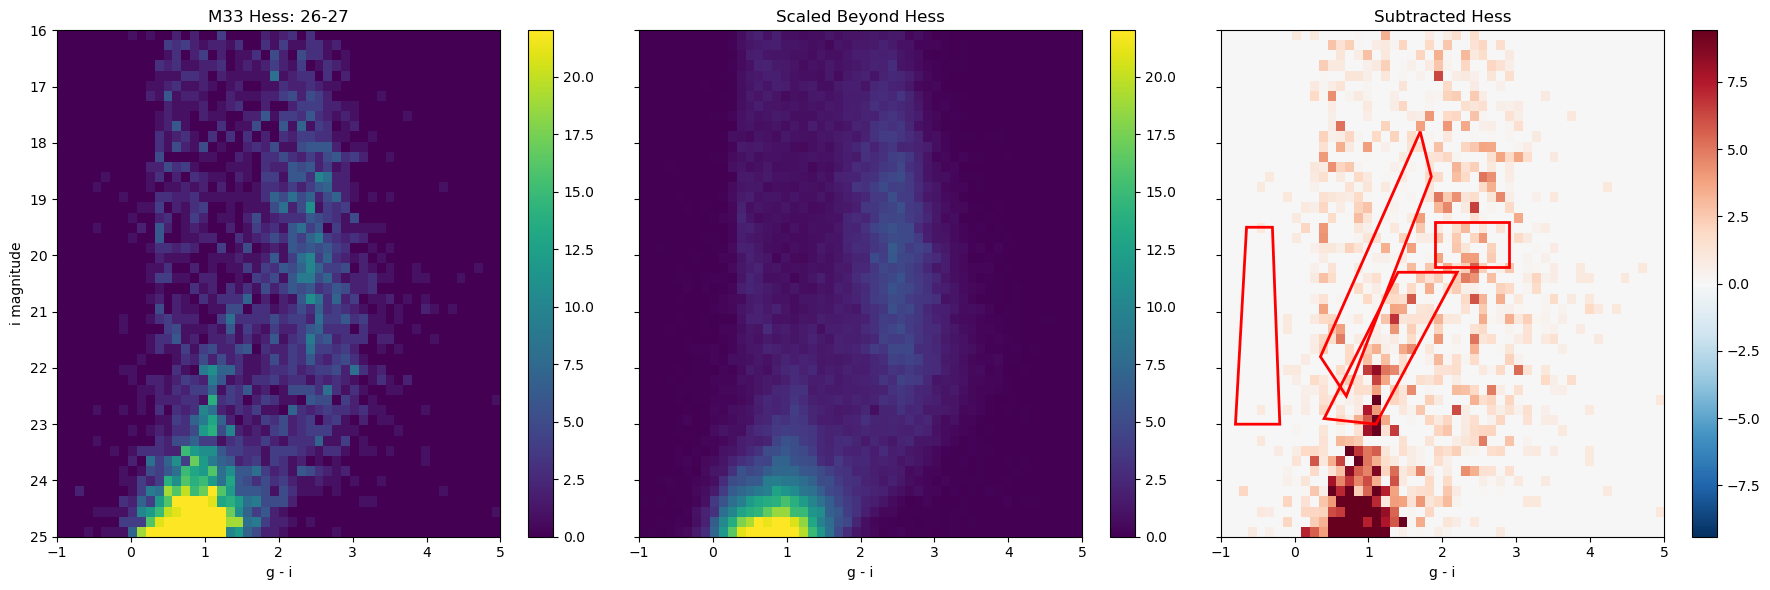

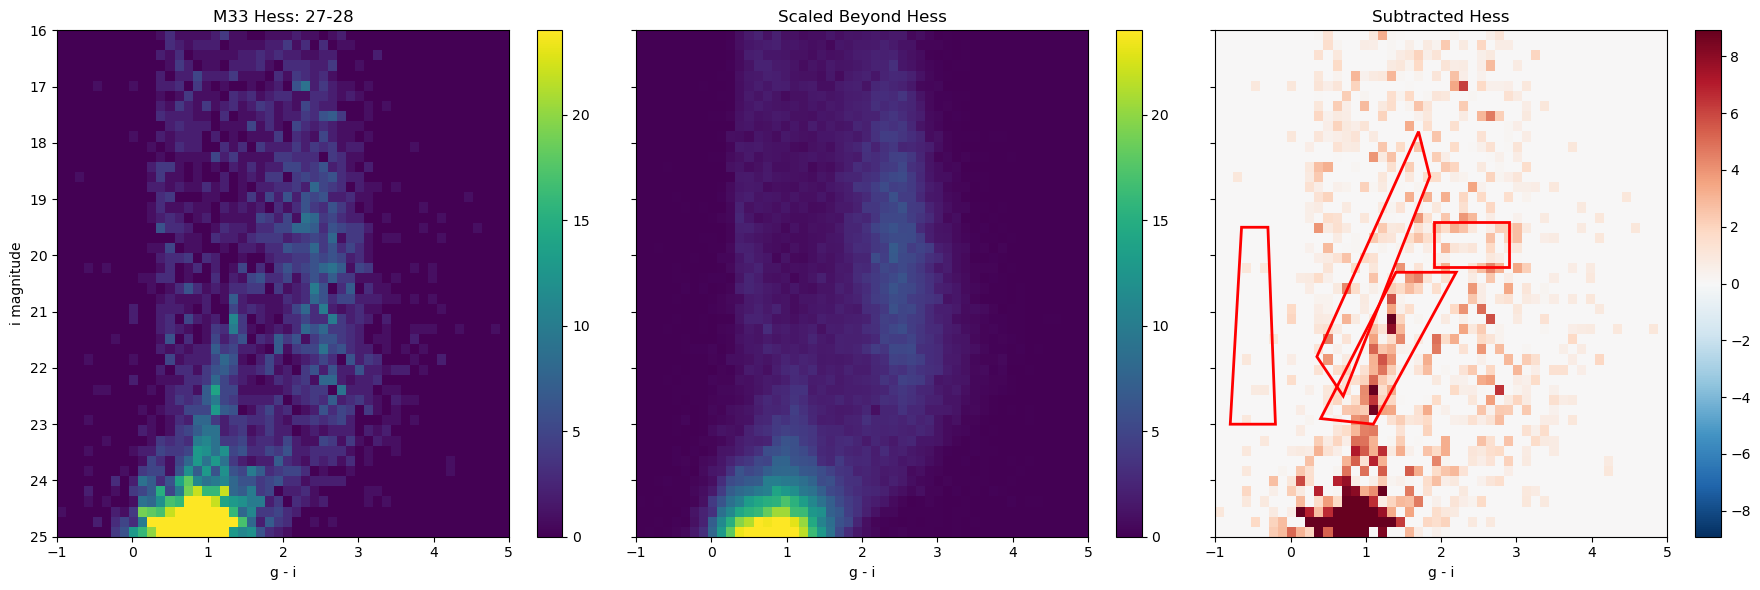

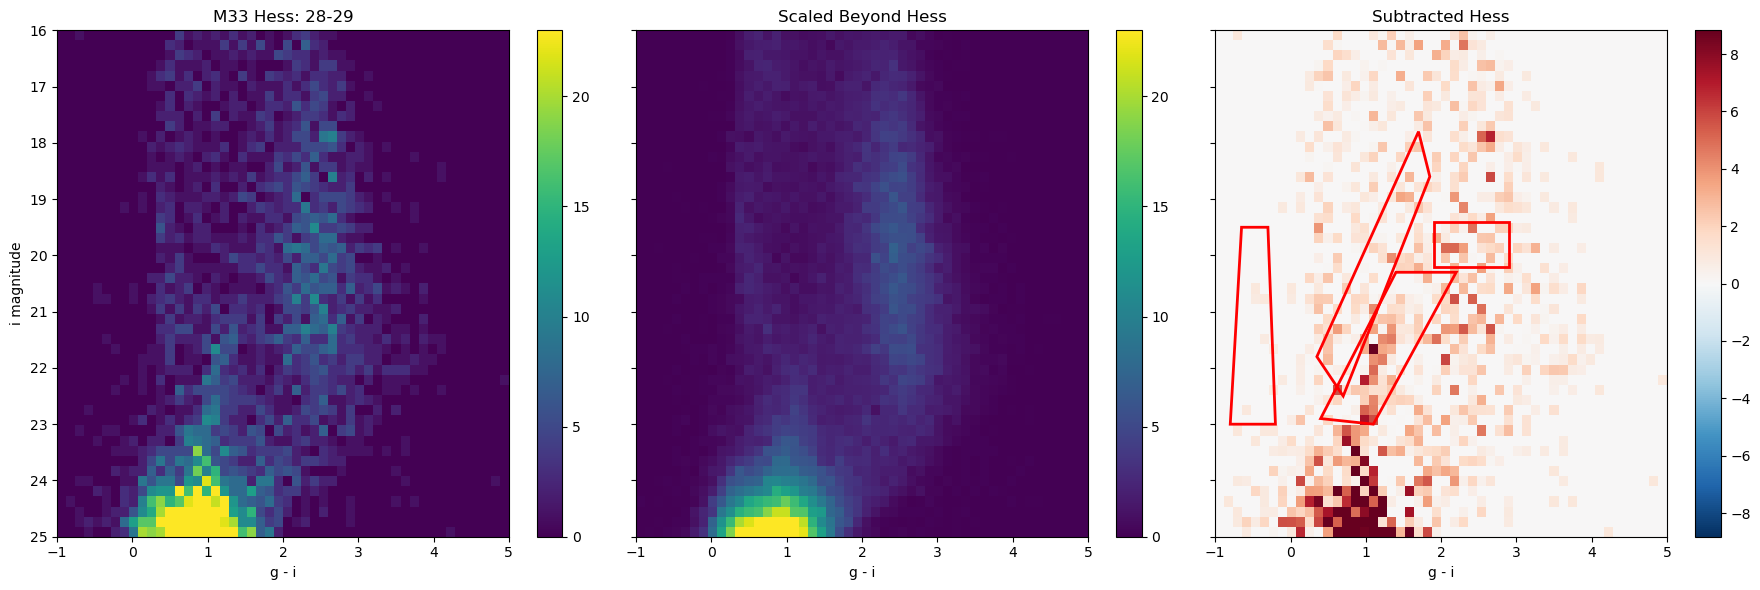

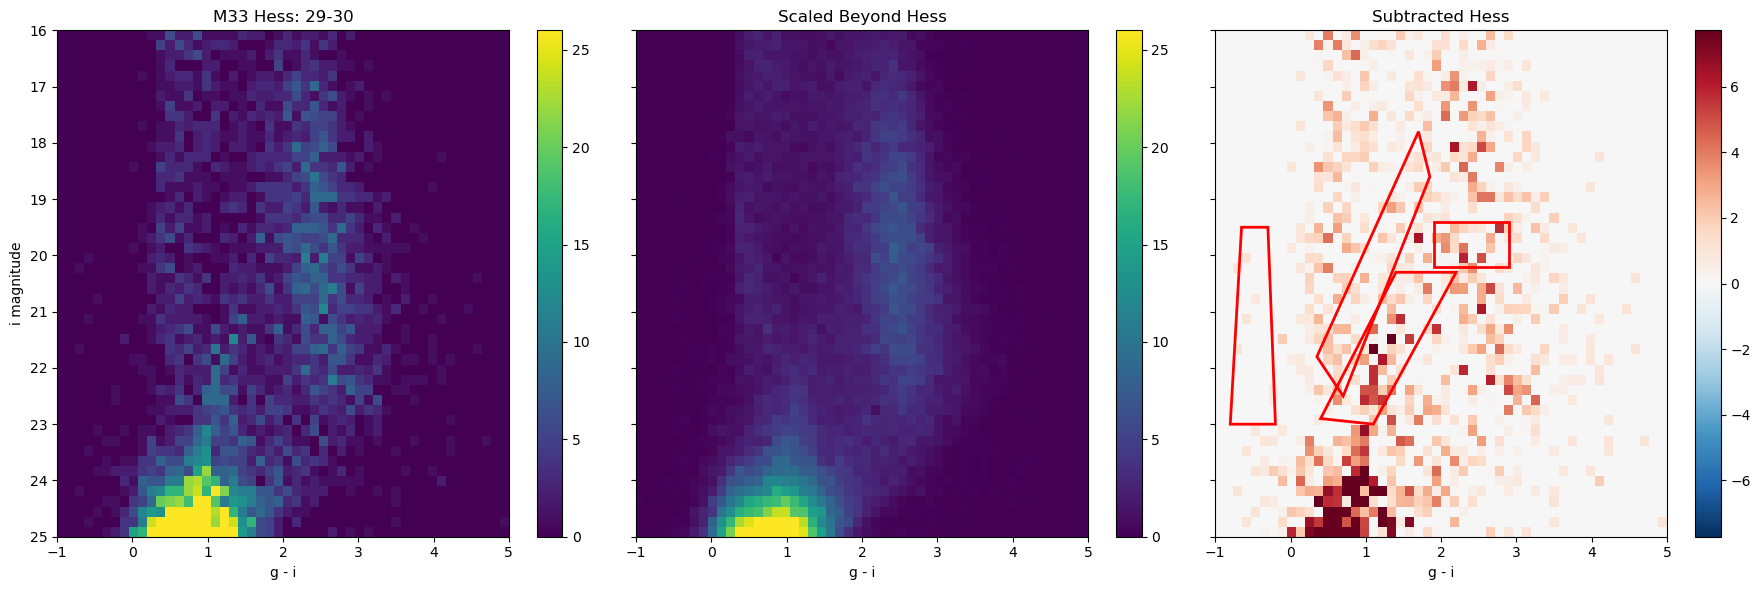

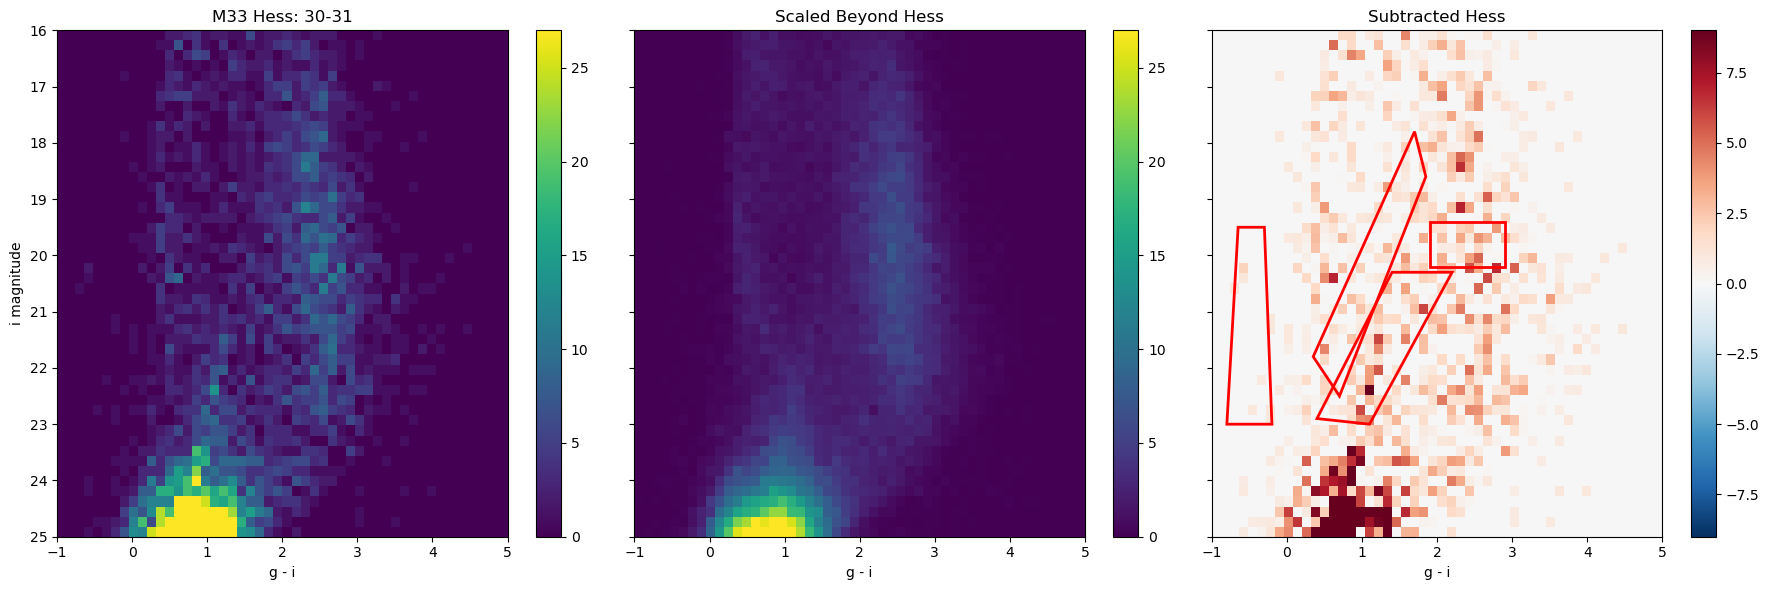

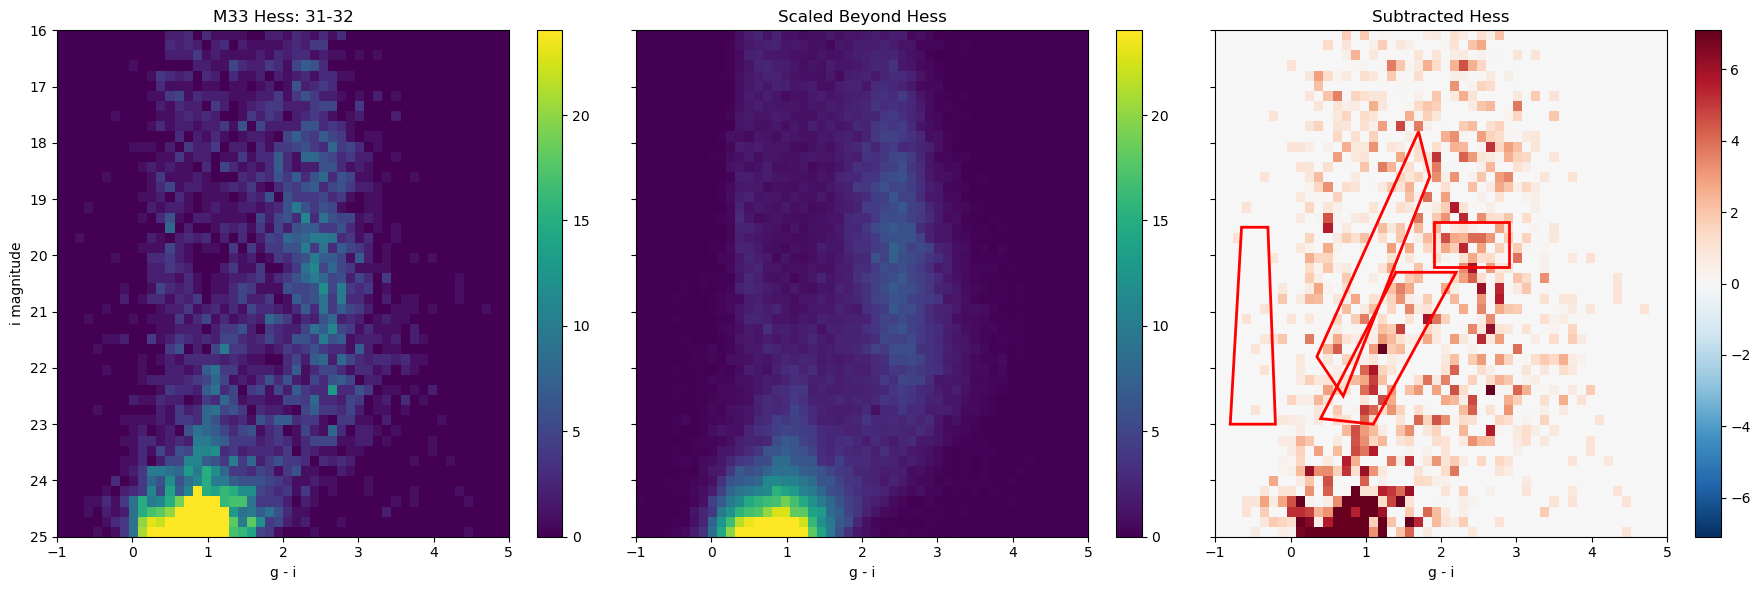

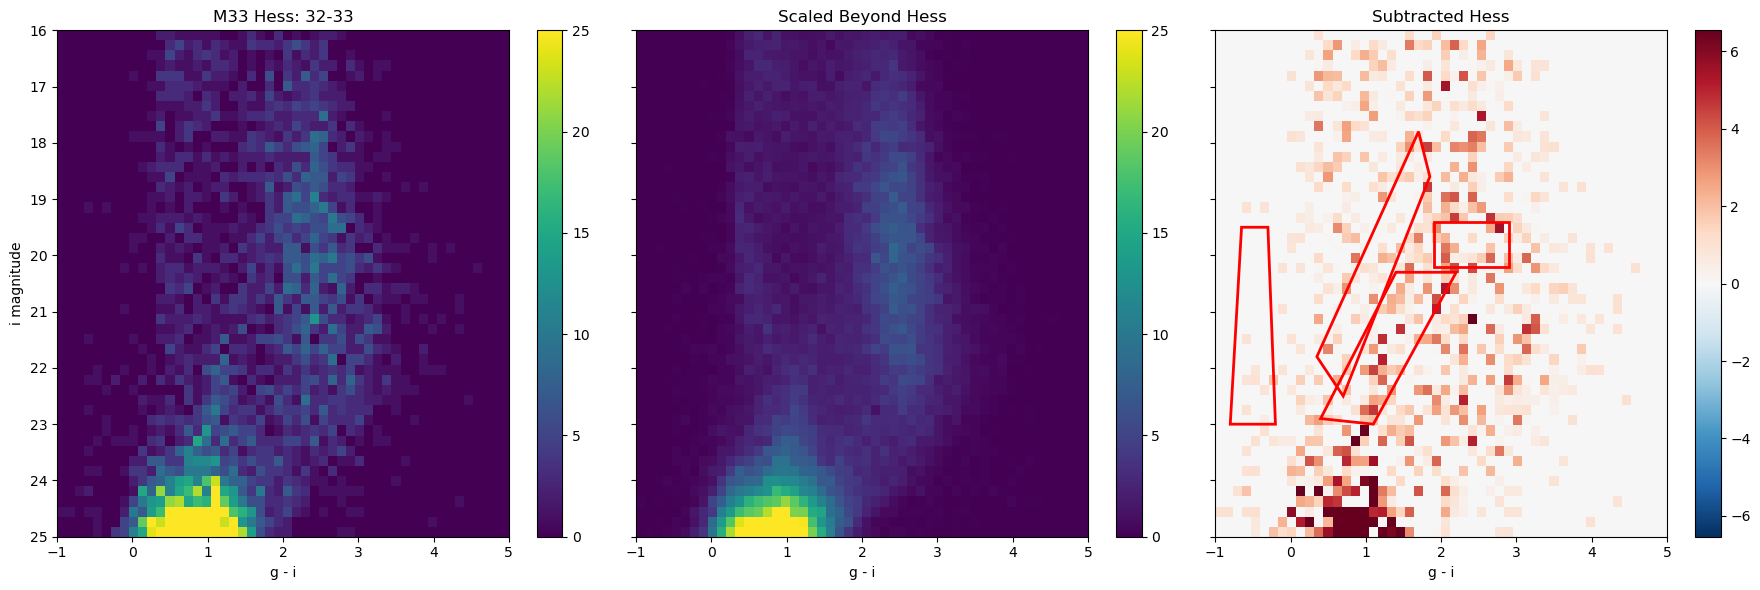

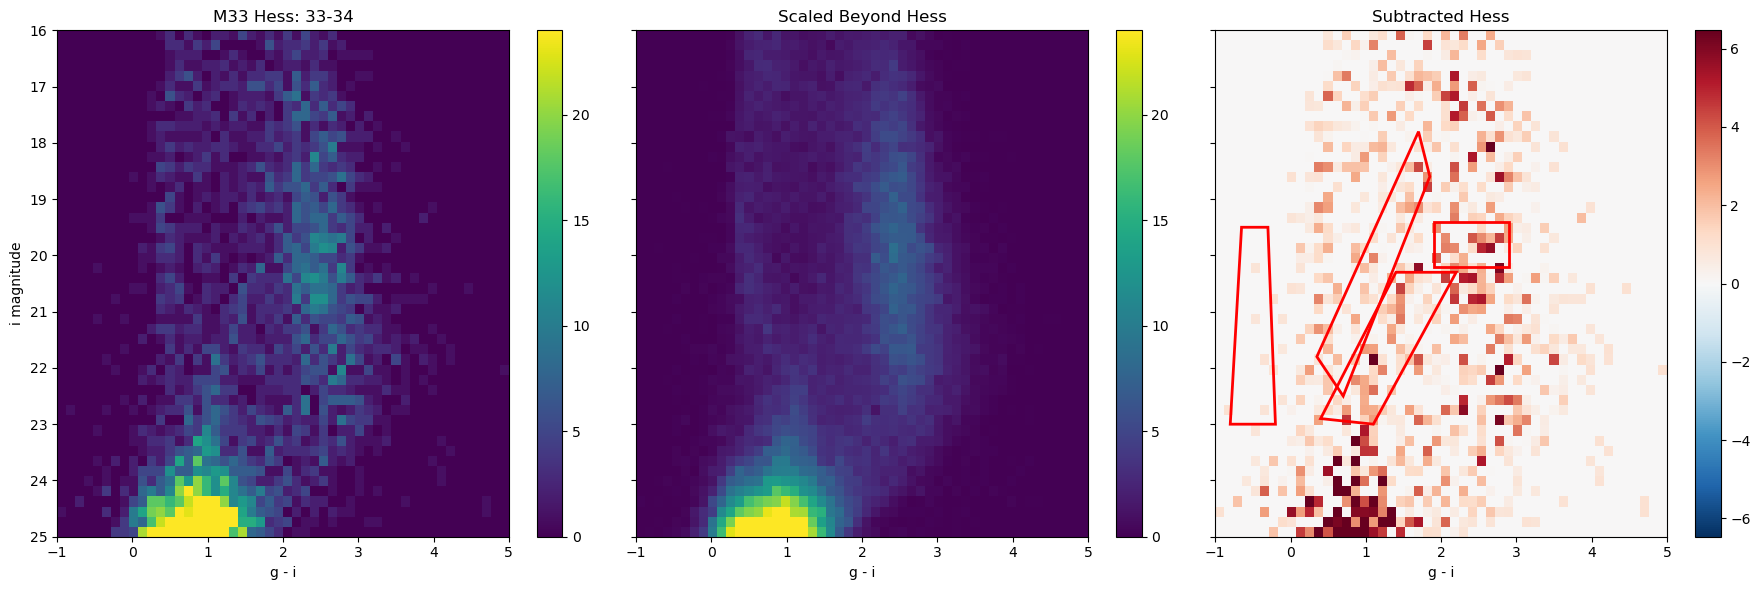

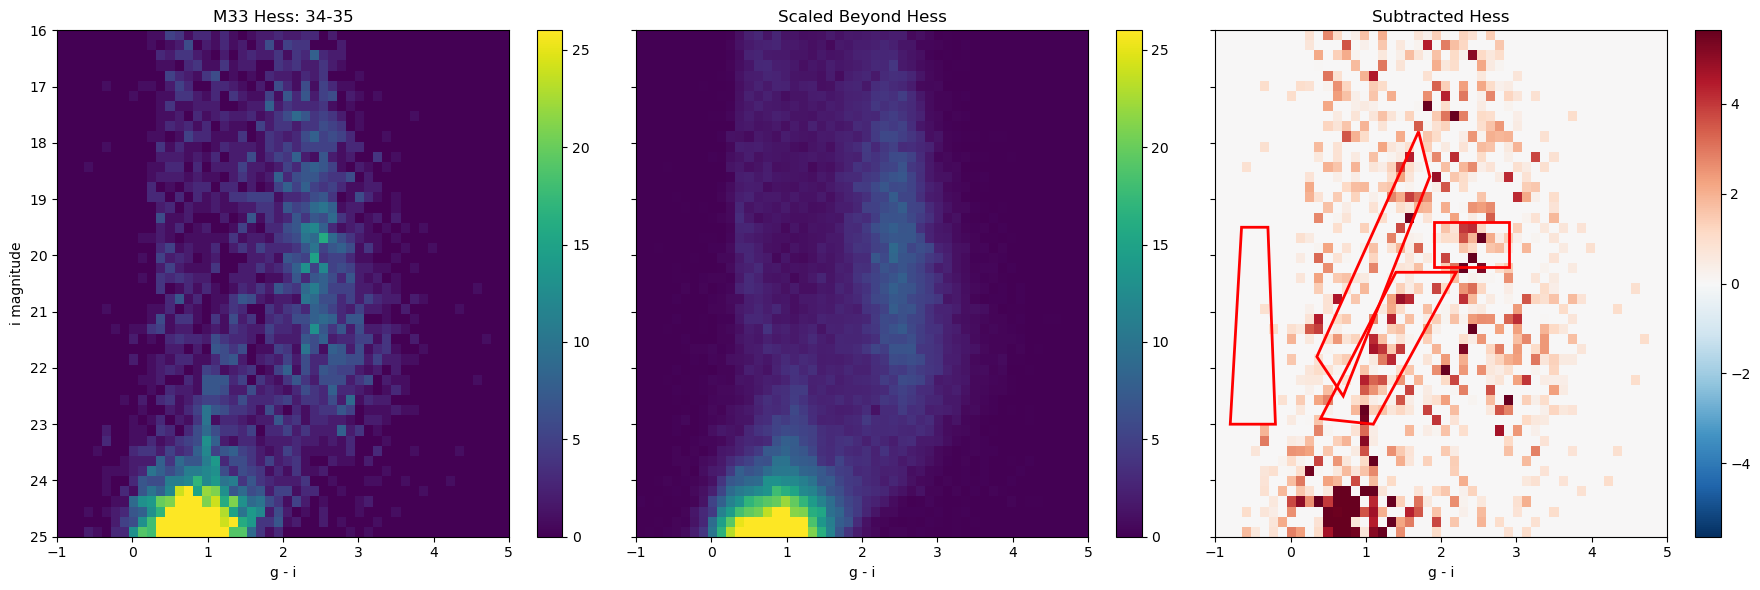

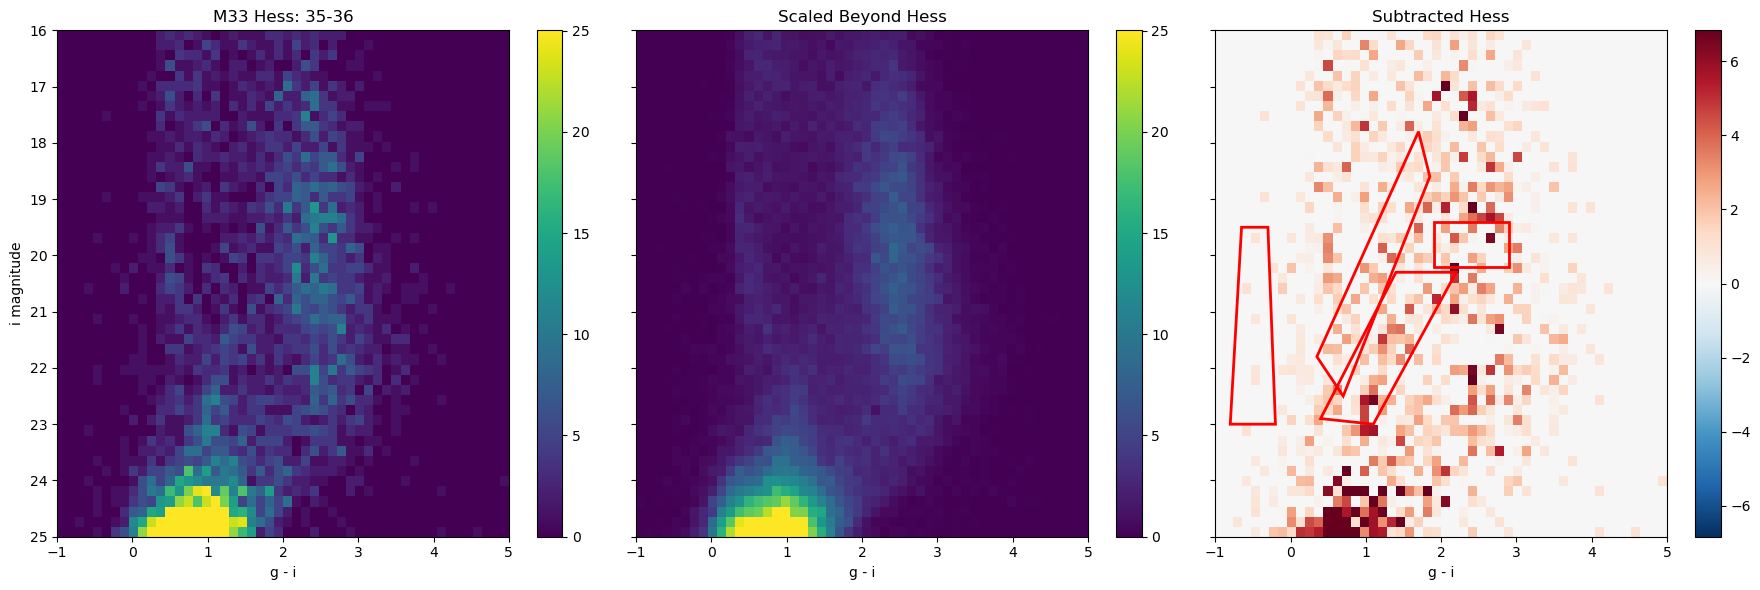

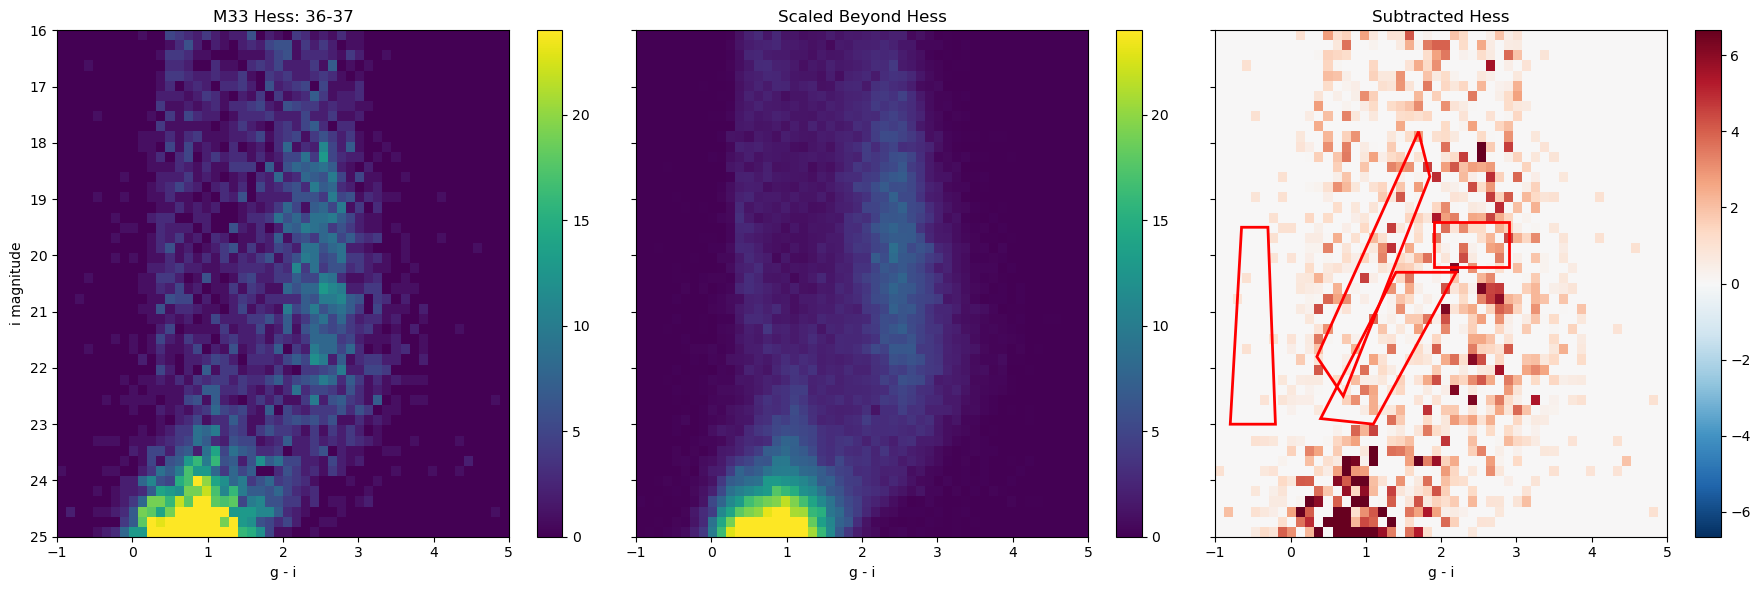

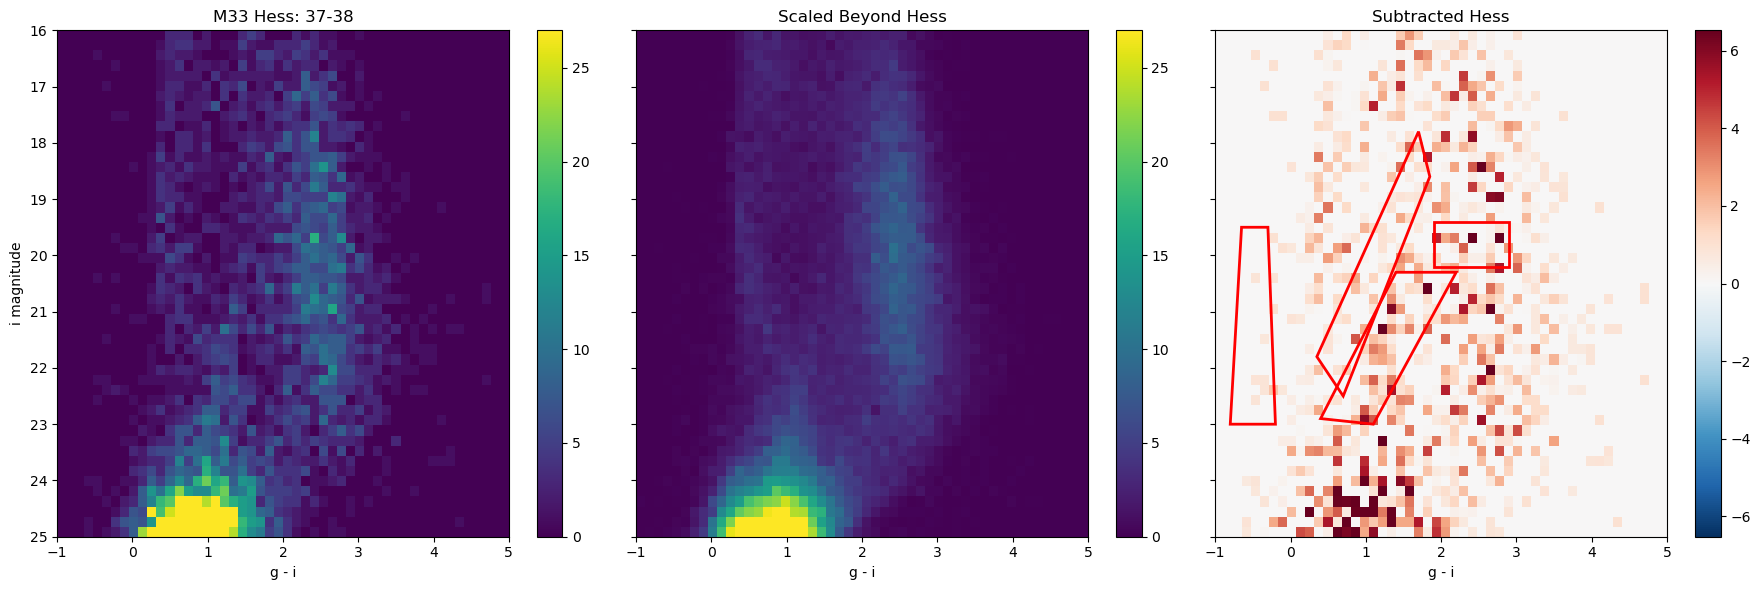

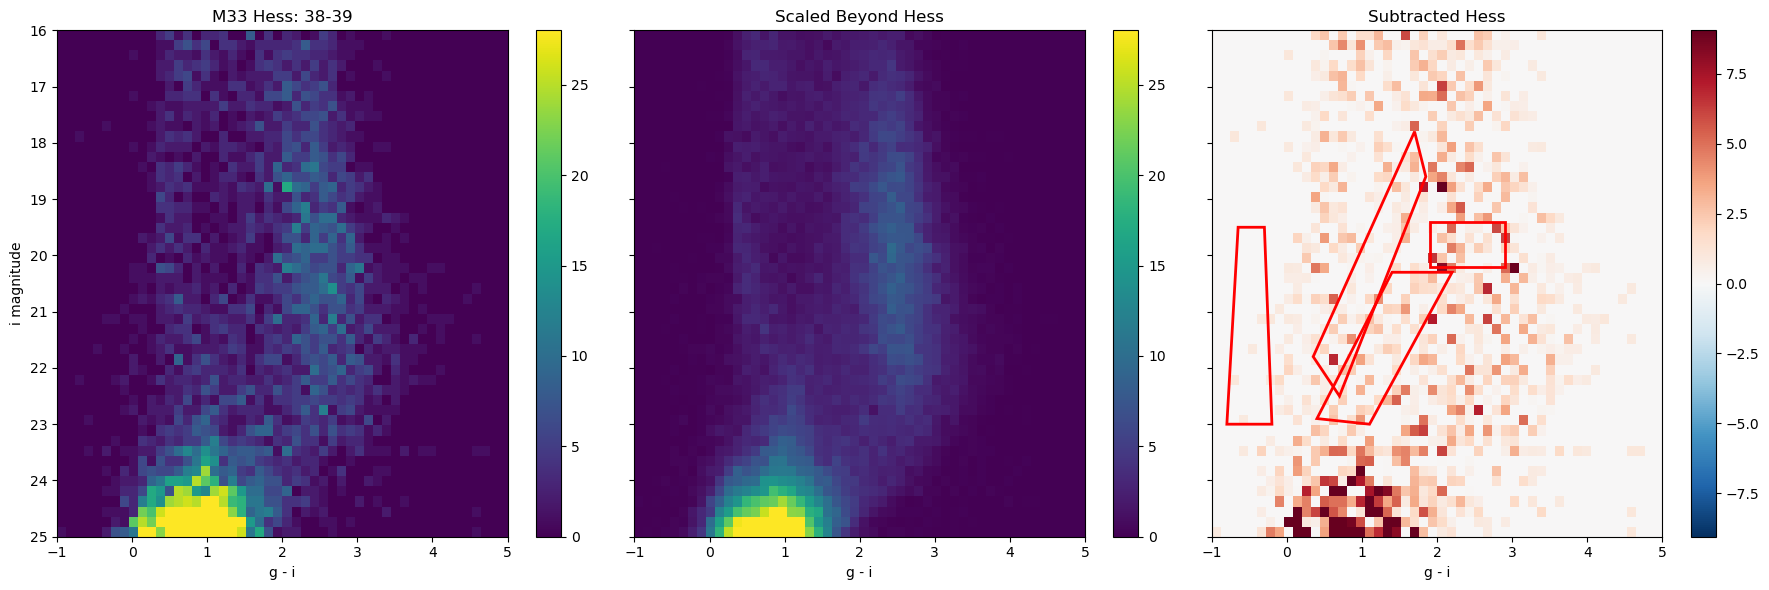

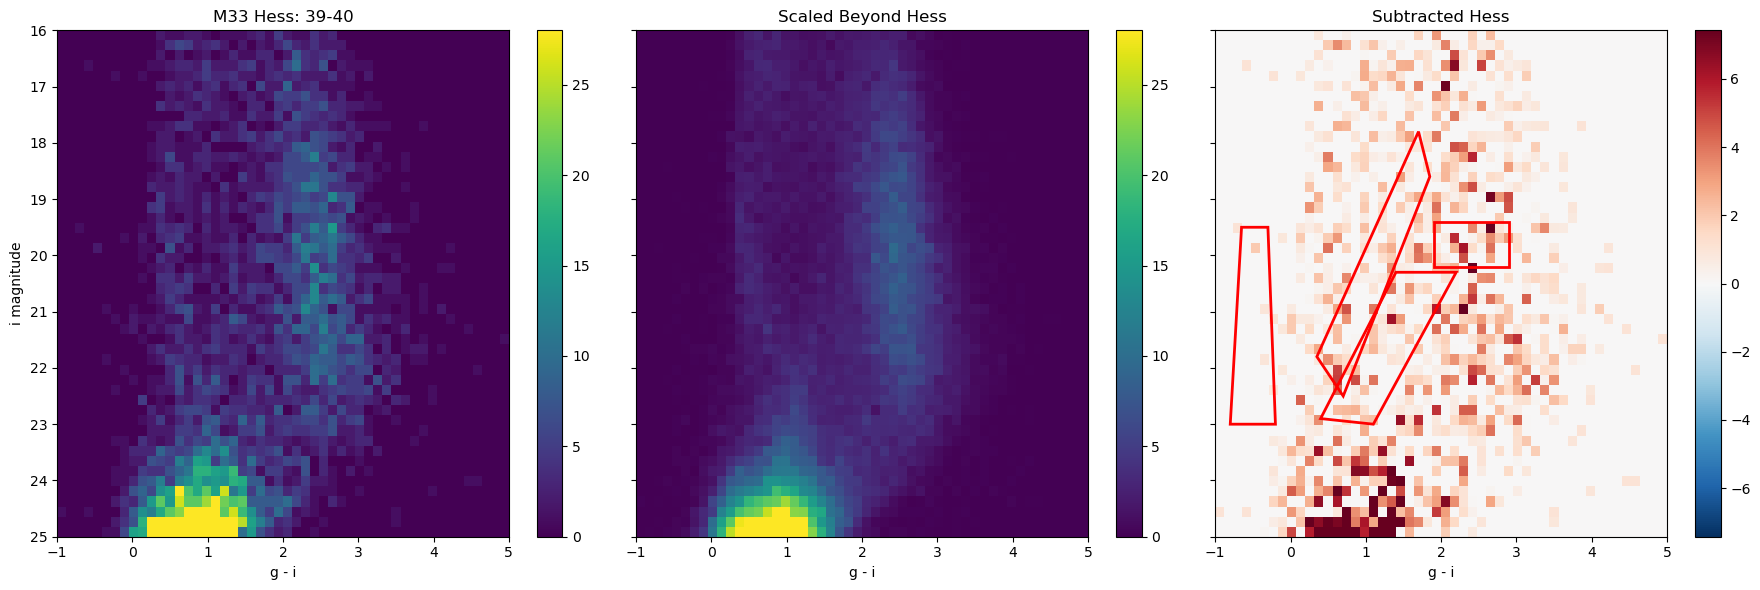

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon

# === Load processed CSV data ===
panda = pd.read_csv("panda_deproj.csv")

# === Define Area Functions ===
def elliptical_annulus_area_analytic(a_in_kpc, a_out_kpc, inc_deg):
    inc_rad = np.deg2rad(inc_deg)
    return np.pi * (a_out_kpc**2 - a_in_kpc**2) * np.cos(inc_rad)

def estimate_area_and_plot_annuli(n_points=1_00_000, max_radius_kpc=60,
                                   distance_kpc=859, PA_deg=112, inc_deg=52,
                                   area_rings=[], plot_radii_kpc=[]):
    def kpc_to_arcmin(kpc):
        return np.rad2deg(kpc / distance_kpc) * 60

    max_radius_rad = max_radius_kpc / distance_kpc
    max_radius_arcmin = np.rad2deg(max_radius_rad) * 60
    xi = np.random.uniform(-max_radius_arcmin, max_radius_arcmin, n_points)
    eta = np.random.uniform(-max_radius_arcmin, max_radius_arcmin, n_points)

    PA_rad = np.deg2rad(PA_deg)
    inc_rad = np.deg2rad(inc_deg)
    xi_rot = xi * np.cos(PA_rad) + eta * np.sin(PA_rad)
    eta_rot = -xi * np.sin(PA_rad) + eta * np.cos(PA_rad)
    eta_deproj = eta_rot / np.cos(inc_rad)
    r_arcmin = np.sqrt(xi_rot**2 + eta_deproj**2)

    areas = {}
    for a_in_kpc, a_out_kpc in area_rings:
        r_in = kpc_to_arcmin(a_in_kpc)
        r_out = kpc_to_arcmin(a_out_kpc)
        mask = (r_arcmin >= r_in) & (r_arcmin < r_out)
        n_inside = np.sum(mask)
        box_area_arcmin2 = (2 * max_radius_arcmin)**2
        arcmin2_to_sr = (np.pi / (180 * 60))**2
        box_area_sr = box_area_arcmin2 * arcmin2_to_sr
        box_area_kpc2 = box_area_sr * (distance_kpc ** 2)
        area_estimate = (n_inside / n_points) * box_area_kpc2
        areas[f"{a_in_kpc}-{a_out_kpc}"] = area_estimate

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(xi, eta, s=0.2, alpha=0.3, label='Random Points')
    for r_kpc in plot_radii_kpc:
        a = kpc_to_arcmin(r_kpc)
        b = a * np.cos(inc_rad)
        color = 'blue' if r_kpc < 40 else 'red'
        style = '--' if r_kpc % 2 == 0 else '-'
        ellipse = Ellipse((0, 0), width=2*a, height=2*b, angle=PA_deg,
                          edgecolor=color, linestyle=style, fill=False, label=f"{r_kpc} kpc")
        ax.add_patch(ellipse)

    ax.set_xlabel("ξ (arcmin)")
    ax.set_ylabel("η (arcmin)")
    ax.set_title("Deprojected Elliptical Annuli with Random Points")
    ax.set_aspect('equal')
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return areas

def make_hess(df, bins=(50, 50)):
    hist, xedges, yedges = np.histogram2d(df['color'], df['mag'], bins=bins, range=[[-1, 5], [18, 25]])
    return hist

# === Define bins (2 kpc steps beyond 15) ===
radial_bins_kpc = [(r, r + 1) for r in range(3, 40)]
beyond_bin = (40, 50)
all_bins = radial_bins_kpc + [beyond_bin]

area_results = estimate_area_and_plot_annuli(
    n_points=100_000,
    max_radius_kpc=60,
    distance_kpc=859,
    PA_deg=112,
    inc_deg=52,
    area_rings=all_bins,
    plot_radii_kpc=[r for pair in all_bins for r in pair]
)

# === Print Area Comparison Table ===
print("\n=== Area Comparison for All Bins ===")
print(f"{'Bin (kpc)':<12} {'Analytic Area':>20} {'Monte Carlo Area':>25} {'% Diff':>10}")
print("-" * 75)
for (r_in, r_out) in all_bins:
    key = f"{r_in}-{r_out}"
    area_mc = area_results[key]
    area_an = elliptical_annulus_area_analytic(r_in, r_out, inc_deg=52)
    pct_diff = 100 * (area_mc - area_an) / area_an
    print(f"{key:<12} {area_an:>20.2f} {area_mc:>25.2f} {pct_diff:>10.2f}")

# === Subtract and Plot Hess Diagrams in Linear Scale ===
beyond_area = area_results[f"{beyond_bin[0]}-{beyond_bin[1]}"]
beyond_df = panda[(panda['r_deproj_kpc'] >= beyond_bin[0]) & (panda['r_deproj_kpc'] < beyond_bin[1])]
hess_beyond = make_hess(beyond_df)

for r_in, r_out in radial_bins_kpc:
    label = f"{r_in}-{r_out}"
    bin_df = panda[(panda['r_deproj_kpc'] >= r_in) & (panda['r_deproj_kpc'] < r_out)]
    hess_m33 = make_hess(bin_df)

    scale = area_results[label] / beyond_area
    hess_scaled_beyond = scale * hess_beyond
    hess_subtracted = hess_m33 - hess_scaled_beyond

    vlim = np.percentile(np.abs(hess_m33), 99)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    im0 = axes[0].imshow(hess_m33.T, origin='upper', aspect='auto',
                         extent=[-1, 5, 25, 16], cmap='viridis',
                         vmin=0, vmax=vlim)
    axes[0].set_title(f"M33 Hess: {label}")
    axes[0].set_xlabel('g - i')
    axes[0].set_ylabel('i magnitude')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(hess_scaled_beyond.T, origin='upper', aspect='auto',
                         extent=[-1, 5, 25, 16], cmap='viridis',
                         vmin=0, vmax=vlim)
    axes[1].set_title("Scaled Beyond Hess")
    axes[1].set_xlabel('g - i')
    fig.colorbar(im1, ax=axes[1])

    vlim_diff = np.percentile(np.abs(hess_subtracted), 99)
    hess_subtracted_clipped = np.clip(hess_subtracted, 0, None)
    im2 = axes[2].imshow(hess_subtracted_clipped.T, origin='upper', aspect='auto',
                        extent=[-1, 5, 25, 16], cmap='RdBu_r',
                        vmin=-vlim_diff, vmax=vlim_diff)
    axes[2].set_title("Subtracted Hess")
    axes[2].set_xlabel('g - i')
    fig.colorbar(im2, ax=axes[2])

    # === Add Estimated Red Polygons ===
    polygon_regions = [
        [(-0.8, 23), (-0.65, 19.5), (-0.3, 19.5), (-0.2, 23)],
        [(0.7, 22.5), (0.35, 21.8), (1.7, 17.8), (1.85, 18.6)],
        [(0.4, 22.9), (1.4, 20.3), (2.2, 20.3), (1.1, 23)],
        [(1.9, 19.4), (2.9, 19.4), (2.9, 20.2), (1.9, 20.2)]
    ]
    
    for poly in polygon_regions:
        patch = Polygon(poly, closed=True, edgecolor='red', facecolor='none', linewidth=2)
        axes[2].add_patch(patch)

    plt.tight_layout()
    plt.show()

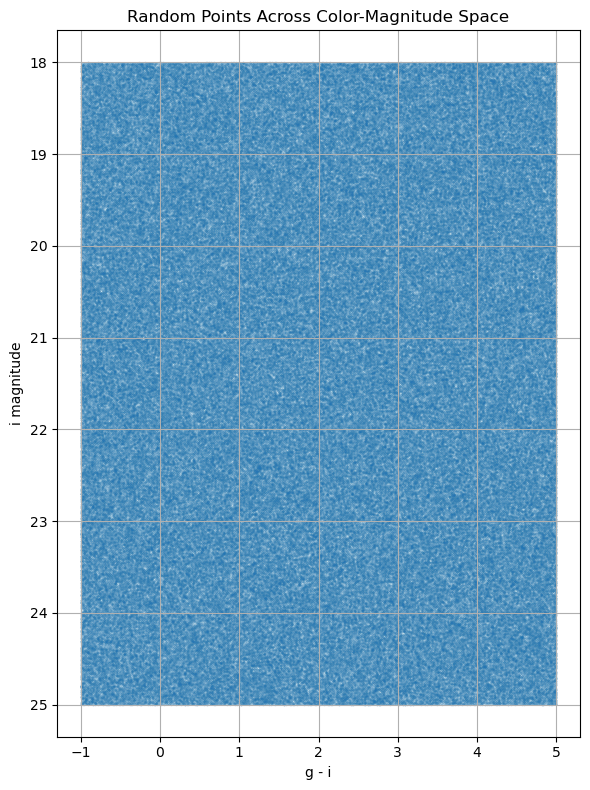

42

=== Monte Carlo Area Estimates for CMD Polygons ===
Polygon 1: Estimated area = 3.0858 mag² (fraction 0.073471)
Polygon 2: Estimated area = 1.9070 mag² (fraction 0.045405)
Polygon 3: Estimated area = 2.4194 mag² (fraction 0.057604)
Polygon 4: Estimated area = 0.8075 mag² (fraction 0.019227)


In [2]:
from matplotlib.path import Path

# === Monte Carlo estimate of polygon areas ===

# Step 1: Generate random points across the CMD plane
n_cmd_points = 1_000_000
color_range = [-1, 5]
mag_range = [18, 25]

rand_colors = np.random.uniform(color_range[0], color_range[1], n_cmd_points)
rand_mags = np.random.uniform(mag_range[0], mag_range[1], n_cmd_points)
cmd_points = np.vstack((rand_colors, rand_mags)).T

# Step 2: Define polygon regions again (must match what you plotted)
polygon_regions = [
    [(-0.8, 25), (-0.65, 18.5), (-0.3, 18.5), (-0.2, 25)],
    [(0.7, 22.5), (0.35, 21.8), (1.7, 17.8), (1.85, 18.6)],
    [(0.5, 23.9), (1.5, 20.3), (2.2, 20.3), (1.1, 24)],
    [(1.9, 19.4), (2.9, 19.4), (2.9, 20.2), (1.9, 20.2)],
]

plt.figure(figsize=(6, 8))
plt.scatter(rand_colors, rand_mags, s=0.1, alpha=0.2)
plt.gca().invert_yaxis()
plt.xlabel('g - i')
plt.ylabel('i magnitude')
plt.title('Random Points Across Color-Magnitude Space')
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 3: Estimate area using Monte Carlo
cmd_box_area = (color_range[1] - color_range[0]) * (mag_range[1] - mag_range[0])
print(cmd_box_area)
print("\n=== Monte Carlo Area Estimates for CMD Polygons ===")
for i, poly in enumerate(polygon_regions):
    path = Path(poly)
    mask = path.contains_points(cmd_points)
    frac_inside = np.sum(mask) / n_cmd_points
    poly_area = frac_inside * cmd_box_area
    print(f"Polygon {i+1}: Estimated area = {poly_area:.4f} mag² (fraction {frac_inside:.6f})")


In [3]:
from rich.table import Table
from rich.console import Console
from matplotlib.path import Path
import numpy as np

# === Extract CMD and radius values from your data ===
real_colors = panda['color'].values
real_mags = panda['mag'].values
real_radii = panda['r_deproj_kpc'].values
real_cmd_points = np.vstack((real_colors, real_mags)).T

# === Define the CMD polygon regions ===
polygon_regions = [
    [(-0.8, 25), (-0.65, 18.5), (-0.3, 18.5), (-0.2, 25)],
    [(0.7, 22.5), (0.35, 21.8), (1.7, 17.8), (1.85, 18.6)],
    [(0.5, 23.9), (1.5, 20.3), (2.2, 20.3), (1.1, 24)],
    [(1.9, 19.4), (2.9, 19.4), (2.9, 20.2), (1.9, 20.2)],
]



# === Precompute masks for each polygon
polygon_masks = [Path(poly).contains_points(real_cmd_points) for poly in polygon_regions]

# === Prepare Rich table
table = Table(title="Star Counts per Polygon by Radial Bin")
table.add_column("Bin (kpc)", justify="right")
for i in range(1, 5):
    table.add_column(f"Polygon {i}", justify="right")

# === Fill table
for r_in, r_out in radial_bins_kpc:
    radial_mask = (real_radii >= r_in) & (real_radii < r_out)
    row = [f"{r_in}-{r_out}"]
    for poly_mask in polygon_masks:
        count = np.sum(poly_mask & radial_mask)
        row.append(str(count))
    table.add_row(*row)

# === Display the table
console = Console()
console.print(table)

            Star Counts per Polygon by Radial Bin            
┏━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Bin (kpc) ┃ Polygon 1 ┃ Polygon 2 ┃ Polygon 3 ┃ Polygon 4 ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━┩
│       3-4 │      1879 │       916 │      4288 │       141 │
│       4-5 │      2806 │       872 │      7255 │       137 │
│       5-6 │      3429 │       960 │     11037 │       124 │
│       6-7 │      4140 │       796 │     13679 │       113 │
│       7-8 │      3183 │       465 │     14509 │       106 │
│       8-9 │      1009 │       172 │     11572 │        93 │
│      9-10 │       413 │       116 │      6237 │        90 │
│     10-11 │       225 │       114 │      3423 │        90 │
│     11-12 │       156 │       105 │      2578 │        85 │
│     12-13 │       115 │        93 │      2492 │       104 │
│     13-14 │        63 │       110 │      1618 │       138 │
│     14-15 │        44 │        91 │      1084 │       106 │
│     15-16 │        41 │       107 │       793 │       114 │
│     16-17 │        31 │       103 │       655 │       120 │
│     17-18 │        19 │       117 │       564 │       121 │
│     18-19 │        19 │       121 │       491 │       124 │
│     19-20 │        23 │       115 │       490 │       129 │
│     20-21 │        22 │       114 │       517 │       113 │
│     21-22 │        21 │       122 │       449 │       142 │
│     22-23 │        11 │       132 │       469 │       139 │
│     23-24 │        11 │       122 │       485 │       120 │
│     24-25 │        22 │       131 │       538 │       177 │
│     25-26 │        25 │       159 │       553 │       172 │
│     26-27 │        14 │       140 │       547 │       178 │
│     27-28 │        23 │       162 │       571 │       150 │
│     28-29 │        29 │       173 │       545 │       181 │
│     29-30 │        18 │       163 │       541 │       201 │
│     30-31 │        18 │       181 │       519 │       213 │
│     31-32 │        24 │       169 │       541 │       225 │
│     32-33 │        26 │       163 │       488 │       198 │
│     33-34 │        23 │       194 │       527 │       215 │
│     34-35 │        24 │       199 │       518 │       211 │
│     35-36 │        20 │       190 │       518 │       206 │
│     36-37 │        20 │       230 │       484 │       240 │
│     37-38 │        20 │       203 │       575 │       245 │
│     38-39 │        24 │       217 │       517 │       273 │
│     39-40 │         8 │       232 │       550 │       252 │
└───────────┴───────────┴───────────┴───────────┴───────────┘

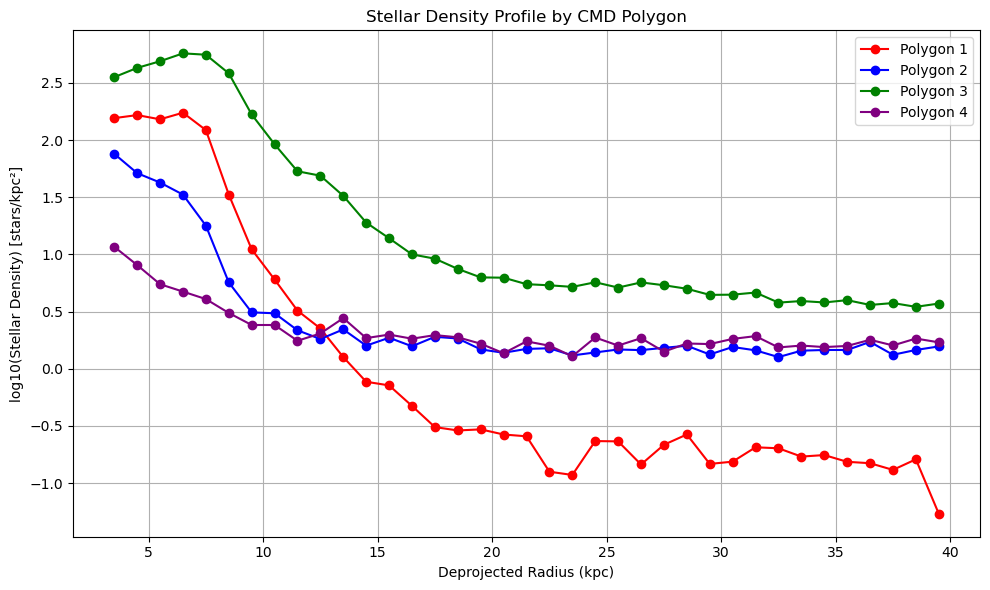

In [4]:
import matplotlib.pyplot as plt
import numpy as np


# Precompute bin midpoints and areas
bin_labels = [f"{r0}-{r1}" for (r0, r1) in radial_bins_kpc]
bin_midpoints = [(r0 + r1) / 2 for (r0, r1) in radial_bins_kpc]
bin_areas = [area_results[f"{r0}-{r1}"] for (r0, r1) in radial_bins_kpc]  # from your Monte Carlo output

# Recalculate star counts per polygon per bin
real_colors = panda['color'].values
real_mags = panda['mag'].values
real_radii = panda['r_deproj_kpc'].values
real_cmd_points = np.vstack((real_colors, real_mags)).T

polygon_regions = [
    [(-0.8, 25), (-0.65, 18.5), (-0.3, 18.5), (-0.2, 25)],
    [(0.7, 22.5), (0.35, 21.8), (1.7, 17.8), (1.85, 18.6)],
    [(0.5, 23.9), (1.5, 20.3), (2.2, 20.3), (1.1, 24)],
    [(1.9, 19.4), (2.9, 19.4), (2.9, 20.2), (1.9, 20.2)],
]
polygon_masks = [Path(poly).contains_points(real_cmd_points) for poly in polygon_regions]

# Collect densities
log_densities_per_poly = []
for mask in polygon_masks:
    log_densities = []
    for (r0, r1), area in zip(radial_bins_kpc, bin_areas):
        radial_mask = (real_radii >= r0) & (real_radii < r1)
        count = np.sum(mask & radial_mask)
        density = count / area if area > 0 else 0
        log_density = np.log10(density) if density > 0 else np.nan
        log_densities.append(log_density)
    log_densities_per_poly.append(log_densities)

# Plot
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'purple']
for i, log_densities in enumerate(log_densities_per_poly):
    plt.plot(bin_midpoints, log_densities, marker='o', label=f'Polygon {i+1}', color=colors[i])

plt.xlabel("Deprojected Radius (kpc)")
plt.ylabel("log10(Stellar Density) [stars/kpc²]")
plt.title("Stellar Density Profile by CMD Polygon")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
from matplotlib.path import Path

# Define polygon masks (already known CMD boxes)
polygon_paths = [Path(poly) for poly in polygon_regions]
beyond_area = area_results["40-50"]

# Prepare CMD points
real_cmd_points = np.vstack((panda['color'].values, panda['mag'].values)).T
real_radii = panda['r_deproj_kpc'].values
beyond_mask = (real_radii >= 40) & (real_radii < 50)

print("\n=== Foreground vs M33 Star Fractions by Radial Bin ===")
print(f"{'Bin (kpc)':<10} {'FG Stars':>10} {'M33 Stars':>10} {'Total':>10} {'FG/Total':>10} {'M33/Total':>12}")
print("-" * 70)

for r0, r1 in radial_bins_kpc:
    bin_key = f"{r0}-{r1}"
    bin_mask = (real_radii >= r0) & (real_radii < r1)
    bin_area = area_results[bin_key]
    area_ratio = bin_area / beyond_area

    fg_total = 0
    m33_total = 0

    for path in polygon_paths:
        # Foreground (from beyond bin)
        beyond_inside = path.contains_points(real_cmd_points[beyond_mask])
        fg_total += area_ratio * np.sum(beyond_inside)

        # M33 stars (from current bin)
        bin_inside = path.contains_points(real_cmd_points[bin_mask])
        m33_total += np.sum(bin_inside)

    total = fg_total + m33_total
    fg_frac = fg_total / total if total > 0 else np.nan
    m33_frac = m33_total / total if total > 0 else np.nan

    print(f"{bin_key:<10} {fg_total:10.1f} {m33_total:10.1f} {total:10.1f} {fg_frac:10.3f} {m33_frac:12.3f}")



=== Foreground vs M33 Star Fractions by Radial Bin ===
Bin (kpc)    FG Stars  M33 Stars      Total   FG/Total    M33/Total
----------------------------------------------------------------------
3-4              74.6     7224.0     7298.6      0.010        0.990
4-5             104.9    11070.0    11174.9      0.009        0.991
5-6             139.5    15550.0    15689.5      0.009        0.991
6-7             147.5    18728.0    18875.5      0.008        0.992
7-8             160.8    18263.0    18423.8      0.009        0.991
8-9             186.6    12846.0    13032.6      0.014        0.986
9-10            230.1     6856.0     7086.1      0.032        0.968
10-11           230.1     3852.0     4082.1      0.056        0.944
11-12           298.6     2924.0     3222.6      0.093        0.907
12-13           315.4     2804.0     3119.4      0.101        0.899
13-14           307.4     1929.0     2236.4      0.137        0.863
14-15           352.8     1325.0     1677.8      0.210   

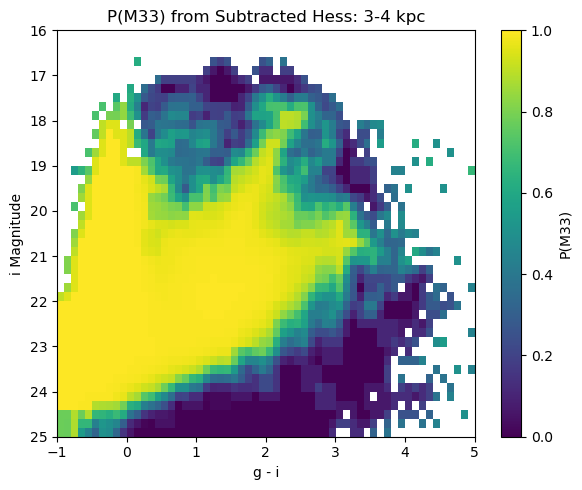

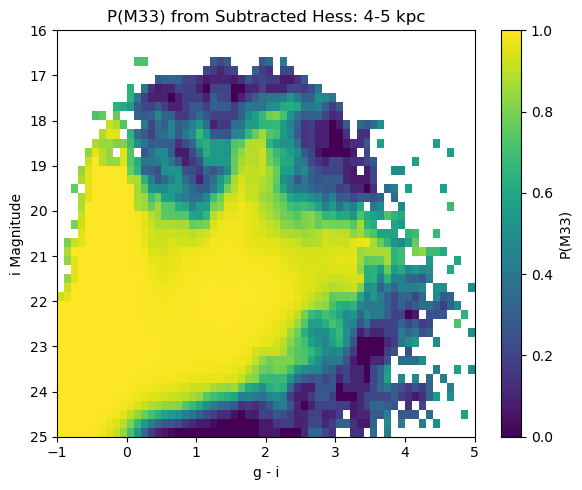

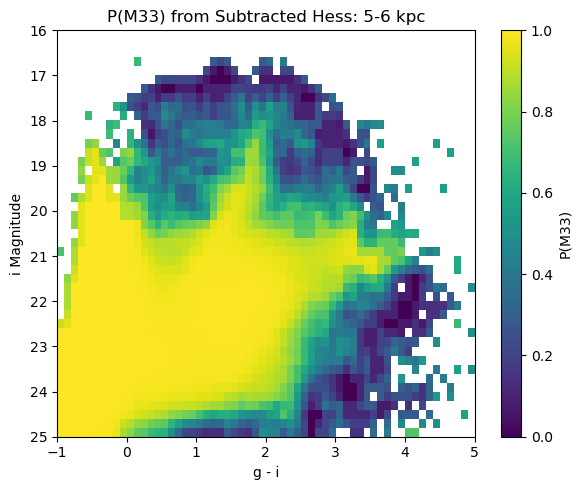

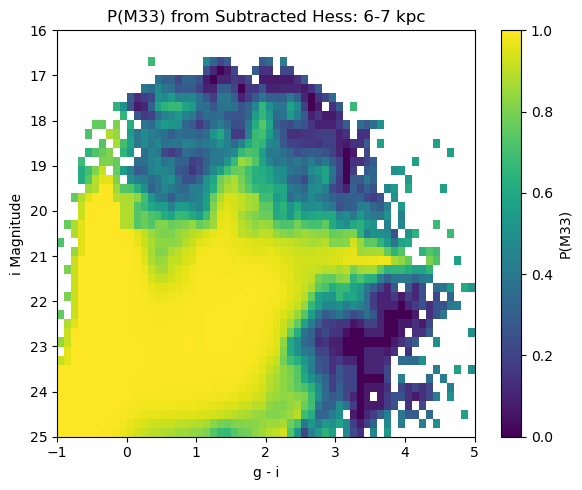

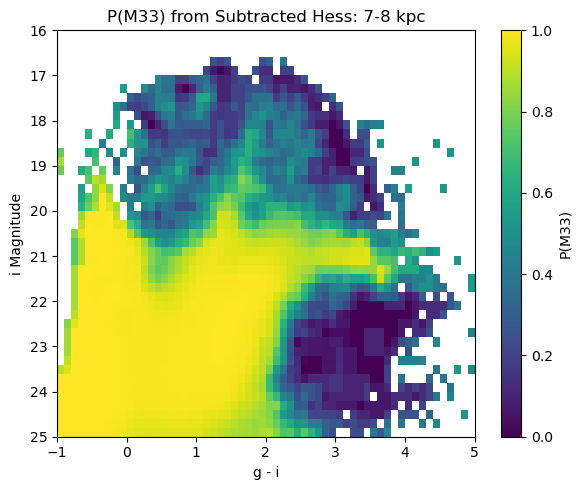

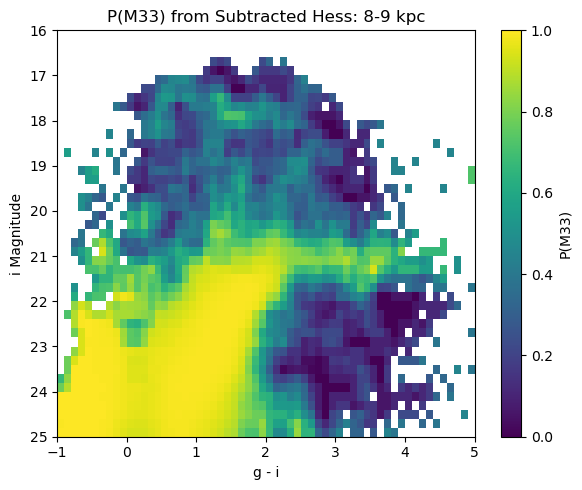

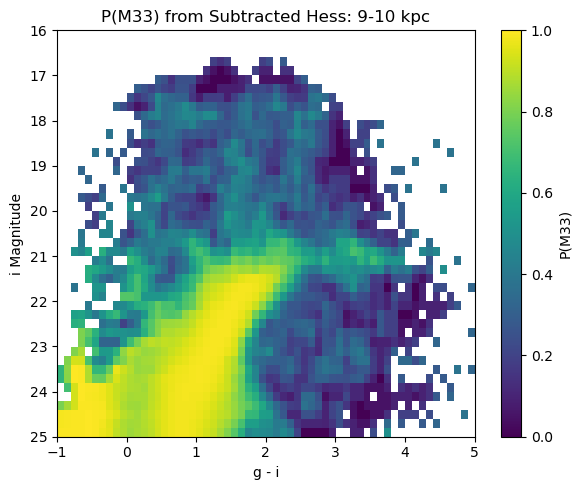

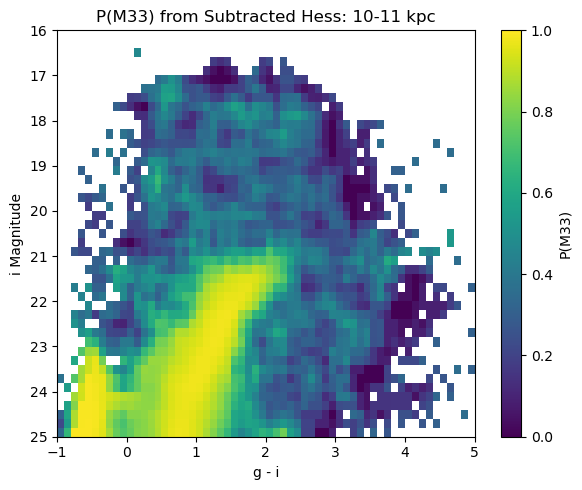

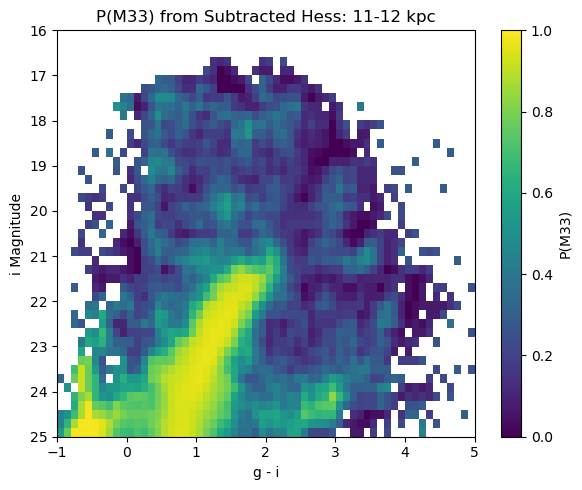

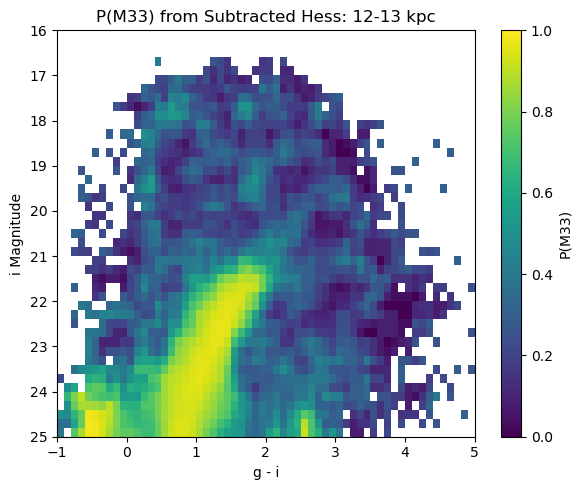

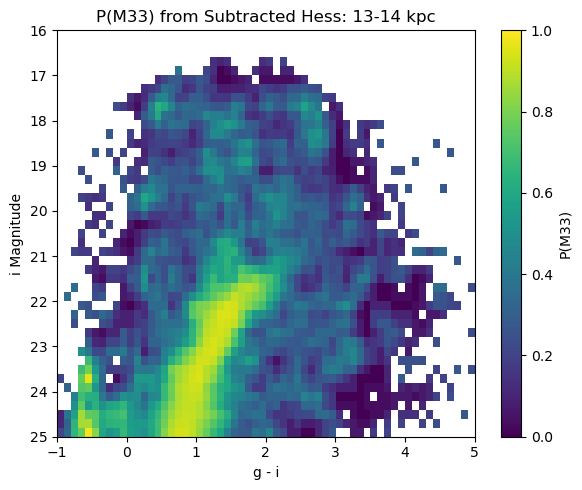

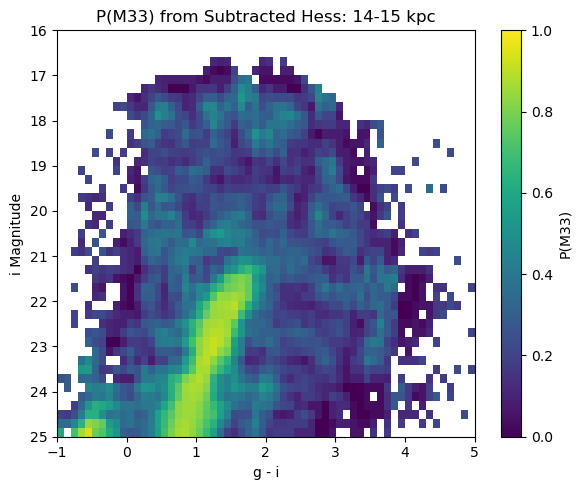

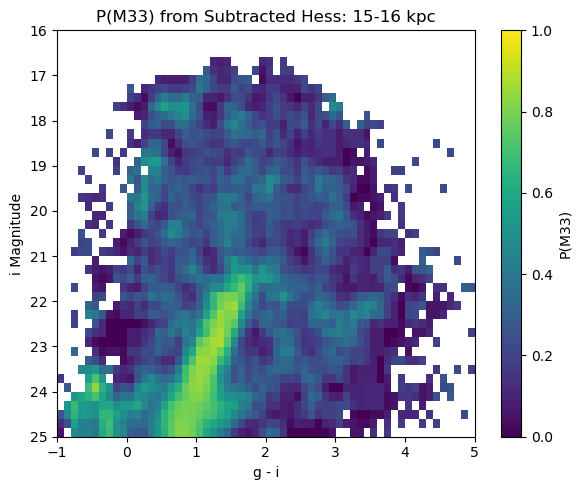

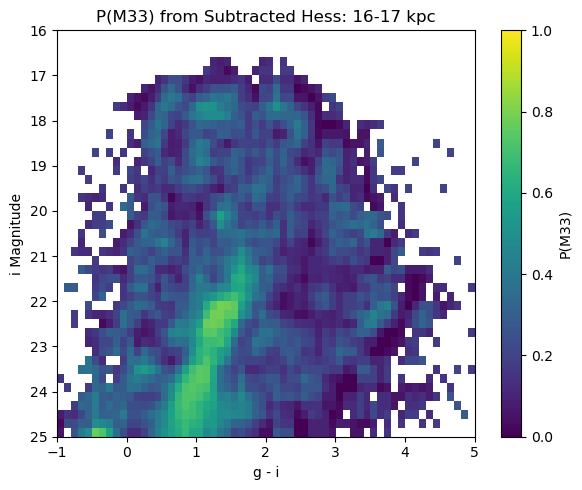

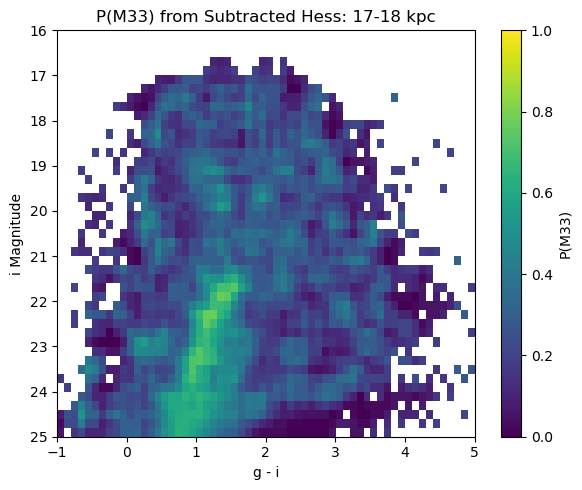

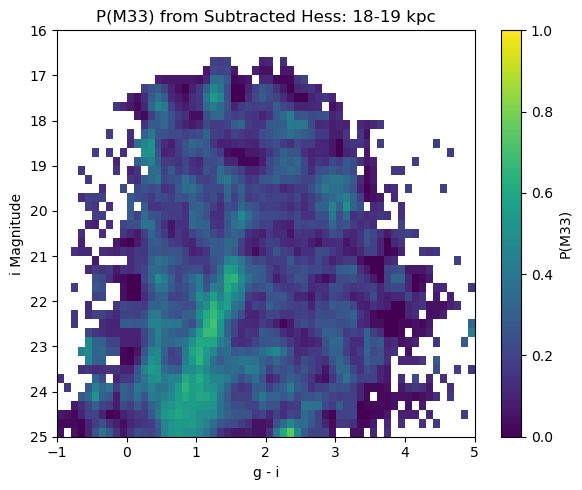

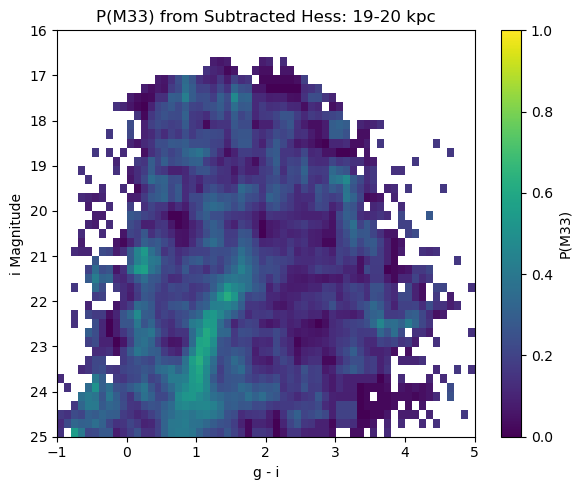

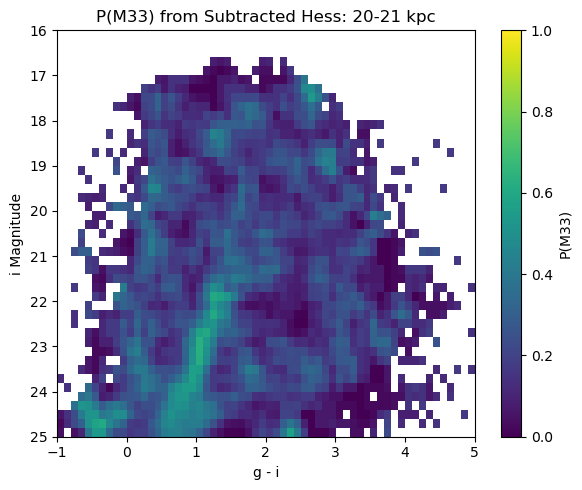

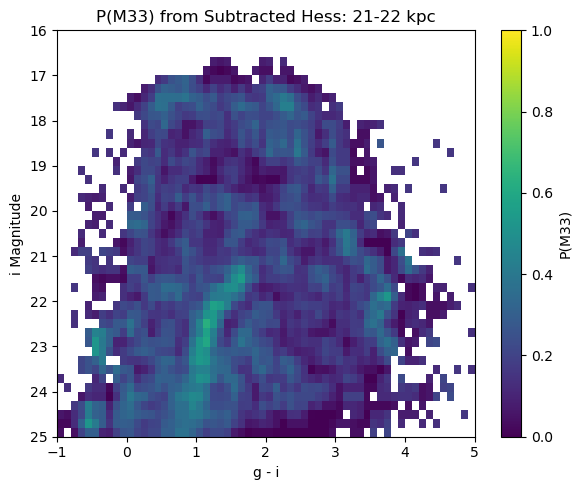

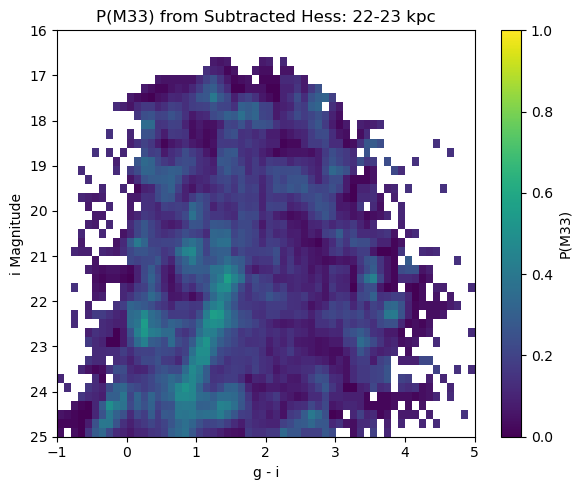

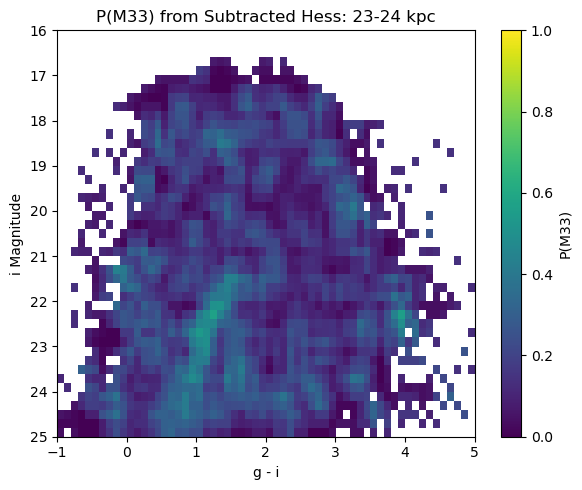

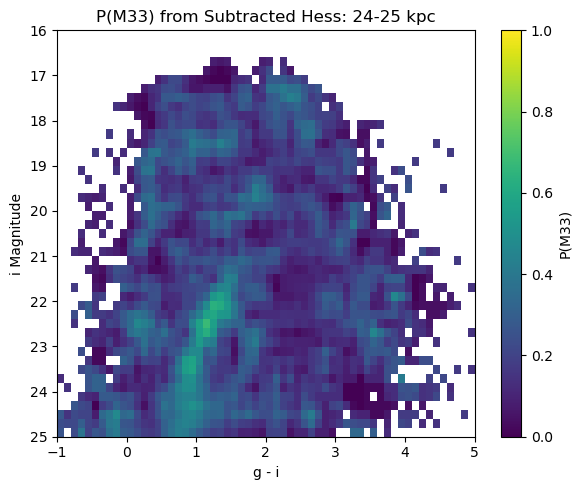

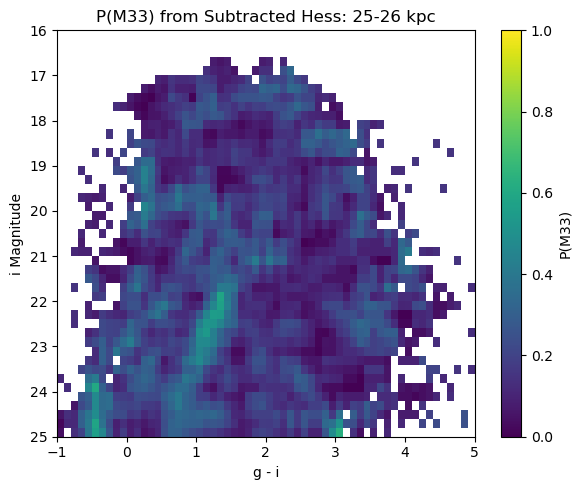

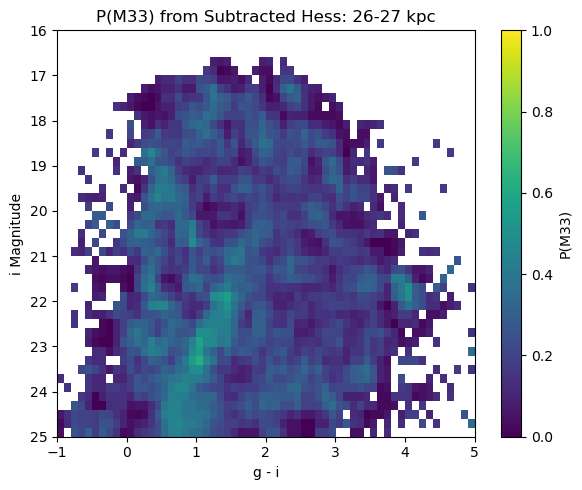

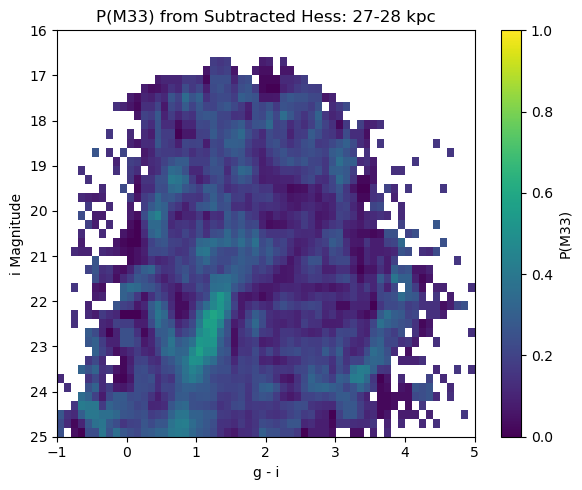

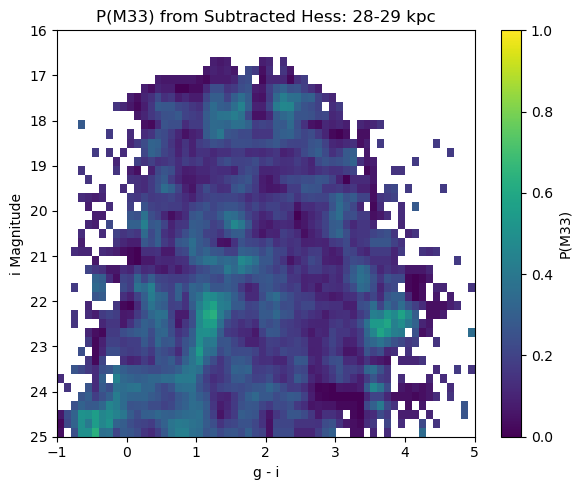

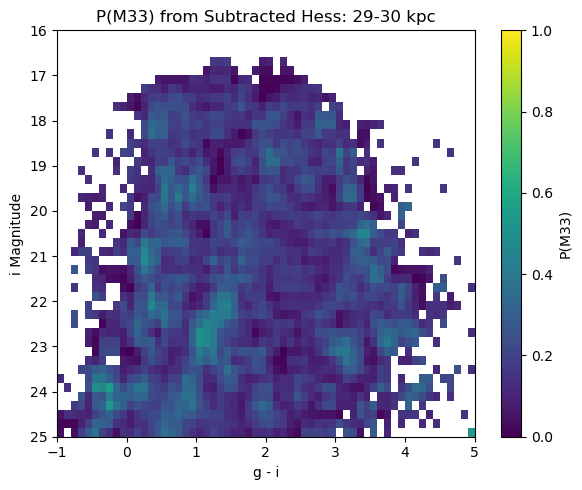

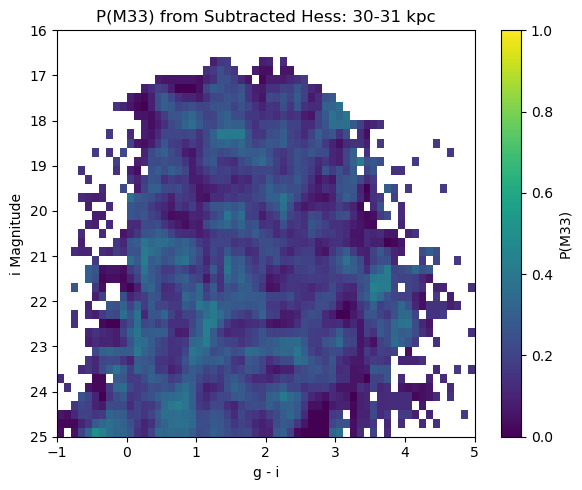

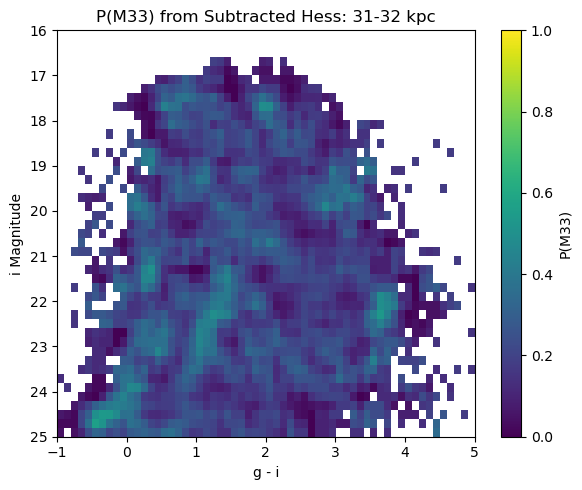

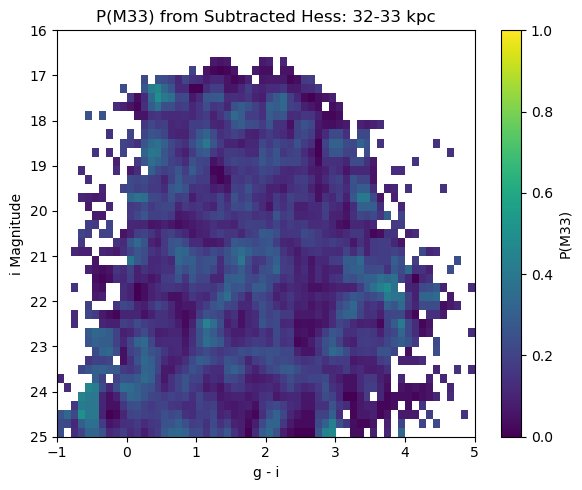

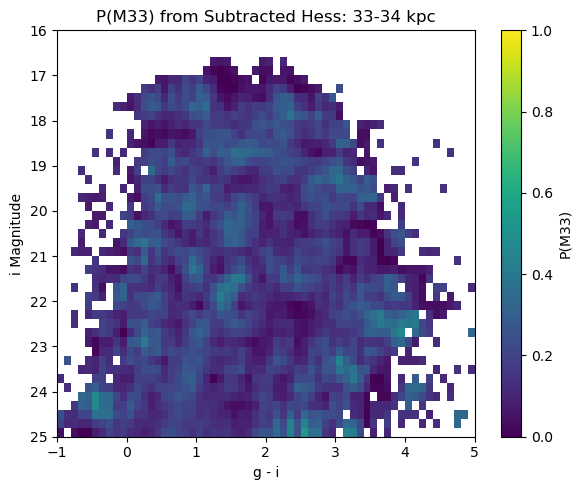

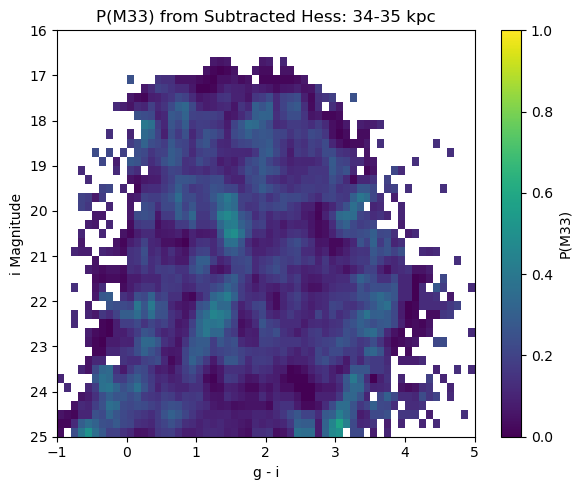

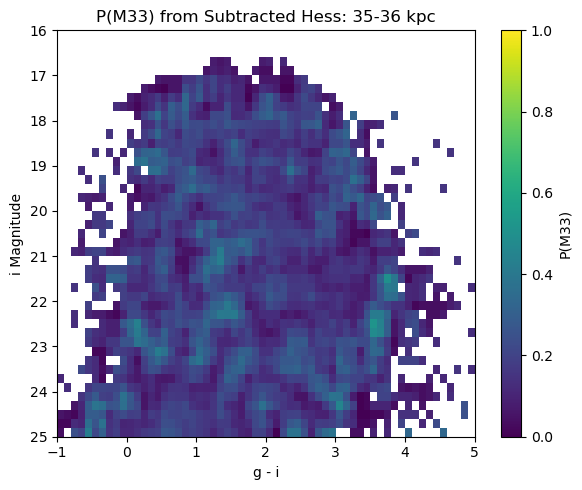

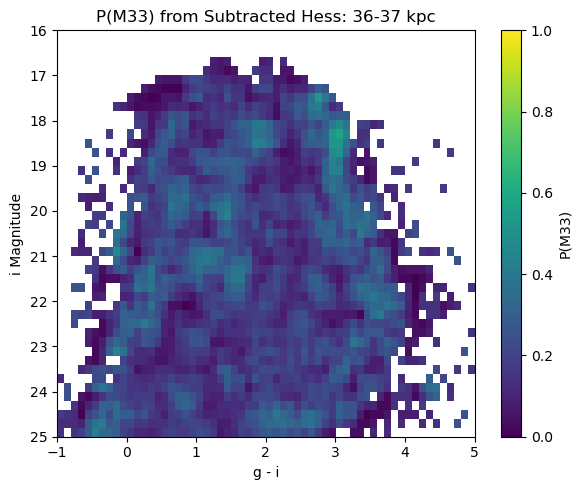

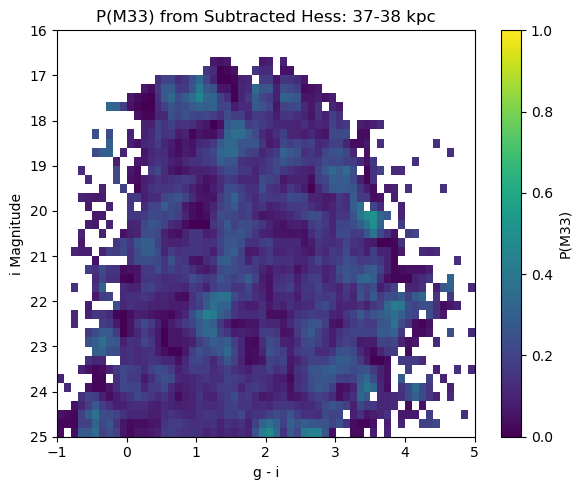

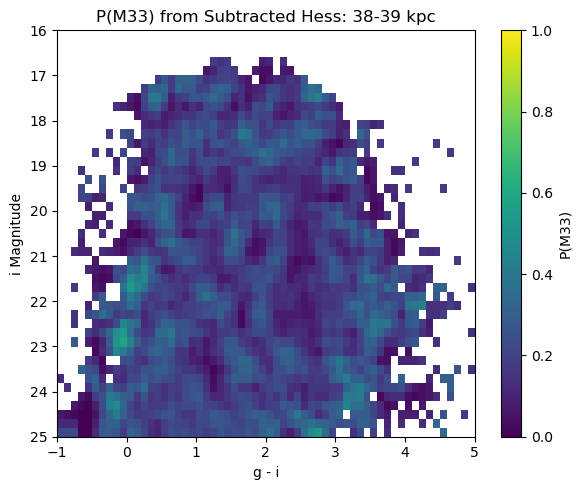

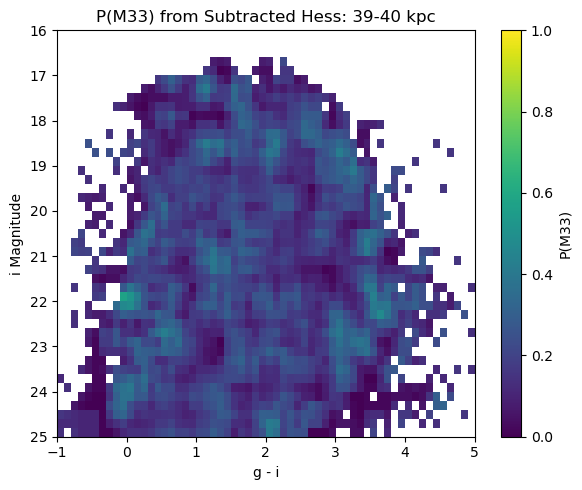

✅ GIF created as 'p_m33_cmd_probabilities.gif'


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
import numpy.ma as ma
import os
from PIL import Image

# === Setup for GIF Creation ===
os.makedirs("p_m33_frames", exist_ok=True)
frame_paths = []

color_bins = np.linspace(-1, 5, 61)   # 0.1 mag color bins from -1 to 3
mag_bins = np.linspace(16, 25, 46)    # 0.2 mag bins from mag 16 to 25
extent = [color_bins[0], color_bins[-1], mag_bins[-1], mag_bins[0]]

beyond_mask = (real_radii >= 40) & (real_radii < 50)
beyond_area = area_results["40-50"]

fg_hist, _, _ = np.histogram2d(
    real_colors[beyond_mask],
    real_mags[beyond_mask],
    bins=[color_bins, mag_bins]
)
p_m33_dict = {}

# === Loop over radial bins ===
for r0, r1 in radial_bins_kpc:
    bin_key = f"{r0}-{r1}"
    bin_mask = (real_radii >= r0) & (real_radii < r1)
    bin_area = area_results[bin_key]
    area_ratio = bin_area / beyond_area

    # Get M33+FG histogram from current bin
    hess_m33, _, _ = np.histogram2d(
        real_colors[bin_mask],
        real_mags[bin_mask],
        bins=[color_bins, mag_bins]
    )

    # Scale the FG histogram
    fg_scaled = fg_hist * area_ratio

    # Subtract to estimate pure M33 stars
    hess_subtracted = np.clip(hess_m33 - fg_scaled, 0, None)

    # Calculate raw probabilities
    total = hess_subtracted + fg_scaled
    with np.errstate(divide='ignore', invalid='ignore'):
        p_m33 = np.where(total > 0, hess_subtracted / total, np.nan)

    # Smooth P(M33) while ignoring NaNs
    p_m33_masked = ma.masked_invalid(p_m33)
    mean_val = p_m33_masked.mean()
    p_m33_filled = p_m33_masked.filled(mean_val)
    p_m33_smooth = uniform_filter(p_m33_filled, size=3, mode='nearest')
    p_m33_smooth[np.isnan(p_m33)] = np.nan  # restore NaNs
    p_m33_dict[bin_key] = p_m33_smooth

    # Plot and save to frame
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(p_m33_smooth.T, origin='upper', extent=extent,
                   aspect='auto', cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label="P(M33)")
    ax.set_title(f"P(M33) from Subtracted Hess: {bin_key} kpc")
    ax.set_xlabel("g - i")
    ax.set_ylabel("i Magnitude")
    plt.tight_layout()

    frame_path = f"p_m33_frames/frame_{r0:02d}_{r1:02d}.png"
    plt.savefig(frame_path)
    plt.show()
    plt.close(fig)
    frame_paths.append(frame_path)

# === Create the GIF using PIL ===
frames = [Image.open(fp).convert('RGB') for fp in frame_paths]
durations = [300] * len(frames)  # Duration in ms per frame (500ms = 0.5s)

frames[0].save(
    "p_m33_cmd_probabilities.gif",
    save_all=True,
    append_images=frames[1:],
    duration=durations,
    loop=0  # Loop forever
)

print("✅ GIF created as 'p_m33_cmd_probabilities.gif'")


In [8]:
from funcs import *


with fits.open("../Tables/m33_vels_stars_inc22B_donedupes.fits") as hdul:
    data = hdul[1].data.astype(hdul[1].data.dtype.newbyteorder('='))
    new_df = pd.DataFrame(data).copy()

new_df['color'] = new_df['g'] - new_df['i']
new_df['mag'] = new_df['i']
new_df = compute_deprojected_radius_tilted_ring(new_df)
# === You must have this from previous code ===
# p_m33_dict = {"bin_key": p_m33_smooth_array}
# bin_edges = [(r0, r1), ...]  # from radial_bins_kpc
# color_bins, mag_bins = np.linspace(...), np.linspace(...)
# extent = [color_bins[0], color_bins[-1], mag_bins[-1], mag_bins[0]]

# === Function to get bin index ===
def get_bin_index(value, bins):
    idx = np.digitize([value], bins)[0] - 1
    if idx < 0 or idx >= len(bins) - 1:
        return None
    return idx


# === Assign probability to each star ===
probs = []
for _, row in new_df.iterrows():
    radius = row['r_deproj_kpc']
    color = row['color']
    mag = row['mag']

    # Find the radial bin
    for (r0, r1), key in zip(radial_bins_kpc, p_m33_dict.keys()):
        if r0 <= radius < r1:
            p_m33_map = p_m33_dict[key]
            c_idx = get_bin_index(color, color_bins)
            m_idx = get_bin_index(mag, mag_bins)

            if c_idx is not None and m_idx is not None:
                prob = p_m33_map[c_idx, m_idx]
            else:
                prob = np.nan
            break
    else:
        prob = np.nan  # radius outside available bins

    probs.append(prob)

new_df['p_m33'] = probs




Deprojecting: 100%|████████████████████████| 5775/5775 [00:08<00:00, 691.61it/s]


Counts used for probability-based analysis
(FG/WCN/CBN excluded; unflagged 'NONE' excluded)
Classified, non-FG/WCN/CBN sample:          N = 1594
High-probability members (P(M33) > 0.75): N = 1391
Rejected by probability cut only:           N = 203

BadIndex (classified, non-FG/WCN/CBN, failing P(M33) cut):
[548, 670, 767, 769, 831, 919, 1038, 1053, 1130, 1138, 1139, 1141, 1473, 1970, 2497, 2518, 2595, 2598, 2619, 2626, 2627, 2628, 2631, 2635, 2639, 2645, 2647, 2648, 2706, 2711, 2717, 2718, 2739, 2741, 2742, 2747, 2752, 2754, 2755, 2787, 2950, 2992, 3067, 3090, 3113, 3136, 3140, 3146, 3153, 3165, 3167, 3178, 3181, 3183, 3210, 3252, 3255, 3258, 3261, 3264, 3266, 3268, 3280, 3281, 3286, 3289, 3290, 3291, 3292, 3294, 3298, 3300, 3306, 3307, 3311, 3315, 3321, 3323, 3325, 3326, 3331, 3332, 3333, 3334, 3336, 3400, 3454, 3457, 3460, 3462, 3463, 3469, 3470, 3472, 3473, 3479, 3484, 3491, 3493, 3501, 3507, 3552, 3595, 4175, 4311, 4330, 4331, 4333, 4335, 4337, 4339, 4340, 4341, 4343, 4345, 4351, 4

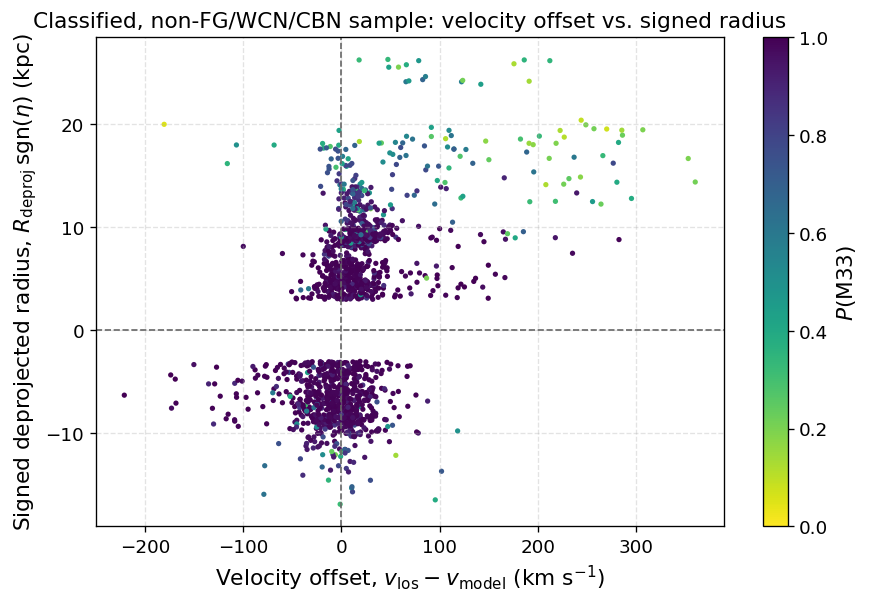

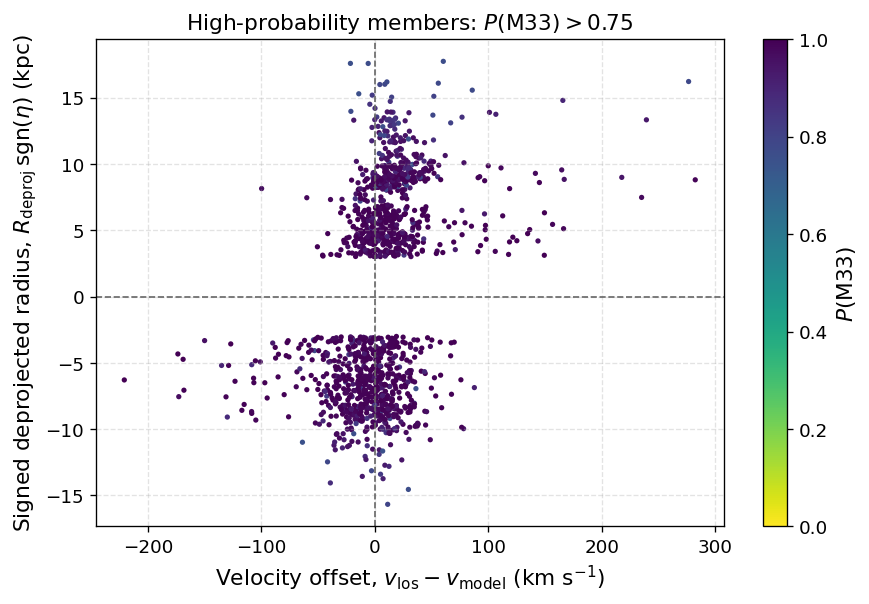

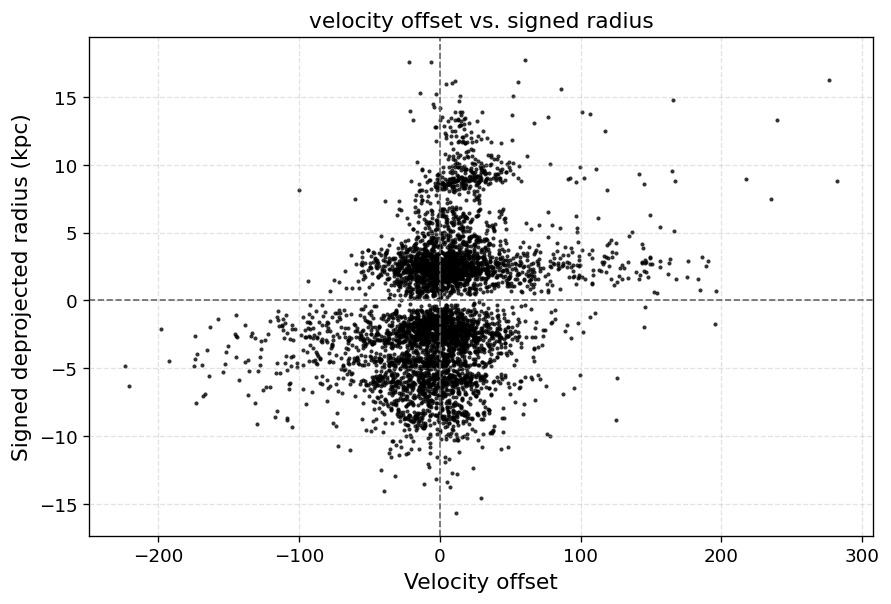

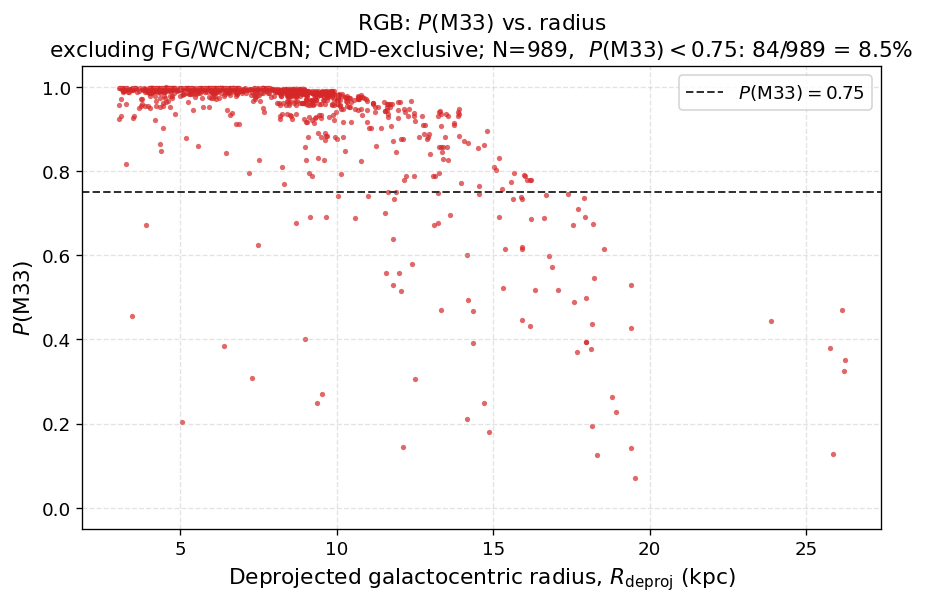

RGB_SEL: N=989, below 0.75 -> 84/989 = 8.5%
Saved pM33_vs_Rdeproj_RGB_SEL.png



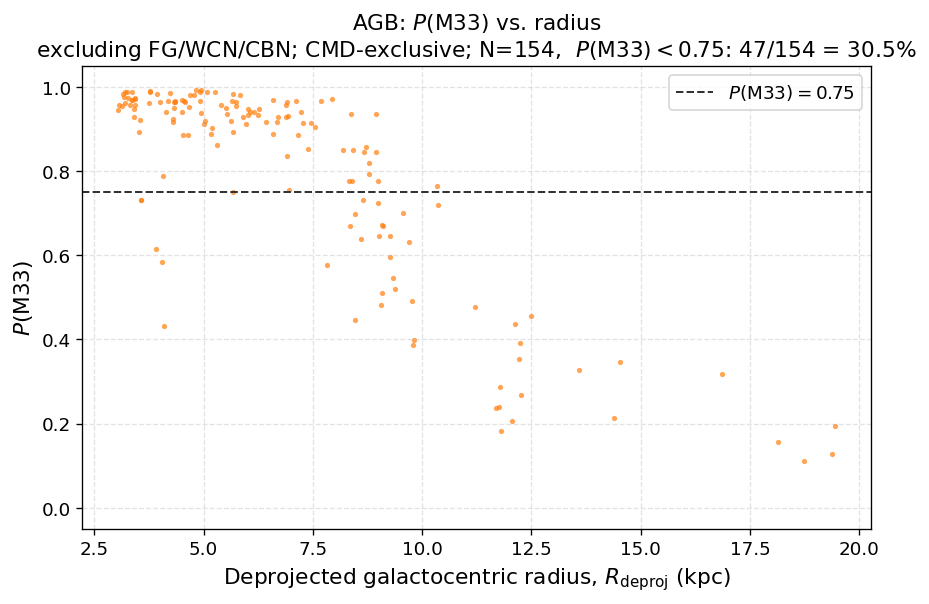

AGB_SEL: N=154, below 0.75 -> 47/154 = 30.5%
Saved pM33_vs_Rdeproj_AGB_SEL.png



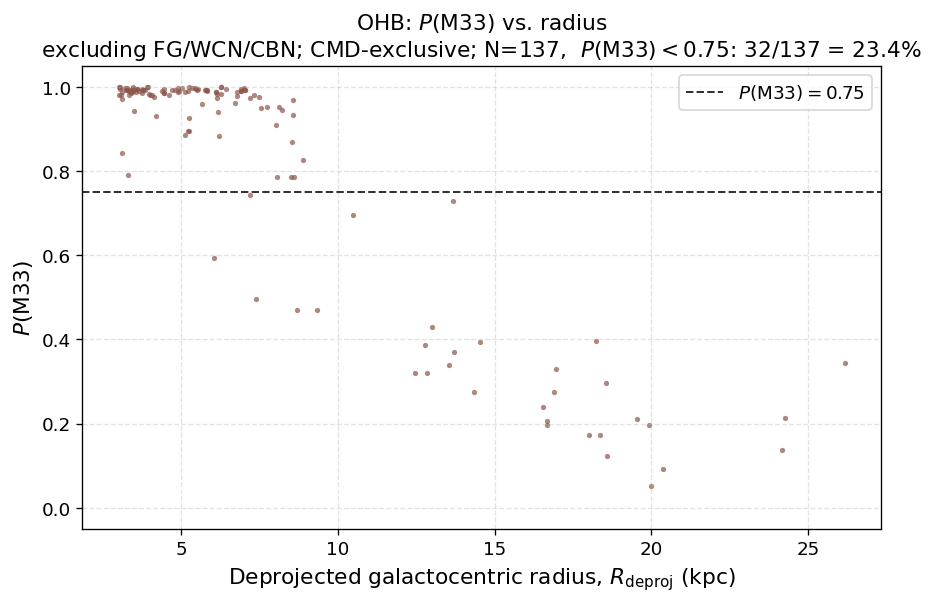

OHB_SEL: N=137, below 0.75 -> 32/137 = 23.4%
Saved pM33_vs_Rdeproj_OHB_SEL.png



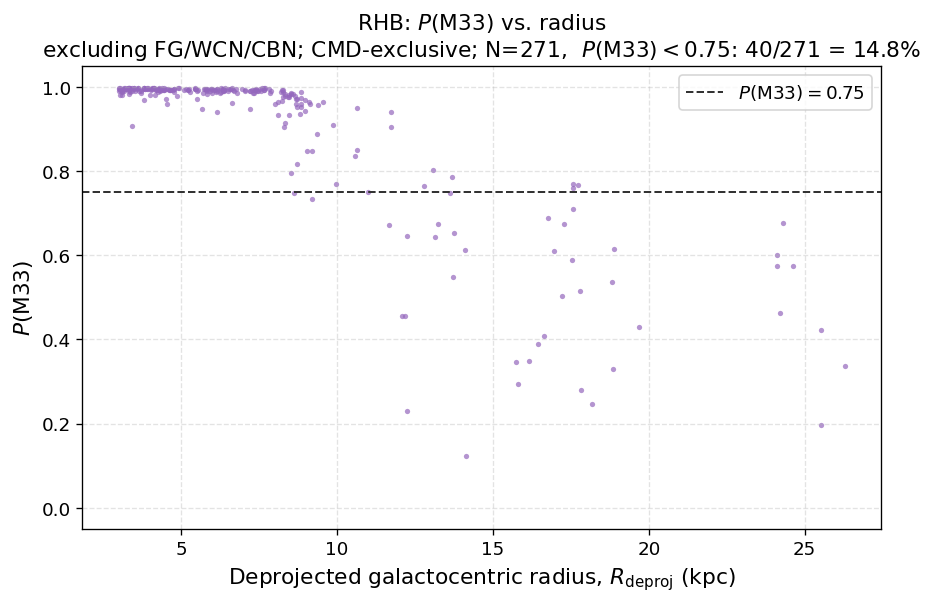

RHB_SEL: N=271, below 0.75 -> 40/271 = 14.8%
Saved pM33_vs_Rdeproj_RHB_SEL.png



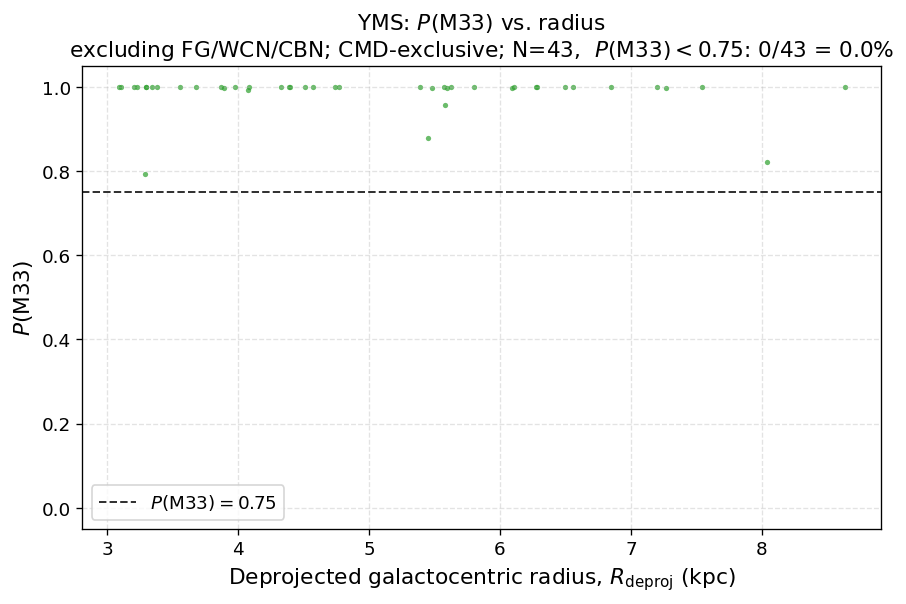

YMS_SEL: N=43, below 0.75 -> 0/43 = 0.0%
Saved pM33_vs_Rdeproj_YMS_SEL.png



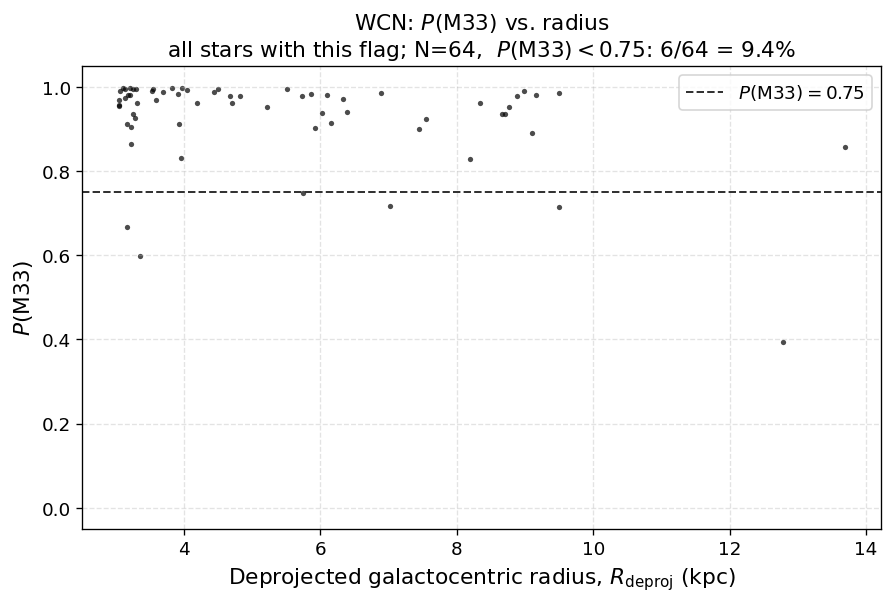

WCN_SEL: N=64, below 0.75 -> 6/64 = 9.4%
Saved pM33_vs_Rdeproj_WCN_SEL.png



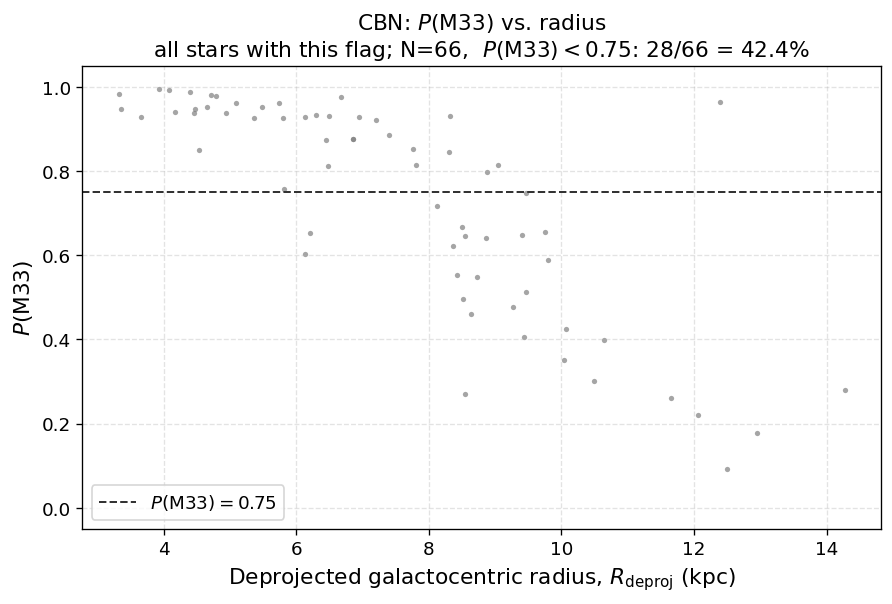

CBN_SEL: N=66, below 0.75 -> 28/66 = 42.4%
Saved pM33_vs_Rdeproj_CBN_SEL.png



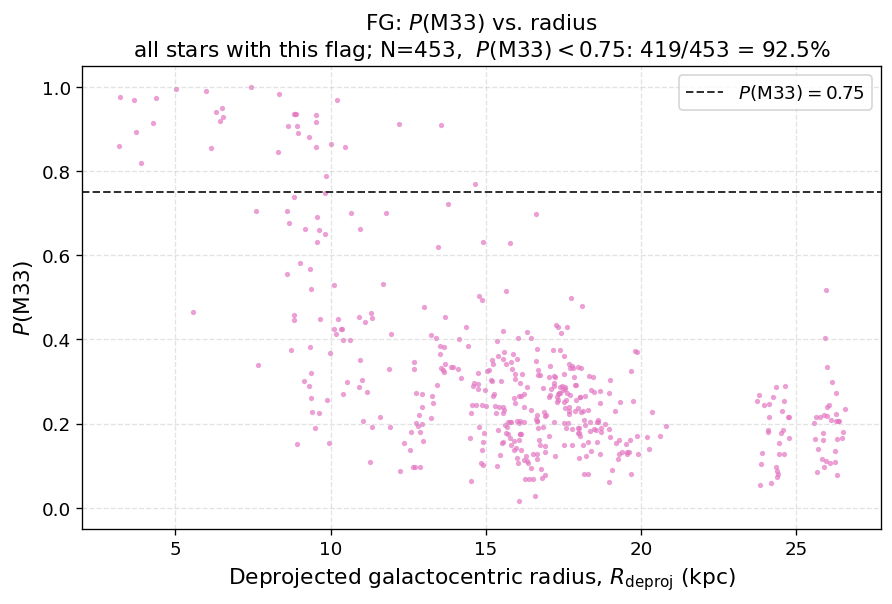

FG_SEL: N=453, below 0.75 -> 419/453 = 92.5%
Saved pM33_vs_Rdeproj_FG_SEL.png



In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ============================================================
# Publication-style plotting defaults
# ============================================================
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
})

# ============================================================
# Helper: compute model LOS velocity and velocity offset
# (expects load_disk_model + compute_model_los_velocity already exist)
# ============================================================
def compute_voffset_summary(df, diskmodel_path="./Kam2017_table4.dat"):
    diskmodel = load_disk_model(diskmodel_path)

    coords = SkyCoord(
        ra=df["RA_DEG"].values * u.deg,
        dec=df["DEC_DEG"].values * u.deg
    )

    model_vlos = compute_model_los_velocity(coords, diskmodel)

    out = df.copy()
    out["model_vlos"] = model_vlos
    out["voffset"] = out["VCORR_STAT"] - out["model_vlos"]
    return out

# ============================================================
# 1) Compute voffset
# ============================================================
new_df = compute_voffset_summary(new_df)

# ============================================================
# 2) Signed deprojected radius using minor-axis coordinate (η)
# ============================================================
center = SkyCoord(ra=23.4621 * u.deg, dec=30.6602 * u.deg)
coords = SkyCoord(
    ra=new_df["RA_DEG"].values * u.deg,
    dec=new_df["DEC_DEG"].values * u.deg
)
offset = coords.transform_to(center.skyoffset_frame())
eta_arcmin = offset.lat.arcminute
new_df["r_deproj_signed"] = new_df["r_deproj_kpc"] * np.sign(eta_arcmin)

# ============================================================
# 3) Core clipping / validity cuts
# ============================================================
clip_min, clip_max = -300, 500
mask_clip = (new_df["voffset"] >= clip_min) & (new_df["voffset"] <= clip_max)
mask_pm33 = new_df["p_m33"].notna()

clipped_df = new_df[mask_clip & mask_pm33].copy()

# ============================================================
# 4) Ensure all *_SEL flags are strict binary integers (NaN->0)
# ============================================================
flag_cols = [c for c in clipped_df.columns if c.endswith("_SEL")]
if flag_cols:
    clipped_df[flag_cols] = clipped_df[flag_cols].fillna(0).astype(int)

# ============================================================
# 5) Define masks for special contamination flags
# ============================================================
is_fg  = (clipped_df.get("FG_SEL", 0) == 1)
is_wcn = (clipped_df.get("WCN_SEL", 0) == 1)
is_cbn = (clipped_df.get("CBN_SEL", 0) == 1)
is_special_contam = is_fg | is_wcn | is_cbn

# ============================================================
# 6) Remove "NONE" from everything:
#    - define "classified" as having ANY *_SEL flag set
# ============================================================
if flag_cols:
    has_any_flag = (clipped_df[flag_cols].sum(axis=1) > 0)
else:
    # If no flags exist, nothing is classified
    has_any_flag = pd.Series(False, index=clipped_df.index)

# Apply global classified-only filter
clipped_df = clipped_df[has_any_flag].copy()

# Recompute masks after filtering
is_fg  = (clipped_df.get("FG_SEL", 0) == 1)
is_wcn = (clipped_df.get("WCN_SEL", 0) == 1)
is_cbn = (clipped_df.get("CBN_SEL", 0) == 1)
is_special_contam = is_fg | is_wcn | is_cbn

# ============================================================
# 7) Membership threshold and CLEAN sample for probability-based analysis
#    (FG/WCN/CBN excluded; NONE already removed)
# ============================================================
thr = 0.75
df_base = clipped_df[~is_special_contam].copy()

# ============================================================
# 8) Clean-sample counts (paper-friendly)
# ============================================================
n_base = len(df_base)
n_members = int((df_base["p_m33"] > thr).sum())
n_reject = n_base - n_members

print("============================================================")
print("Counts used for probability-based analysis")
print("(FG/WCN/CBN excluded; unflagged 'NONE' excluded)")
print(f"Classified, non-FG/WCN/CBN sample:          N = {n_base}")
print(f"High-probability members (P(M33) > {thr:.2f}): N = {n_members}")
print(f"Rejected by probability cut only:           N = {n_reject}")
print("============================================================\n")

# ============================================================
# 9) BadIndex: ONLY df_base stars failing the probability cut
#    (FG/WCN/CBN excluded; NONE excluded)
# ============================================================
bad_mask = (df_base["p_m33"] <= thr)
bad_indices = df_base.loc[bad_mask].index

pd.DataFrame({"BadIndex": bad_indices}).to_csv("BadIndex.csv", index=False)

print("BadIndex (classified, non-FG/WCN/CBN, failing P(M33) cut):")
print(bad_indices.tolist())
print()

# ============================================================
# 10) Probability-based plots (ALL use df_base; NONE excluded)
# ============================================================

# --- Plot 1: Velocity offset vs signed deprojected radius (colored by P(M33)) ---
fig, ax = plt.subplots(figsize=(7.6, 5.2))
sc = ax.scatter(
    df_base["voffset"],
    df_base["r_deproj_signed"],
    c=df_base["p_m33"],
    cmap="viridis_r",
    s=10,
    linewidths=0,
    vmin=0,
    vmax=1
)
ax.axvline(0, color="0.4", linestyle="--", linewidth=1.0)
ax.axhline(0, color="0.4", linestyle="--", linewidth=1.0)

ax.set_xlabel(r"Velocity offset, $v_{\rm los}-v_{\rm model}$ (km s$^{-1}$)")
ax.set_ylabel(r"Signed deprojected radius, $R_{\rm deproj}\,\mathrm{sgn}(\eta)$ (kpc)")
ax.set_title("Classified, non-FG/WCN/CBN sample: velocity offset vs. signed radius")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$P({\rm M33})$")

fig.tight_layout()
fig.savefig("voffset_vs_rsigned_clean.png", bbox_inches="tight")
plt.show()

# --- Plot 2: Member-only view (P(M33) > thr) ---
df_base_members = df_base[df_base["p_m33"] > thr].copy()

fig, ax = plt.subplots(figsize=(7.6, 5.2))
sc = ax.scatter(
    df_base_members["voffset"],
    df_base_members["r_deproj_signed"],
    c=df_base_members["p_m33"],
    cmap="viridis_r",
    s=10,
    linewidths=0,
    vmin=0,
    vmax=1
)
ax.axvline(0, color="0.4", linestyle="--", linewidth=1.0)
ax.axhline(0, color="0.4", linestyle="--", linewidth=1.0)

ax.set_xlabel(r"Velocity offset, $v_{\rm los}-v_{\rm model}$ (km s$^{-1}$)")
ax.set_ylabel(r"Signed deprojected radius, $R_{\rm deproj}\,\mathrm{sgn}(\eta)$ (kpc)")
ax.set_title(rf"High-probability members: $P({{\rm M33}}) > {thr:.2f}$")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$P({\rm M33})$")

fig.tight_layout()
fig.savefig(f"voffset_vs_rsigned_members_Pgt{thr:.2f}.png", bbox_inches="tight")
plt.show()


# Plot 3 (FIXED): No P(M33) requirement.
# Include stars that:
#   - pass voffset clip
#   - are classified (not NONE)
#   - are NOT FG
#   - are NOT in BadIndex
# and show signed deproj radius vs velocity offset.
# ============================================================

# Start from new_df (so we do NOT inherit the p_m33-notna cut baked into clipped_df)
df_plot3 = new_df[mask_clip].copy()

# Ensure *_SEL flags are strict binary integers (NaN->0), matching your main pipeline
flag_cols_plot3 = [c for c in df_plot3.columns if c.endswith("_SEL")]
if flag_cols_plot3:
    df_plot3[flag_cols_plot3] = df_plot3[flag_cols_plot3].fillna(0).astype(int)

    # Remove "NONE" (unflagged) from Plot 3 as well (consistent with your global rule)
    df_plot3 = df_plot3[df_plot3[flag_cols_plot3].sum(axis=1) > 0].copy()
else:
    # If no flags exist, Plot 3 has nothing to show under your "no NONE" rule
    df_plot3 = df_plot3.iloc[0:0].copy()

# Remove FG
if "FG_SEL" in df_plot3.columns:
    df_plot3 = df_plot3[df_plot3["FG_SEL"] != 1].copy()

# Remove BadIndex (these are indices from df_base; drop is safe with errors='ignore')
df_plot3 = df_plot3.drop(index=bad_indices, errors="ignore")

# OPTIONAL: if you intended to include *all* radii including 0, do nothing.
# If you intended to exclude exactly 0 kpc, uncomment:
# df_plot3 = df_plot3[df_plot3["r_deproj_kpc"] != 0].copy()

fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.scatter(
    df_plot3["voffset"],
    df_plot3["r_deproj_signed"],
    s=6,                 # smaller points
    color="black",       # solid black dots
    alpha=0.8,           # slightly transparent to reduce overplotting
    linewidths=0
)

ax.axvline(0, color="0.4", linestyle="--", linewidth=1.0)
ax.axhline(0, color="0.4", linestyle="--", linewidth=1.0)

ax.set_xlabel(r"Velocity offset")
ax.set_ylabel(r"Signed deprojected radius (kpc)")
ax.set_title(r"Velocity offset vs. Signed radius")

fig.tight_layout()
fig.savefig("voffset_vs_rsigned_noPm33_nonFG_noBadIndex.png", bbox_inches="tight")
plt.show()


# ============================================================
# 11) By-flag plots
#
# Rules:
# - Special flags (WCN/CBN/FG): plot all stars with that flag (NONE excluded already)
# - CMD flags (RGB/AGB/OHB/RHB/YMS): exclude FG/WCN/CBN and enforce CMD-exclusivity
# ============================================================
cmd_flags = ["RGB_SEL", "AGB_SEL", "OHB_SEL", "RHB_SEL", "YMS_SEL"]
special_flags = ["WCN_SEL", "CBN_SEL", "FG_SEL"]

cmd_flags = [c for c in cmd_flags if c in clipped_df.columns]
special_flags = [c for c in special_flags if c in clipped_df.columns]

# CMD exclusivity: exactly one CMD flag among cmd_flags
if cmd_flags:
    cmd_sum = clipped_df[cmd_flags].sum(axis=1)
else:
    cmd_sum = pd.Series(0, index=clipped_df.index)

sel_colors = {
    "RGB_SEL": "tab:red",
    "AGB_SEL": "tab:orange",
    "OHB_SEL": "tab:brown",
    "RHB_SEL": "tab:purple",
    "YMS_SEL": "tab:green",
    "WCN_SEL": "black",
    "CBN_SEL": "tab:gray",
    "FG_SEL": "tab:pink",
}

def short_label(flag):
    # Keep OHB/RHB/AGB as-is, per your instruction.
    mapping = {
        "RGB_SEL": "RGB",
        "AGB_SEL": "AGB",
        "OHB_SEL": "OHB",
        "RHB_SEL": "RHB",
        "YMS_SEL": "YMS",
        "WCN_SEL": "WCN",
        "CBN_SEL": "CBN",
        "FG_SEL": "FG",
    }
    return mapping.get(flag, flag.replace("_SEL", ""))

for flag in (cmd_flags + special_flags):

    if flag in special_flags:
        # Plot all stars with that special flag
        sub = clipped_df[clipped_df[flag] == 1].copy()
        subtitle = "all stars with this flag"
    else:
        # CMD-class plot:
        # - must be in the class
        # - must be CMD-exclusive
        # - must NOT be FG/WCN/CBN
        sub_mask = (
            (clipped_df[flag] == 1) &
            (cmd_sum == 1) &
            (~is_special_contam)
        )
        sub = clipped_df[sub_mask].copy()
        subtitle = "excluding FG/WCN/CBN; CMD-exclusive"

    if sub.empty:
        print(f"[WARN] {flag}: no stars found under current rules; skipping.")
        continue

    n_tot = len(sub)
    n_below = int((sub["p_m33"] < thr).sum())
    frac_below = (n_below / n_tot) if n_tot > 0 else np.nan

    fig, ax = plt.subplots(figsize=(7.6, 5.2))
    ax.scatter(
        sub["r_deproj_kpc"],
        sub["p_m33"],
        s=10,
        alpha=0.70,
        color=sel_colors.get(flag, "0.35"),
        linewidths=0
    )
    ax.axhline(thr, color="0.2", linestyle="--", linewidth=1.2,
               label=rf"$P({{\rm M33}})={thr:.2f}$")

    ax.set_xlabel(r"Deprojected galactocentric radius, $R_{\rm deproj}$ (kpc)")
    ax.set_ylabel(r"$P({\rm M33})$")
    ax.set_ylim(-0.05, 1.05)

    ax.set_title(
        rf"{short_label(flag)}: $P({{\rm M33}})$ vs. radius"
        "\n"
        rf"{subtitle}; N={n_tot},  $P({{\rm M33}})<{thr:.2f}$: {n_below}/{n_tot} = {100*frac_below:.1f}%"
    )
    ax.legend(frameon=True)

    fig.tight_layout()
    outname = f"pM33_vs_Rdeproj_{flag}.png"
    fig.savefig(outname, bbox_inches="tight")
    plt.show()

    print(f"{flag}: N={n_tot}, below {thr:.2f} -> {n_below}/{n_tot} = {100*frac_below:.1f}%")
    print(f"Saved {outname}\n")